Notebook de Modélisation - Scoring Crédit "Prêt à dépenser"

###### Contexte et Objectifs du Projet
"Prêt à dépenser" est une société financière spécialisée dans les crédits à la consommation pour des personnes ayant peu ou pas d'historique de prêt. Dans un contexte où l'inclusion financière est cruciale, l'entreprise souhaite développer un outil de scoring crédit automatisé permettant de :

- Calculer la probabilité qu'un client rembourse son crédit
- Classifier automatiquement les demandes : crédit accordé ou refusé
- Garantir la transparence des décisions grâce à l'explicabilité du modèle

##### Mission et Défis Techniques
- Objectifs Principaux
- Construire un modèle de scoring robuste avec prédiction automatique de la probabilité de défaut
- Analyser l'importance des features (globale et locale) pour assurer la transparence
- Déployer le modèle en production via une API avec interface de test
- Implémenter une approche MLOps complète du tracking à la surveillance du data drift

In [1]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [2]:
# Importation des bibliothèques nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import gc
import time
from contextlib import contextmanager
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# Fonction utilitaire pour mesurer le temps d'exécution
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print(f"{title} - réalisé en {time.time() - t0:.0f}s")

In [3]:
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri('http://127.0.0.1:5000/')

# Définir un nom d'expérience 
experiment_name = "Credit Scoring Experiment"
mlflow.set_experiment(experiment_name)

2025/09/28 11:16:09 INFO mlflow.tracking.fluent: Experiment with name 'Credit Scoring Experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/546551843044102009', creation_time=1759050969065, experiment_id='546551843044102009', last_update_time=1759050969065, lifecycle_stage='active', name='Credit Scoring Experiment', tags={}>

In [4]:
def log_mlflow_metrics(model, X_train, y_train, X_test, y_test, run_name):
    """Log additional metrics and artifacts to MLFlow."""
    with mlflow.start_run(run_name=run_name):
        # Prédictions
        y_train_pred = model.predict_proba(X_train)[:, 1]
        y_test_pred = model.predict_proba(X_test)[:, 1]

        # Calcul des métriques
        train_auc = roc_auc_score(y_train, y_train_pred)
        test_auc = roc_auc_score(y_test, y_test_pred)
        y_test_pred_class = (y_test_pred > 0.5).astype(int)
        cm = confusion_matrix(y_test, y_test_pred_class)

        # Log des métriques
        mlflow.log_metric("train_auc", train_auc)
        mlflow.log_metric("test_auc", test_auc)
        mlflow.log_metric("accuracy", (cm[0, 0] + cm[1, 1]) / cm.sum())
        mlflow.log_metric("precision", cm[1, 1] / (cm[1, 1] + cm[0, 1]))
        mlflow.log_metric("recall", cm[1, 1] / (cm[1, 1] + cm[1, 0]))

        # Log des hyperparamètres
        if hasattr(model, "get_params"):
            mlflow.log_params(model.get_params())

        # Courbe ROC
        fpr, tpr, _ = roc_curve(y_test, y_test_pred)
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend(loc="lower right")
        plt.savefig("roc_curve.png")
        mlflow.log_artifact("roc_curve.png")

        # Matrice de confusion
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Default", "Default"], yticklabels=["No Default", "Default"])
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig("confusion_matrix.png")
        mlflow.log_artifact("confusion_matrix.png")

# Table of Contents 

1. [Description des dataset](#1)
2. [Préparation des données et feature engineering](#2)

# 1. Description des dataset

##### `application_{train|test}.csv`
- Table principale du projet.
- `application_train.csv` contient la variable cible `TARGET`.
- `application_test.csv` ne contient pas `TARGET`.
- Chaque ligne représente une demande de prêt.
- Ce sont des données statiques sur les clients.

---

##### `bureau.csv`
- Informations sur les **crédits précédents** des clients, accordés par d'autres institutions financières.
- Ces crédits sont signalés au **Credit Bureau**.
- Plusieurs lignes par client : une par crédit antérieur.

---

##### `bureau_balance.csv`
- Historique **mensuel** des soldes pour les crédits référencés dans `bureau.csv`.
- Une ligne par mois et par crédit antérieur signalé.
- Très grande table.

---

##### `POS_CASH_balance.csv`
- Historique mensuel des anciens **crédits à la consommation** ou **crédits POS** contractés par le client chez Home Credit.
- Une ligne = un mois d’historique pour un crédit précédent.

---

##### `credit_card_balance.csv`
- Historique mensuel des soldes des **cartes de crédit** détenues par le client chez Home Credit.
- Structure équivalente à `POS_CASH_balance.csv`.

---

##### `previous_application.csv`
- Contient toutes les **anciennes demandes de prêt** réalisées par les clients auprès de Home Credit.
- Une ligne = une demande passée.

---

##### `installments_payments.csv`
- Historique des **remboursements** pour les crédits antérieurs.
- Une ligne par mensualité : payée ou non payée.

---

##### `HomeCredit_columns_description.csv`
- Dictionnaire de données : descriptions des colonnes de tous les fichiers.


![Architecture des tables](tables_archi.png)

# 2. Analyse exploratoire

Afin de faciliter l’analyse exploratoire, la préparation des données et le feature engineering nécessaires à l’élaboration du modèle de scoring, nous nous basons sur un kernel Kaggle : https://www.kaggle.com/code/jsaguiar/lightgbm-with-simple-features/script

In [8]:
# Chargement des données principales
application_train = pd.read_csv('application_train.csv')
application_test = pd.read_csv('application_test.csv')

# Affichage des dimensions des datasets
print(f"Taille du dataset d'entraînement : {application_train.shape}")
print(f"Taille du dataset de test : {application_test.shape}")

# Aperçu des données
application_train.head()

Taille du dataset d'entraînement : (307511, 122)
Taille du dataset de test : (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
application_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

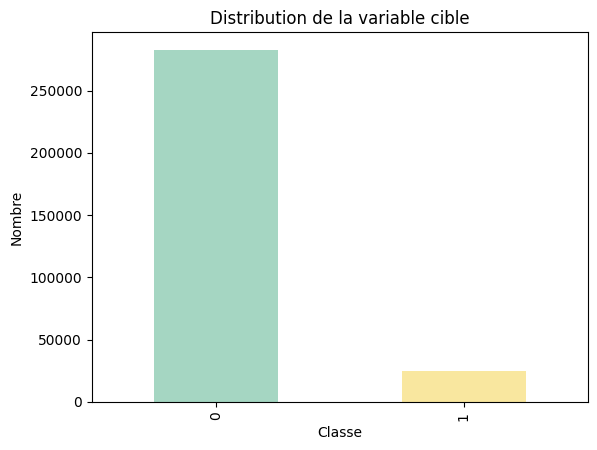

In [10]:
# Distribution de la variable cible
application_train['TARGET'].value_counts().plot(kind='bar', color=['#A5D6C2', '#F9E79F'])
plt.title('Distribution de la variable cible')
plt.xlabel('Classe')
plt.ylabel('Nombre')
plt.show()

Le dataset train :
Nombre total de cellules manquantes : 9152465
Nombre de cellules manquantes en % : 24.40%

Le dataset test :
Nombre total de cellules manquantes : 1404419
Nombre de cellules manquantes en % : 23.81%



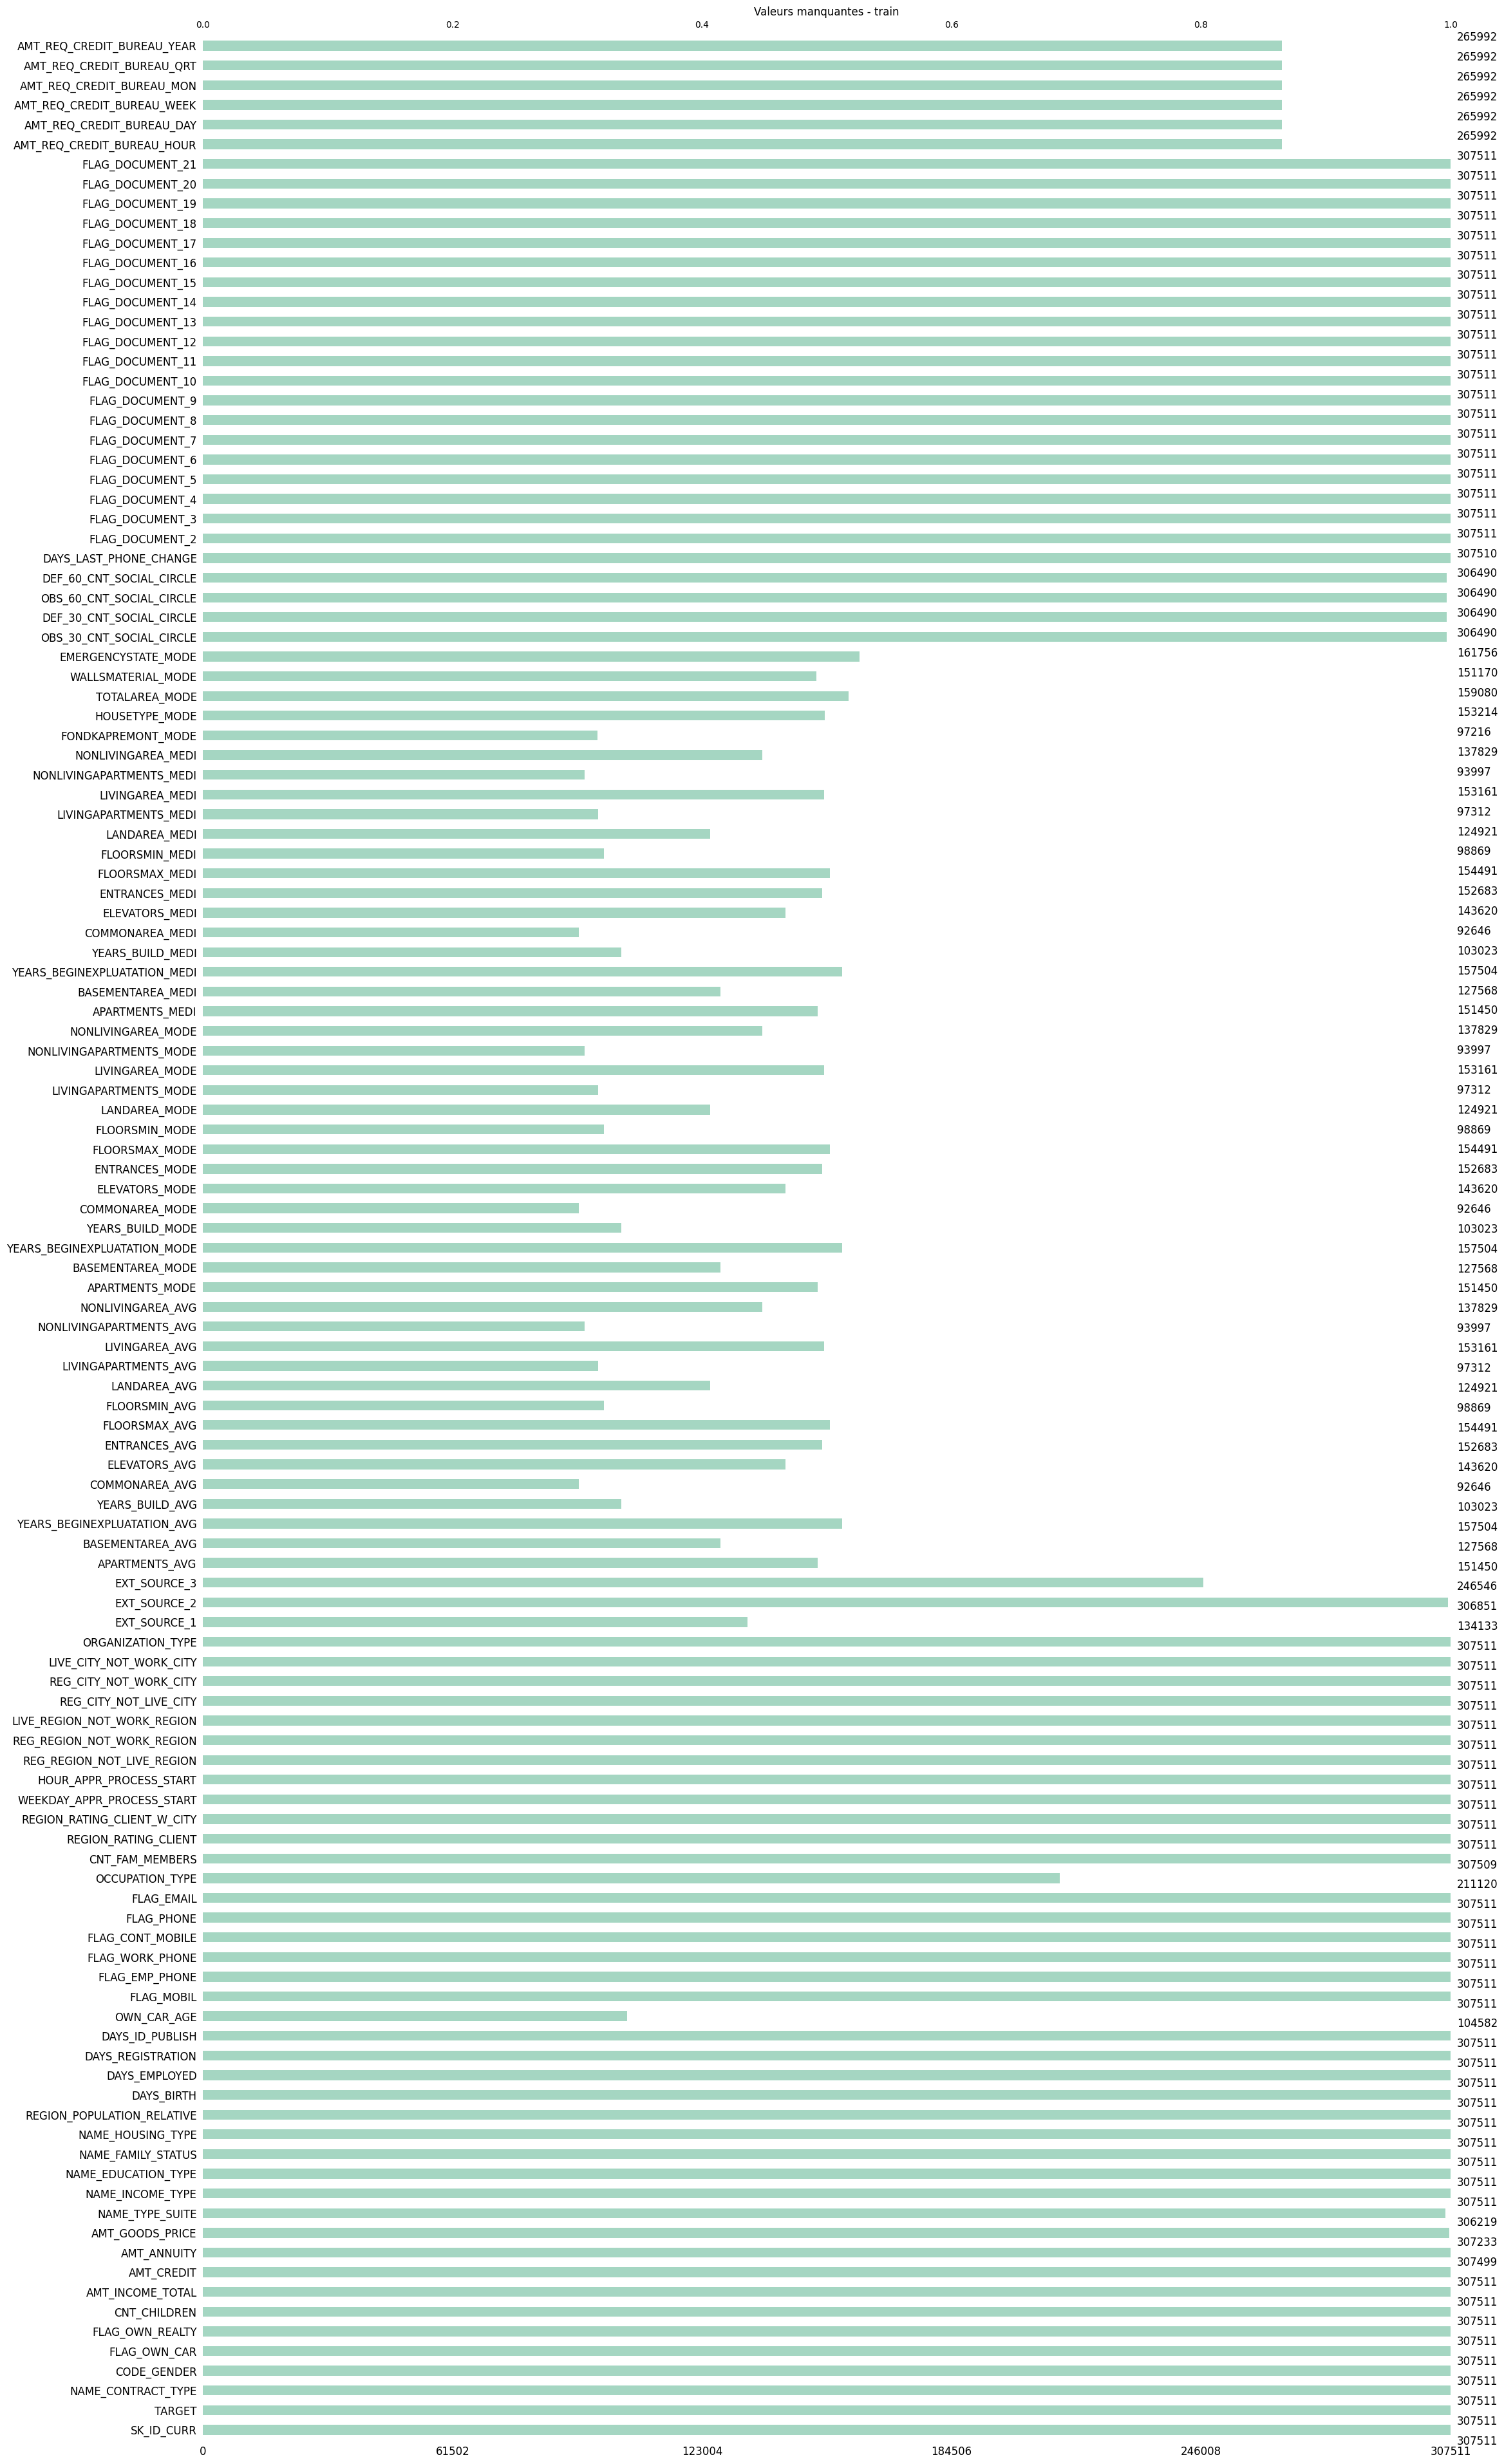

In [11]:
# Fonction pour afficher les valeurs manquantes
def afficher_missing(df, nom_df):
    total_cells = df.size
    total_missing = df.isnull().sum().sum()
    pct_missing = (total_missing / total_cells) * 100
    print(f"Le dataset {nom_df} :")
    print(f"Nombre total de cellules manquantes : {total_missing}")
    print(f"Nombre de cellules manquantes en % : {pct_missing:.2f}%\n")

afficher_missing(application_train, "train")
afficher_missing(application_test, "test")

# Visualisation des valeurs manquantes
msno.bar(application_train, color=['#A5D6C2'], fontsize=12)
plt.title("Valeurs manquantes - train")
plt.show()

In [12]:
application_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [13]:
application_train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

# 3. Préparation des données

## 3.1 Encodage des variables catégorielles

In [14]:
# Créer un objet de type LabelEncoder
le = LabelEncoder()
le_count = 0

# Parcourir les colonnes
for col in application_train:
    if application_train[col].dtype == 'object':
        # Si la colonne contient 2 catégories uniques ou moins
        if len(list(application_train[col].unique())) <= 2:
            # Entraîner le LabelEncoder sur les données d'entraînement
            le.fit(application_train[col])
            # Transformer les données d'entraînement et de test
            application_train[col] = le.transform(application_train[col])
            application_test[col] = le.transform(application_test[col])
            
            # Compter le nombre de colonnes encodées
            le_count += 1
            
print('%d colonnes ont été encodées avec LabelEncoder.' % le_count)

3 colonnes ont été encodées avec LabelEncoder.


In [15]:
# Encodage one-hot des variables catégorielles
application_train = pd.get_dummies(application_train)
application_test = pd.get_dummies(application_test)

# Affichage des dimensions des datasets après encodage
print('Dimensions des features du dataset d\'entraînement : ', application_train.shape)
print('Dimensions des features du dataset de test : ', application_test.shape)

Dimensions des features du dataset d'entraînement :  (307511, 243)
Dimensions des features du dataset de test :  (48744, 239)


In [16]:
# Extraction de la variable cible
train_labels = application_train['TARGET']

# Alignement des données d'entraînement et de test, en conservant uniquement les colonnes communes
application_train, application_test = application_train.align(application_test, join='inner', axis=1)

# Réintégration de la variable cible dans le dataset d'entraînement
application_train['TARGET'] = train_labels

# Affichage des dimensions des datasets après alignement
print('Dimensions des features du dataset d\'entraînement : ', application_train.shape)
print('Dimensions des features du dataset de test : ', application_test.shape)

Dimensions des features du dataset d'entraînement :  (307511, 240)
Dimensions des features du dataset de test :  (48744, 239)


## 3.2 Traitement des anomalies

In [17]:
(application_train['DAYS_BIRTH'] / -365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

In [18]:
application_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

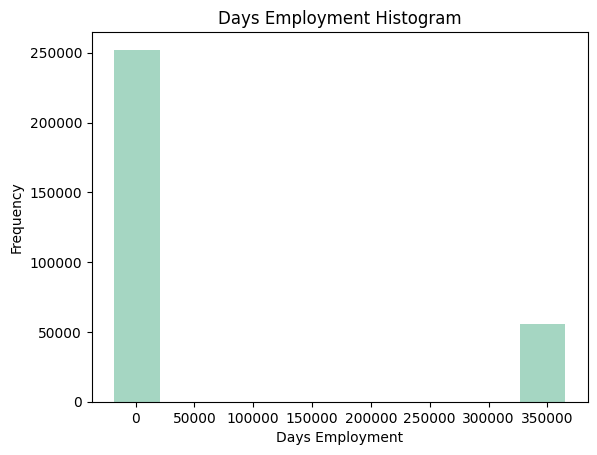

In [19]:
application_train['DAYS_EMPLOYED'].plot.hist(title='Days Employment Histogram', color='#A5D6C2')
plt.xlabel('Days Employment')
plt.show()

In [20]:
anom = application_train[application_train['DAYS_EMPLOYED'] == 365243]
non_anom = application_train[application_train['DAYS_EMPLOYED'] != 365243]
print('The non-anomalies default on %0.2f%% of loans' % (100 * non_anom['TARGET'].mean()))
print('The anomalies default on %0.2f%% of loans' % (100 * anom['TARGET'].mean()))
print('There are %d anomalous days of employment' % len(anom))

The non-anomalies default on 8.66% of loans
The anomalies default on 5.40% of loans
There are 55374 anomalous days of employment


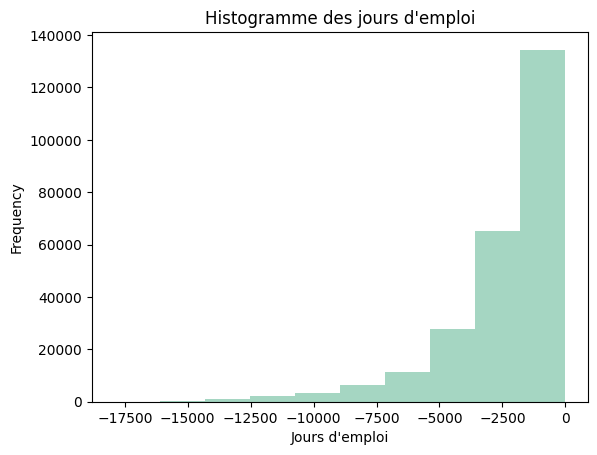

In [21]:
# Création d'une colonne pour indiquer les valeurs anormales
application_train['DAYS_EMPLOYED_ANOM'] = application_train["DAYS_EMPLOYED"] == 365243

# Remplacement des valeurs anormales par NaN
application_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)

# Visualisation de l'histogramme des jours d'emploi
application_train['DAYS_EMPLOYED'].plot.hist(title='Histogramme des jours d\'emploi', color='#A5D6C2')
plt.xlabel('Jours d\'emploi')
plt.show()

In [22]:
# Création d'une colonne pour indiquer les valeurs anormales dans le dataset de test
application_test['DAYS_EMPLOYED_ANOM'] = application_test["DAYS_EMPLOYED"] == 365243

# Remplacement des valeurs anormales par NaN dans le dataset de test
application_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace=True)

# Affichage du nombre d'anomalies dans les données de test
print('Il y a %d anomalies dans les données de test sur un total de %d entrées.' % (application_test["DAYS_EMPLOYED_ANOM"].sum(), len(application_test)))

Il y a 9274 anomalies dans les données de test sur un total de 48744 entrées.


## 3.3 Corrélations

##### Analyse exploratoire des données (EDA)

Maintenant que nous avons traité les variables catégorielles ainsi que les valeurs aberrantes, poursuivons notre exploration des données.

Une méthode pour mieux comprendre notre jeu de données consiste à rechercher des corrélations entre les variables explicatives et la variable cible. Pour cela, nous pouvons calculer le coefficient de corrélation de Pearson entre chaque variable et la cible, en utilisant la méthode `.corr` de notre dataframe.

> **Remarque :** Le coefficient de corrélation n’est pas la meilleure métrique pour mesurer la « pertinence » d’une variable, mais il nous donne une première idée des relations potentielles entre les variables.

Voici une interprétation générale de la valeur absolue du coefficient de corrélation :

| Valeur absolue | Interprétation      |
|----------------|--------------------|
| 0,00 – 0,19    | Très faible        |
| 0,20 – 0,39    | Faible             |
| 0,40 – 0,59    | Modérée            |
| 0,60 – 0,79    | Forte              |
| 0,80 – 1,00    | Très forte         |


In [23]:
# Calculer les corrélations avec la variable cible et trier les résultats
correlations = application_train.corr()['TARGET'].sort_values()

# Afficher les corrélations les plus positives
print('Corrélations les plus positives :\n', correlations.tail(15))

# Afficher les corrélations les plus négatives
print('\nCorrélations les plus négatives :\n', correlations.head(15))

Corrélations les plus positives :
 OCCUPATION_TYPE_Laborers                             0.043019
FLAG_DOCUMENT_3                                      0.044346
REG_CITY_NOT_LIVE_CITY                               0.044395
FLAG_EMP_PHONE                                       0.045982
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER_M                                        0.054713
DAYS_LAST_PHONE_CHANGE                               0.055218
NAME_INCOME_TYPE_Working                             0.057481
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
DAYS_EMPLOYED                                        0.074958
DAYS_BIRTH                                           0.078239
TARGET                                               1.000000
Name: TARGET, dtype: float64

Corré

##### Analyse des corrélations les plus significatives

Examinons maintenant certaines des corrélations les plus importantes : **DAYS_BIRTH** présente la corrélation positive la plus forte (à l’exception de la variable **TARGET**, car la corrélation d’une variable avec elle-même est toujours égale à 1).

D’après la documentation, **DAYS_BIRTH** correspond à l’âge du client en jours au moment du prêt, exprimé en jours négatifs (pour une raison inconnue !). La corrélation est positive, mais comme la valeur de cette variable est négative, cela signifie qu’à mesure que le client vieillit, il est moins susceptible de faire défaut sur son prêt (c’est-à-dire que la cible vaut 0).

Cette situation peut prêter à confusion. Pour simplifier l’interprétation, nous prendrons la valeur absolue de cette variable, ce qui inversera la corrélation et la rendra négative.

### 3.3.1 Effet de l'âge sur le remboursement

In [24]:
# Calculer la corrélation entre l'âge (en jours positifs depuis la naissance) et la variable cible
application_train['DAYS_BIRTH'] = abs(application_train['DAYS_BIRTH'])
correlation_age_target = application_train['DAYS_BIRTH'].corr(application_train['TARGET'])

print('Corrélation entre l\'âge et la probabilité de défaut :', correlation_age_target)

Corrélation entre l'âge et la probabilité de défaut : -0.07823930830982709


##### Relation entre l’âge du client et la variable cible

À mesure que le client vieillit, il existe une relation linéaire négative avec la variable cible, ce qui signifie que les clients plus âgés ont tendance à rembourser leurs prêts à temps plus fréquemment.

Commençons par étudier cette variable. Premièrement, nous pouvons tracer un histogramme de l’âge. Pour rendre le graphique plus compréhensible, nous afficherons l’axe des abscisses en années.

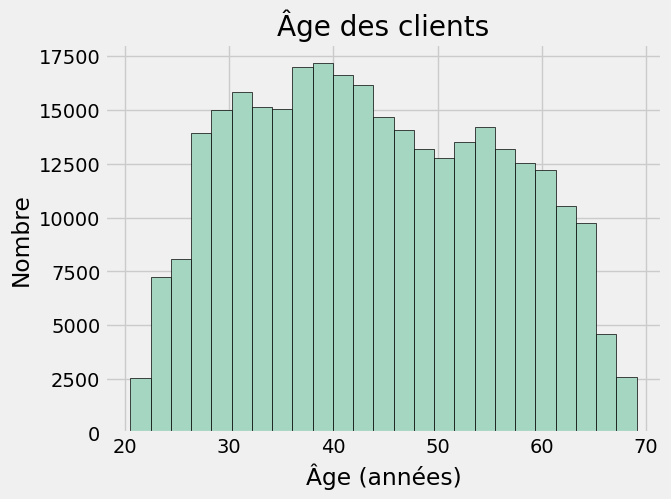

In [25]:
# Définir le style des graphiques
plt.style.use('fivethirtyeight')

# Tracer la distribution des âges en années
plt.hist(application_train['DAYS_BIRTH'] / 365, edgecolor='k', bins=25, color='#A5D6C2')
plt.title('Âge des clients')
plt.xlabel('Âge (années)')
plt.ylabel('Nombre')
plt.show()

##### Analyse de la distribution de l’âge et son impact sur la cible

La simple distribution de l’âge ne nous apprend pas grand-chose, si ce n’est qu’il n’y a pas de valeurs aberrantes, toutes les âges étant raisonnables. 

Pour mieux visualiser l’effet de l’âge sur la variable cible, nous allons réaliser un graphique d’estimation de densité par noyau (KDE), coloré en fonction de la valeur de la cible. 

Un graphique KDE montre la distribution d’une variable unique et peut être considéré comme un histogramme lissé. Il est construit en calculant un noyau, généralement gaussien, pour chaque point de données, puis en moyennant ces noyaux pour obtenir une courbe lisse.

Nous utiliserons la fonction `kdeplot` de la bibliothèque Seaborn pour réaliser ce graphique.

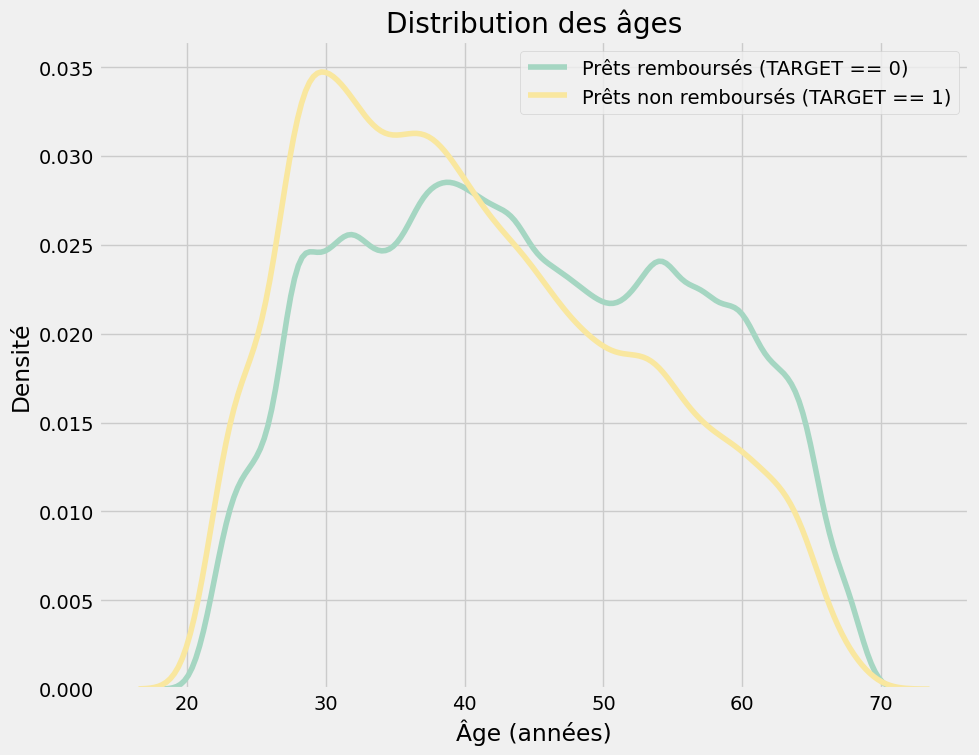

In [26]:
plt.figure(figsize=(10, 8))

# Tracé KDE des prêts remboursés à temps
sns.kdeplot(application_train.loc[application_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label='Prêts remboursés (TARGET == 0)', color='#A5D6C2')

# Tracé KDE des prêts non remboursés à temps
sns.kdeplot(application_train.loc[application_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label='Prêts non remboursés (TARGET == 1)', color='#F9E79F')

# Étiquetage du graphique
plt.xlabel('Âge (années)')
plt.ylabel('Densité')
plt.title('Distribution des âges')
plt.legend()
plt.show()

##### Analyse de la relation entre l’âge et le défaut de paiement

La courbe correspondant à **target == 1** est davantage concentrée vers les plus jeunes. Bien que la corrélation soit faible (-0,07), cette variable sera probablement utile dans un modèle de machine learning, car elle influence la cible.

Examinons cette relation autrement : en calculant le taux moyen de défaut de remboursement selon des tranches d’âge.

Pour réaliser ce graphique, nous découpons d’abord la variable âge en intervalles de 5 ans. Puis, pour chaque tranche, nous calculons la moyenne de la variable cible, ce qui nous donne le taux de prêts non remboursés dans chaque catégorie d’âge.

In [27]:
# Création d'un dataframe séparé pour les informations sur l'âge
age_data = application_train[['TARGET', 'DAYS_BIRTH']]
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

# Regrouper les données d'âge en intervalles
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins=np.linspace(20, 70, num=11))

# Afficher les 10 premières lignes du dataframe
age_data.head(10)

,TARGET,DAYS_BIRTH,YEARS_BIRTH,YEARS_BINNED
0,1,9461,25.920548,"(25.0, 30.0]"
1,0,16765,45.931507,"(45.0, 50.0]"
2,0,19046,52.180822,"(50.0, 55.0]"
3,0,19005,52.068493,"(50.0, 55.0]"
4,0,19932,54.608219,"(50.0, 55.0]"
5,0,16941,46.413699,"(45.0, 50.0]"
6,0,13778,37.747945,"(35.0, 40.0]"
7,0,18850,51.643836,"(50.0, 55.0]"
8,0,20099,55.065753,"(55.0, 60.0]"
9,0,14469,39.641096,"(35.0, 40.0]"


In [28]:
# Regrouper par intervalle d'âge et calculer les moyennes
age_groups = age_data.groupby('YEARS_BINNED').mean()

# Afficher les moyennes par groupe d'âge
age_groups

,TARGET,DAYS_BIRTH,YEARS_BIRTH
YEARS_BINNED,,,
"(20.0, 25.0]",0.123036,8532.795625,23.377522
"(25.0, 30.0]",0.111436,10155.219250,27.822518
"(30.0, 35.0]",0.102814,11854.848377,32.479037
"(35.0, 40.0]",0.089414,13707.908253,37.555913
"(40.0, 45.0]",0.078491,15497.661233,42.459346
"(45.0, 50.0]",0.074171,17323.900441,47.462741
"(50.0, 55.0]",0.066968,19196.494791,52.593136
"(55.0, 60.0]",0.055314,20984.262742,57.491131
"(60.0, 65.0]",0.052737,22780.547460,62.412459


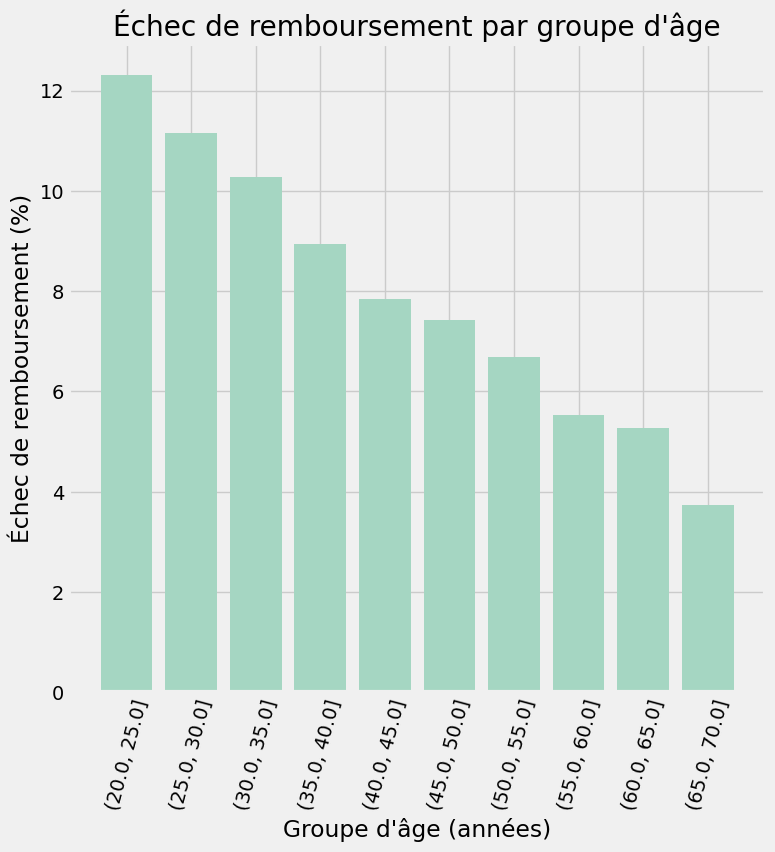

In [29]:
plt.figure(figsize=(8, 8))

# Tracer les intervalles d'âge et la moyenne de la variable cible sous forme de diagramme en barres
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'], color='#A5D6C2')

# Étiquetage du graphique
plt.xticks(rotation=75)
plt.xlabel('Groupe d\'âge (années)')
plt.ylabel('Échec de remboursement (%)')
plt.title('Échec de remboursement par groupe d\'âge')
plt.show()

##### Tendances observées selon les tranches d’âge

Une tendance claire se dégage : les demandeurs les plus jeunes ont plus de risques de ne pas rembourser leur prêt ! Le taux de défaut dépasse 10 % pour les trois premières tranches d’âge les plus jeunes, tandis qu’il est inférieur à 5 % pour la tranche d’âge la plus âgée.

Cette information peut être directement exploitée par la banque : étant donné que les clients plus jeunes ont moins de chances de rembourser leur prêt, il pourrait être judicieux de leur offrir davantage d’accompagnement ou de conseils en gestion financière. 

Cela ne signifie pas que la banque doive discriminer ces clients, mais il serait intelligent de mettre en place des mesures préventives pour les aider à honorer leurs paiements à temps.

### 3.3.2 Sources externes

Les trois variables présentant les corrélations négatives les plus fortes avec la cible sont **EXT_SOURCE_1**, **EXT_SOURCE_2** et **EXT_SOURCE_3**. D’après la documentation, ces variables représentent un « score normalisé provenant de sources de données externes ». 

Je ne suis pas certain de la nature exacte de ces scores, mais il s’agit probablement d’une sorte d’évaluation de crédit cumulative, basée sur plusieurs sources de données.

Intéressons-nous maintenant à ces variables.

Pour commencer, nous pouvons afficher les corrélations entre les variables **EXT_SOURCE** et la cible, ainsi que les corrélations entre elles.

In [30]:
# Extraire les variables EXT_SOURCE et afficher les corrélations
ext_data = application_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()

# Afficher les corrélations
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
DAYS_BIRTH,-0.078239,0.600610,0.091996,0.205478,1.000000


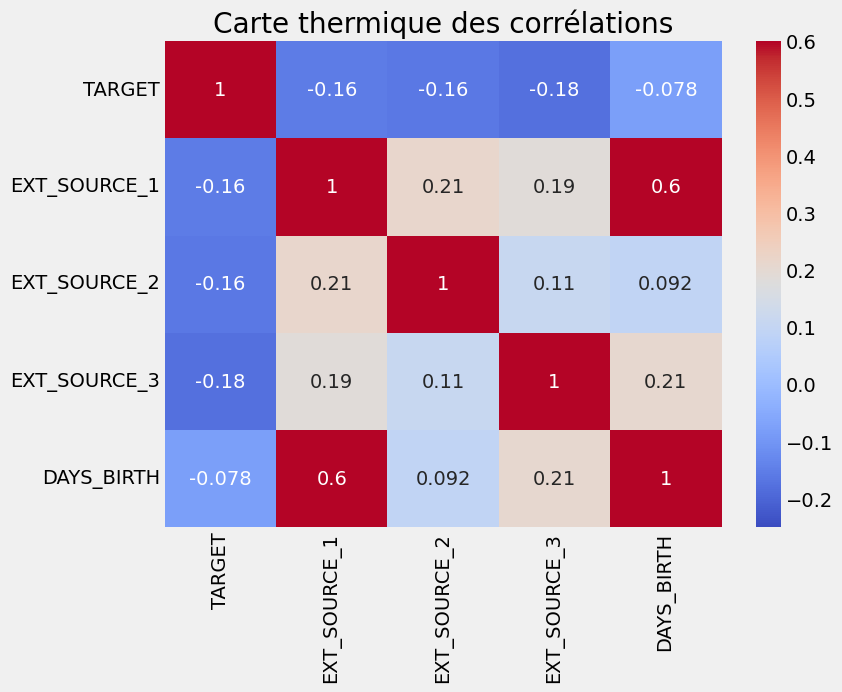

In [31]:
plt.figure(figsize=(8, 6))

# Carte heatmap des corrélations
sns.heatmap(ext_data_corrs, cmap='coolwarm', vmin=-0.25, annot=True, vmax=0.6)
plt.title('Carte thermique des corrélations')
plt.show()

##### Corrélations des variables EXT_SOURCE avec la cible

Les trois variables **EXT_SOURCE** présentent toutes une corrélation négative avec la cible, ce qui indique qu’à mesure que la valeur de ces scores augmente, le client est plus susceptible de rembourser son prêt. 

On remarque également que **DAYS_BIRTH** est positivement corrélé avec **EXT_SOURCE_1**, ce qui suggère que l’âge du client pourrait être un des facteurs pris en compte dans ce score.

Nous allons maintenant examiner la distribution de chacune de ces variables, colorée selon la valeur de la cible. Cela nous permettra de visualiser l’impact de ces variables sur la variable cible.

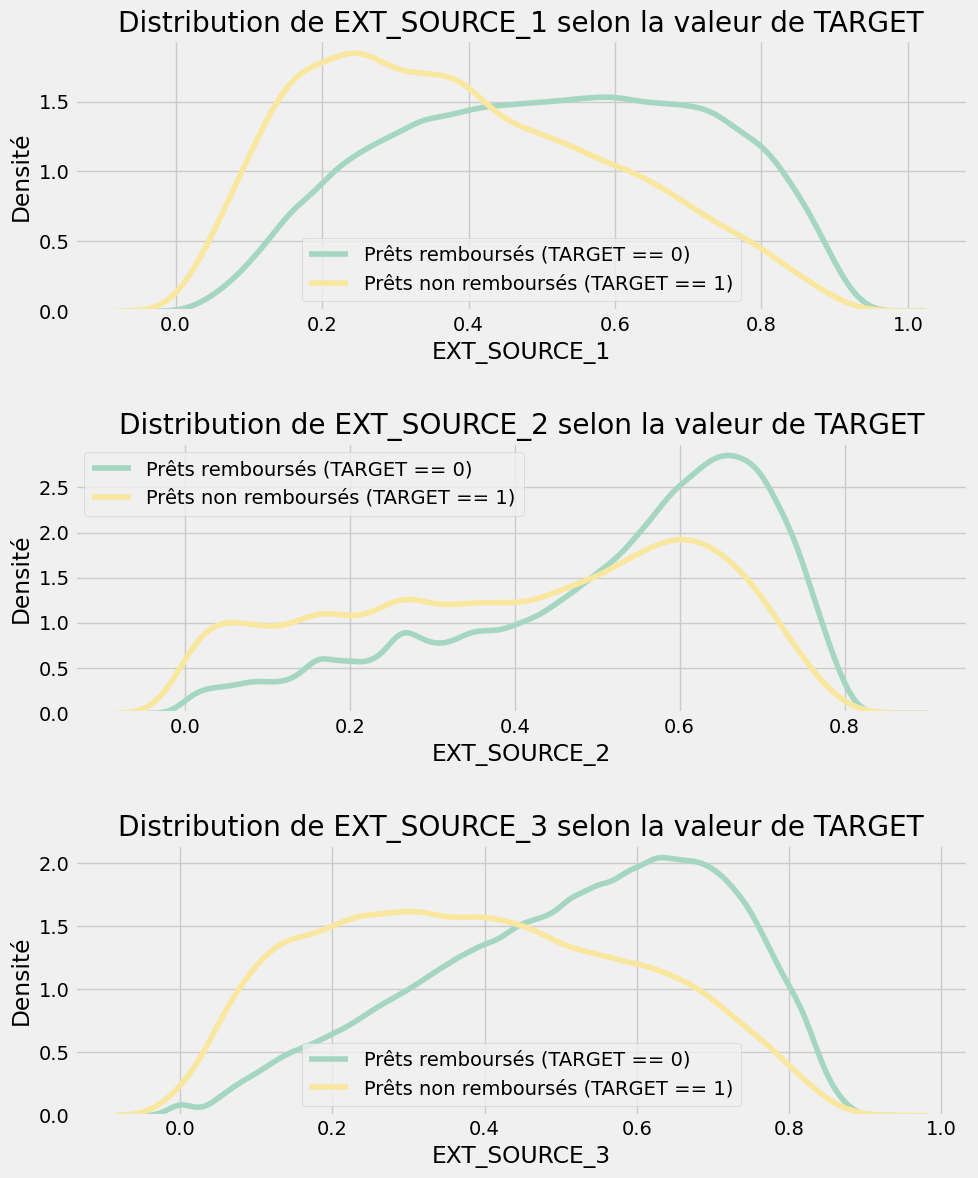

In [32]:
plt.figure(figsize=(10, 12))

# Parcourir les sources EXT_SOURCE
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    
    # Créer un nouveau subplot pour chaque source
    plt.subplot(3, 1, i + 1)
    # Tracer les prêts remboursés
    sns.kdeplot(application_train.loc[application_train['TARGET'] == 0, source], label='Prêts remboursés (TARGET == 0)', color='#A5D6C2')
    # Tracer les prêts non remboursés
    sns.kdeplot(application_train.loc[application_train['TARGET'] == 1, source], label='Prêts non remboursés (TARGET == 1)', color='#F9E79F')
    
    # Étiquetage des graphiques
    plt.title('Distribution de %s selon la valeur de TARGET' % source)
    plt.xlabel('%s' % source)
    plt.ylabel('Densité')
    plt.legend()

plt.tight_layout(h_pad=2.5)
plt.show()

##### Analyse de la variable EXT_SOURCE_3

**EXT_SOURCE_3** montre la plus grande différence entre les valeurs selon la cible. On peut clairement voir que cette variable est liée à la probabilité qu’un demandeur rembourse son prêt.

Cette relation n’est pas très forte (en réalité, toutes ces corrélations sont considérées comme très faibles), mais ces variables restent utiles pour un modèle de machine learning afin de prédire si un demandeur remboursera son prêt à temps ou non.

## 3.4 Pair Plot

Pour conclure notre exploration, nous pouvons réaliser un **Pairs Plot** des variables **EXT_SOURCE** ainsi que de la variable **DAYS_BIRTH**. 

Le Pairs Plot est un excellent outil d’analyse exploratoire car il permet de visualiser à la fois les relations entre plusieurs paires de variables et la distribution de chaque variable individuellement.  

Ici, nous utilisons la bibliothèque Seaborn et la fonction `PairGrid` pour créer un Pairs Plot avec :  
- des nuages de points dans le triangle supérieur,  
- des histogrammes sur la diagonale,  
- des estimations de densité 2D (KDE) et les coefficients de corrélation dans le triangle inférieur.  

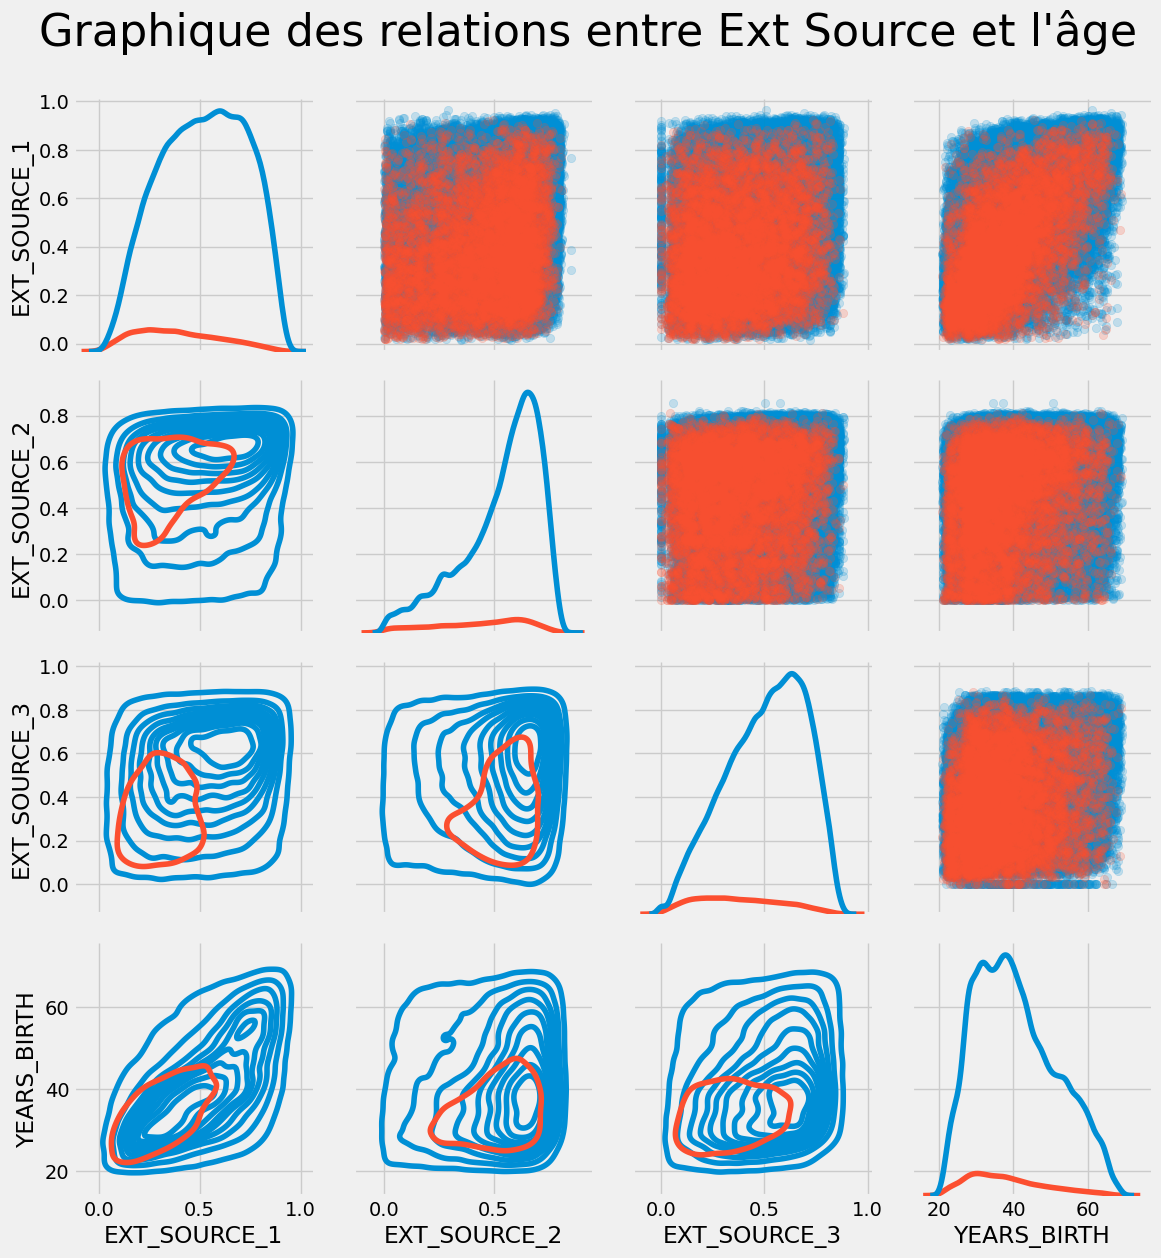

In [33]:
# Copier les données pour la visualisation
plot_data = ext_data.drop(columns=['DAYS_BIRTH']).copy()

# Ajouter l'âge du client en années
plot_data['YEARS_BIRTH'] = age_data['YEARS_BIRTH']

# Supprimer les valeurs manquantes et limiter aux 100 000 premières lignes
plot_data = plot_data.dropna().iloc[:100000, :]

# Fonction pour calculer le coefficient de corrélation entre deux colonnes
def corr_func(x, y, **kwargs):
    r = np.corrcoef(x, y)[0][1]
    ax = plt.gca()
    ax.annotate("r = {:.2f}".format(r),
                xy=(.2, .8), xycoords=ax.transAxes,
                size=20)

# Créer l'objet PairGrid
grid = sns.PairGrid(data=plot_data, height=3, diag_sharey=False,
                    hue='TARGET', 
                    vars=[x for x in list(plot_data.columns) if x != 'TARGET'])

# Tracé supérieur : scatter plot
grid.map_upper(plt.scatter, alpha=0.2)

# Diagonale : histogramme
grid.map_diag(sns.kdeplot)

# Tracé inférieur : density plot
grid.map_lower(sns.kdeplot, cmap='coolwarm')

# Titre du graphique
plt.suptitle('Graphique des relations entre Ext Source et l\'âge', size=32, y=1.05)
plt.show()

##### Interprétation du Pairs Plot

Sur ce graphique, la couleur rouge correspond aux prêts non remboursés, tandis que le bleu représente les prêts remboursés. 

On peut observer les différentes relations présentes dans les données. On remarque notamment une relation linéaire positive modérée entre **EXT_SOURCE_1** et **DAYS_BIRTH** (ou, de manière équivalente, **YEARS_BIRTH**), ce qui suggère que cette variable pourrait intégrer l’âge du client dans son calcul.

# 4. Feature Engineering

In [35]:
# Importer les fonctions du fichier lightgbm_with_simple_features.py
from lightgbm_with_simple_features import (
    one_hot_encoder,
    application_train_test,
    bureau_and_balance,
    previous_applications,
    pos_cash,
    installments_payments,
    credit_card_balance
)

Le feature engineering est un processus global qui inclut à la fois :  
- la **construction de nouvelles fonctionnalités** à partir des données existantes,  
- la **sélection des fonctionnalités** : choisir les plus importantes ou appliquer des méthodes de réduction de dimension.

De nombreuses techniques existent pour créer et sélectionner des fonctionnalités.

Nous ferons beaucoup de feature engineering lorsque nous utiliserons d’autres sources de données, mais dans ce notebook, nous allons tester uniquement deux méthodes simples de construction de fonctionnalités :

- Les **features polynomiales**  
- Les **features issues du domaine métier**

## 4.1 Ajout des variables polynomiales

In [36]:
# Création d'un nouveau dataframe pour les variables polynomiales
poly_features = application_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']]
poly_features_test = application_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

# Imputation des valeurs manquantes
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

poly_target = poly_features['TARGET']

poly_features = poly_features.drop(columns=['TARGET'])

# Imputation des valeurs manquantes
poly_features = imputer.fit_transform(poly_features)
poly_features_test = imputer.transform(poly_features_test)

from sklearn.preprocessing import PolynomialFeatures

# Création de l'objet PolynomialFeatures avec un degré spécifié
poly_transformer = PolynomialFeatures(degree=3)

In [37]:
# Entraînement des caractéristiques polynomiales
poly_transformer.fit(poly_features)

# Transformation des caractéristiques
poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)

# Affichage de la forme des caractéristiques polynomiales
print('Dimensions des caractéristiques polynomiales : ', poly_features.shape)

Dimensions des caractéristiques polynomiales :  (307511, 35)


Cela génère un nombre important de nouvelles fonctionnalités. Pour récupérer leurs noms, nous devons utiliser la méthode `get_feature_names` de l’objet `PolynomialFeatures`.

In [38]:
# Obtenir les noms des caractéristiques polynomiales
poly_feature_names = poly_transformer.get_feature_names_out(input_features=['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH'])

# Afficher les 15 premiers noms de caractéristiques
print(poly_feature_names[:15])

['1' 'EXT_SOURCE_1' 'EXT_SOURCE_2' 'EXT_SOURCE_3' 'DAYS_BIRTH'
 'EXT_SOURCE_1^2' 'EXT_SOURCE_1 EXT_SOURCE_2' 'EXT_SOURCE_1 EXT_SOURCE_3'
 'EXT_SOURCE_1 DAYS_BIRTH' 'EXT_SOURCE_2^2' 'EXT_SOURCE_2 EXT_SOURCE_3'
 'EXT_SOURCE_2 DAYS_BIRTH' 'EXT_SOURCE_3^2' 'EXT_SOURCE_3 DAYS_BIRTH'
 'DAYS_BIRTH^2']


Nous obtenons 35 nouvelles features, comprenant des variables individuelles élevées à des puissances allant jusqu’au degré 3 ainsi que des termes d’interaction. 

Nous pouvons maintenant vérifier si certaines de ces nouvelles features sont corrélées avec la variable cible.

In [39]:
# Créer un dataframe pour les caractéristiques polynomiales
poly_features = pd.DataFrame(poly_features, 
                             columns=poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                             'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Ajouter la variable cible
poly_features['TARGET'] = poly_target

# Calculer les corrélations avec la variable cible
poly_corrs = poly_features.corr()['TARGET'].sort_values()

# Afficher les corrélations les plus négatives et les plus positives
print('Corrélations les plus négatives :\n', poly_corrs.head(10))
print('\nCorrélations les plus positives :\n', poly_corrs.tail(5))

Corrélations les plus négatives :
 EXT_SOURCE_2 EXT_SOURCE_3                -0.193939
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.189605
EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH     -0.181283
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.176428
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.172282
EXT_SOURCE_1 EXT_SOURCE_2                -0.166625
EXT_SOURCE_1 EXT_SOURCE_3                -0.164065
EXT_SOURCE_2                             -0.160295
EXT_SOURCE_2 DAYS_BIRTH                  -0.156873
EXT_SOURCE_1 EXT_SOURCE_2^2              -0.156867
Name: TARGET, dtype: float64

Corrélations les plus positives :
 DAYS_BIRTH     -0.078239
DAYS_BIRTH^2   -0.076672
DAYS_BIRTH^3   -0.074273
TARGET          1.000000
1                    NaN
Name: TARGET, dtype: float64


Plusieurs des nouvelles variables présentent une corrélation plus forte (en valeur absolue) avec la cible que les variables d’origine.  

Lorsque nous construirons des modèles de machine learning, nous pourrons comparer les performances avec et sans ces nouvelles fonctionnalités afin de déterminer si elles améliorent réellement l’apprentissage du modèle.

Nous allons ajouter ces nouvelles features à une copie des jeux de données d’entraînement et de test, puis évaluer les modèles avec et sans ces ajouts.  

In [40]:
# Mettre les caractéristiques de test dans un dataframe
poly_features_test = pd.DataFrame(poly_features_test, 
                                  columns=poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                                 'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Fusionner les caractéristiques polynomiales avec le dataframe d'entraînement
poly_features['SK_ID_CURR'] = application_train['SK_ID_CURR']
application_train_poly = application_train.merge(poly_features, on='SK_ID_CURR', how='left')

# Fusionner les caractéristiques polynomiales avec le dataframe de test
poly_features_test['SK_ID_CURR'] = application_test['SK_ID_CURR']
application_test_poly = application_test.merge(poly_features_test, on='SK_ID_CURR', how='left')

# Aligner les dataframes
application_train_poly, application_test_poly = application_train_poly.align(application_test_poly, join='inner', axis=1)

# Afficher les nouvelles dimensions des datasets
print('Dimensions des données d\'entraînement avec caractéristiques polynomiales : ', application_train_poly.shape)
print('Dimensions des données de test avec caractéristiques polynomiales : ', application_test_poly.shape)

Dimensions des données d'entraînement avec caractéristiques polynomiales :  (307511, 275)
Dimensions des données de test avec caractéristiques polynomiales :  (48744, 275)


## 4.2 Création des nouvelles variables basées sur des connaissances métier

### Features issues des connaissances métier

Nous allons créer quelques features qui tentent de capturer ce que nous pensons important pour prédire si un client fera défaut sur un prêt.  

Je vais utiliser cinq features inspirées par ce script https://www.kaggle.com/code/jsaguiar/lightgbm-with-simple-features?scriptVersionId=6025993 :  

- **CREDIT_INCOME_PERCENT** : pourcentage du montant du crédit par rapport au revenu du client  
- **ANNUITY_INCOME_PERCENT** : pourcentage de l’annuité du prêt par rapport au revenu du client  
- **CREDIT_TERM** : durée du remboursement en mois (puisque l’annuité correspond au montant mensuel dû)  
- **DAYS_EMPLOYED_PERCENT** : pourcentage des jours travaillés par rapport à l’âge du client  

In [41]:
# Copier les datasets d'entraînement et de test pour ajouter des variables basées sur des connaissances métier
application_train_domain = application_train.copy()
application_test_domain = application_test.copy()

# Création de nouvelles variables métier
application_train_domain['CREDIT_INCOME_PERCENT'] = application_train_domain['AMT_CREDIT'] / application_train_domain['AMT_INCOME_TOTAL']
application_train_domain['ANNUITY_INCOME_PERCENT'] = application_train_domain['AMT_ANNUITY'] / application_train_domain['AMT_INCOME_TOTAL']
application_train_domain['CREDIT_TERM'] = application_train_domain['AMT_ANNUITY'] / application_train_domain['AMT_CREDIT']
application_train_domain['DAYS_EMPLOYED_PERCENT'] = application_train_domain['DAYS_EMPLOYED'] / application_train_domain['DAYS_BIRTH']

application_test_domain['CREDIT_INCOME_PERCENT'] = application_test_domain['AMT_CREDIT'] / application_test_domain['AMT_INCOME_TOTAL']
application_test_domain['ANNUITY_INCOME_PERCENT'] = application_test_domain['AMT_ANNUITY'] / application_test_domain['AMT_INCOME_TOTAL']
application_test_domain['CREDIT_TERM'] = application_test_domain['AMT_ANNUITY'] / application_test_domain['AMT_CREDIT']
application_test_domain['DAYS_EMPLOYED_PERCENT'] = application_test_domain['DAYS_EMPLOYED'] / application_test_domain['DAYS_BIRTH']

In [42]:
# Création de nouvelles variables métier pour le dataset de test
application_test_domain['CREDIT_INCOME_PERCENT'] = application_test_domain['AMT_CREDIT'] / application_test_domain['AMT_INCOME_TOTAL']
application_test_domain['ANNUITY_INCOME_PERCENT'] = application_test_domain['AMT_ANNUITY'] / application_test_domain['AMT_INCOME_TOTAL']
application_test_domain['CREDIT_TERM'] = application_test_domain['AMT_ANNUITY'] / application_test_domain['AMT_CREDIT']
application_test_domain['DAYS_EMPLOYED_PERCENT'] = application_test_domain['DAYS_EMPLOYED'] / application_test_domain['DAYS_BIRTH']

##### Visualisation des nouvelles variables

Il est important d’explorer visuellement ces variables issues du domaine métier à l’aide de graphiques.  

Pour chacune d’entre elles, nous réaliserons un graphique de type **KDE** (estimation de densité) coloré en fonction de la valeur de la **TARGET**.

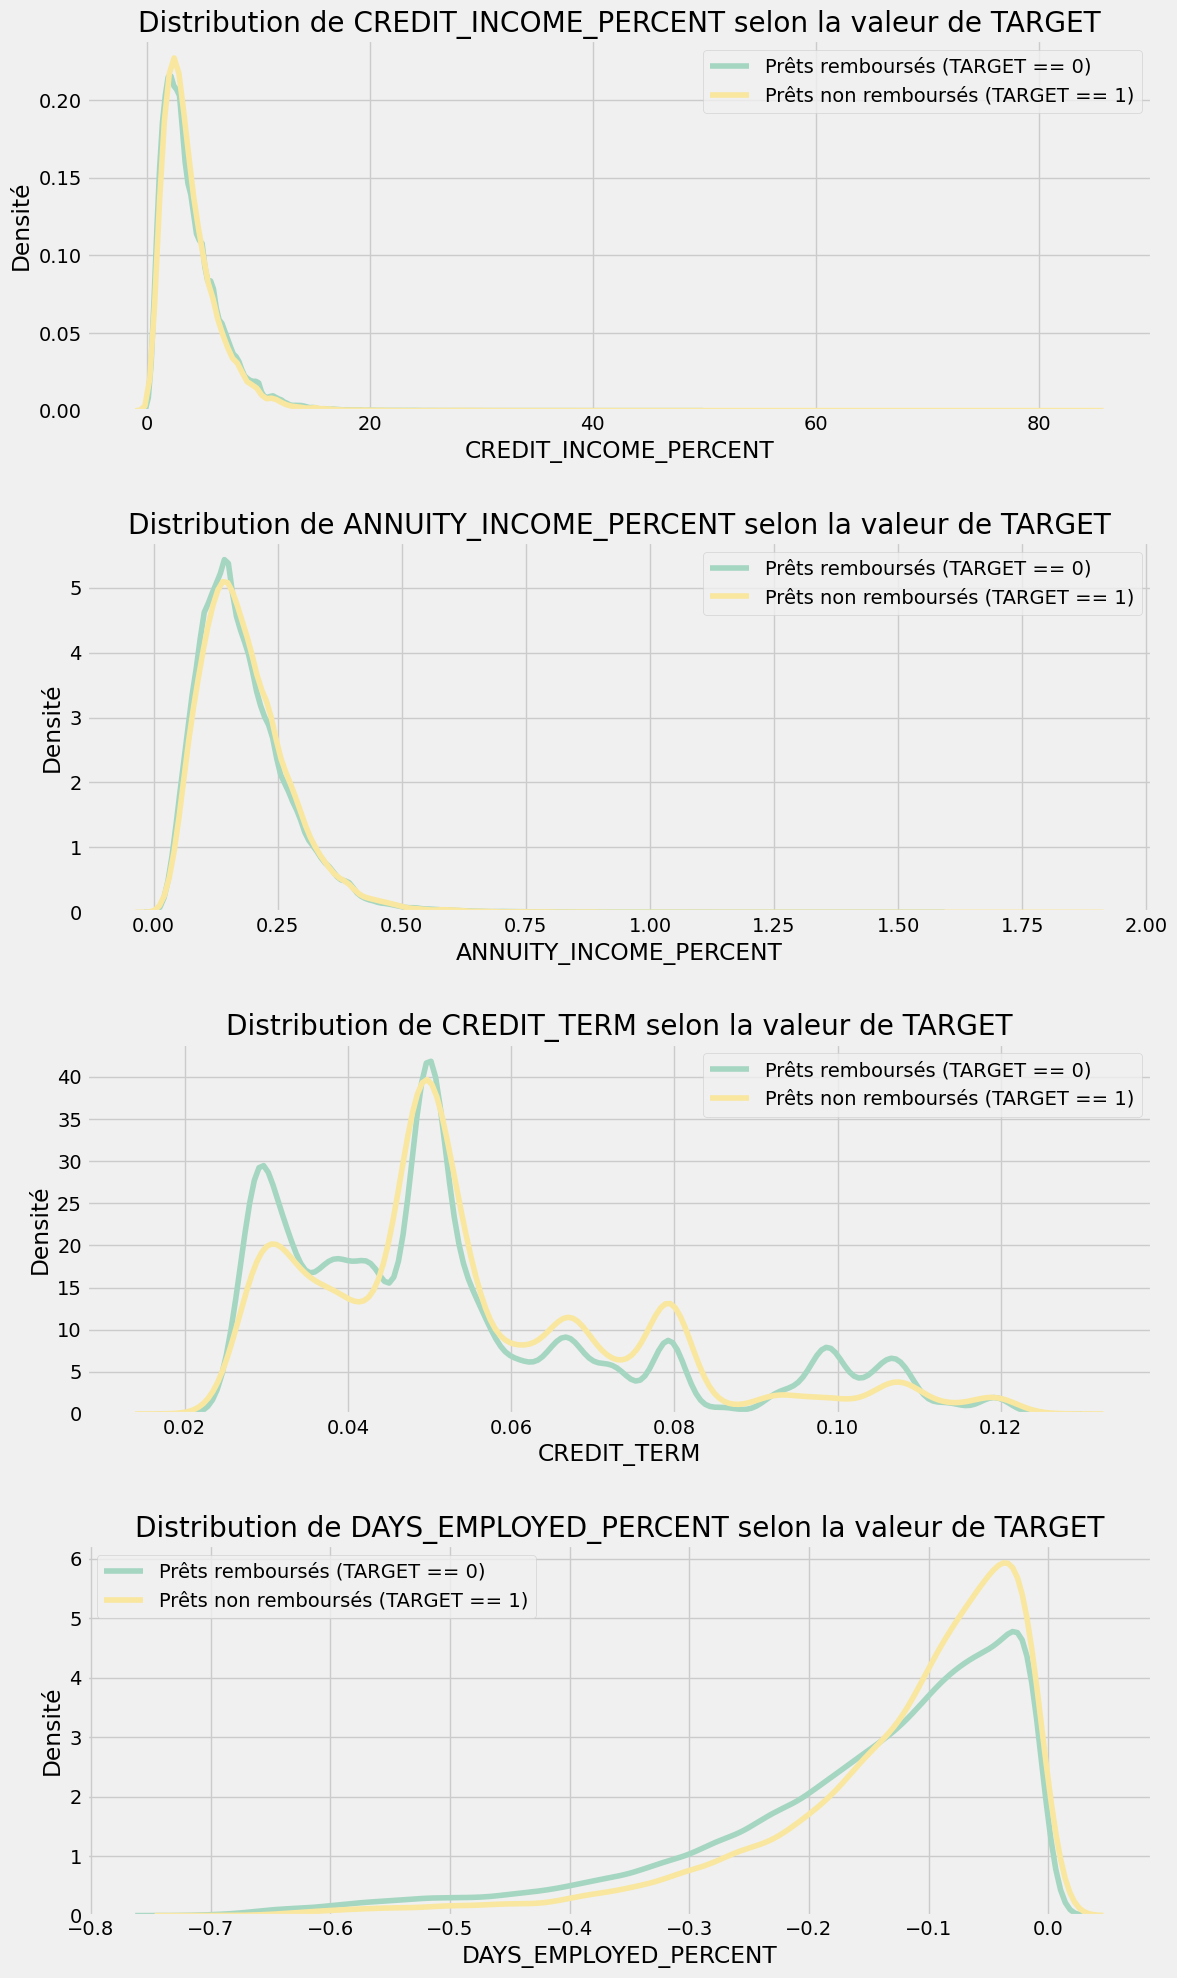

In [43]:
plt.figure(figsize=(12, 20))

# Parcourir les nouvelles variables métier
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    
    # Créer un nouveau subplot pour chaque variable
    plt.subplot(4, 1, i + 1)
    # Tracer les prêts remboursés
    sns.kdeplot(application_train_domain.loc[application_train_domain['TARGET'] == 0, feature], label='Prêts remboursés (TARGET == 0)', color='#A5D6C2')
    # Tracer les prêts non remboursés
    sns.kdeplot(application_train_domain.loc[application_train_domain['TARGET'] == 1, feature], label='Prêts non remboursés (TARGET == 1)', color='#F9E79F')
    
    # Étiquetage des graphiques
    plt.title(f'Distribution de {feature} selon la valeur de TARGET')
    plt.xlabel(feature)
    plt.ylabel('Densité')
    plt.legend()

plt.tight_layout(h_pad=2.5)
plt.show()

## 4.3 Intégration des autres sources de données 

In [45]:
import os
import shutil

# Configuration automatique des chemins pour les fonctions
def setup_input_folder():
    os.makedirs('../input', exist_ok=True)
    csv_files = ['bureau.csv', 'bureau_balance.csv', 'previous_application.csv', 
                 'POS_CASH_balance.csv', 'credit_card_balance.csv', 'installments_payments.csv']
    
    for file in csv_files:
        if os.path.exists(file) and not os.path.exists(f'../input/{file}'):
            shutil.copy2(file, f'../input/{file}')

# Configuration une seule fois
setup_input_folder()

# Traitement bureau (les fonctions lisent directement les fichiers)
bureau_processed = bureau_and_balance()
print(f"Bureau features créées: {bureau_processed.shape}")

# Traitement previous_application
previous_processed = previous_applications()
print(f"Previous application features: {previous_processed.shape}")

# Traitement POS_CASH_balance
pos_processed = pos_cash()
print(f"POS features: {pos_processed.shape}")

# Traitement credit_card_balance
credit_processed = credit_card_balance()
print(f"Credit card features: {credit_processed.shape}")

# Traitement installments_payments
install_processed = installments_payments()
print(f"Installments features: {install_processed.shape}")

print("Toutes les sources de données traitées")

Bureau features créées: (305811, 116)
Previous application features: (338857, 249)
POS features: (337252, 18)
Credit card features: (103558, 141)
Installments features: (339587, 26)
Toutes les sources de données traitées


Résumé des features créées :
- Bureau : 305,811 clients avec 116 features
- Previous applications : 338,857 clients avec 249 features
- POS Cash : 337,252 clients avec 18 features
- Credit card : 103,558 clients avec 141 features
- Installments : 339,587 clients avec 26 features

Total : 550 features générées à partir de toutes les sources auxiliaires

# 5. Modélisations

In [46]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

def create_train_val_split(application_train, test_size=0.2, random_state=42):
    """
    Séparer application_train en train/validation
    application_test reste UNIQUEMENT pour la soumission finale
    """
    print("Séparation stratifiée train/validation...")
    
    # Vérifier la présence de TARGET
    if 'TARGET' not in application_train.columns:
        raise ValueError("TARGET manquante dans application_train!")
    
    # Séparer features et target
    X = application_train.drop(['TARGET'], axis=1)
    y = application_train['TARGET']
    
    print(f"Dataset original: {X.shape}")
    print(f"Distribution TARGET: {y.value_counts(normalize=True).round(3).to_dict()}")
    
    # Split stratifié pour conserver les proportions
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=y
    )
    
    print(f"\nAPRÈS SÉPARATION:")
    print(f"Train: {X_train.shape}")
    print(f"Validation: {X_val.shape}")
    print(f"Distribution train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
    print(f"Distribution validation: {y_val.value_counts(normalize=True).round(3).to_dict()}")
    
    return X_train, X_val, y_train, y_val

# Créer la séparation AVANT tout preprocessing
X_train_raw, X_val_raw, y_train, y_val = create_train_val_split(application_train)

print(f"Données séparées avec succès!")
print(f"application_test ({application_test.shape}) reste pour soumission finale uniquement")

Séparation stratifiée train/validation...
Dataset original: (307511, 240)
Distribution TARGET: {0: 0.919, 1: 0.081}

APRÈS SÉPARATION:
Train: (246008, 240)
Validation: (61503, 240)
Distribution train: {0: 0.919, 1: 0.081}
Distribution validation: {0: 0.919, 1: 0.081}
Données séparées avec succès!
application_test ((48744, 240)) reste pour soumission finale uniquement


Analyse de 10 features pour détecter le data drift...


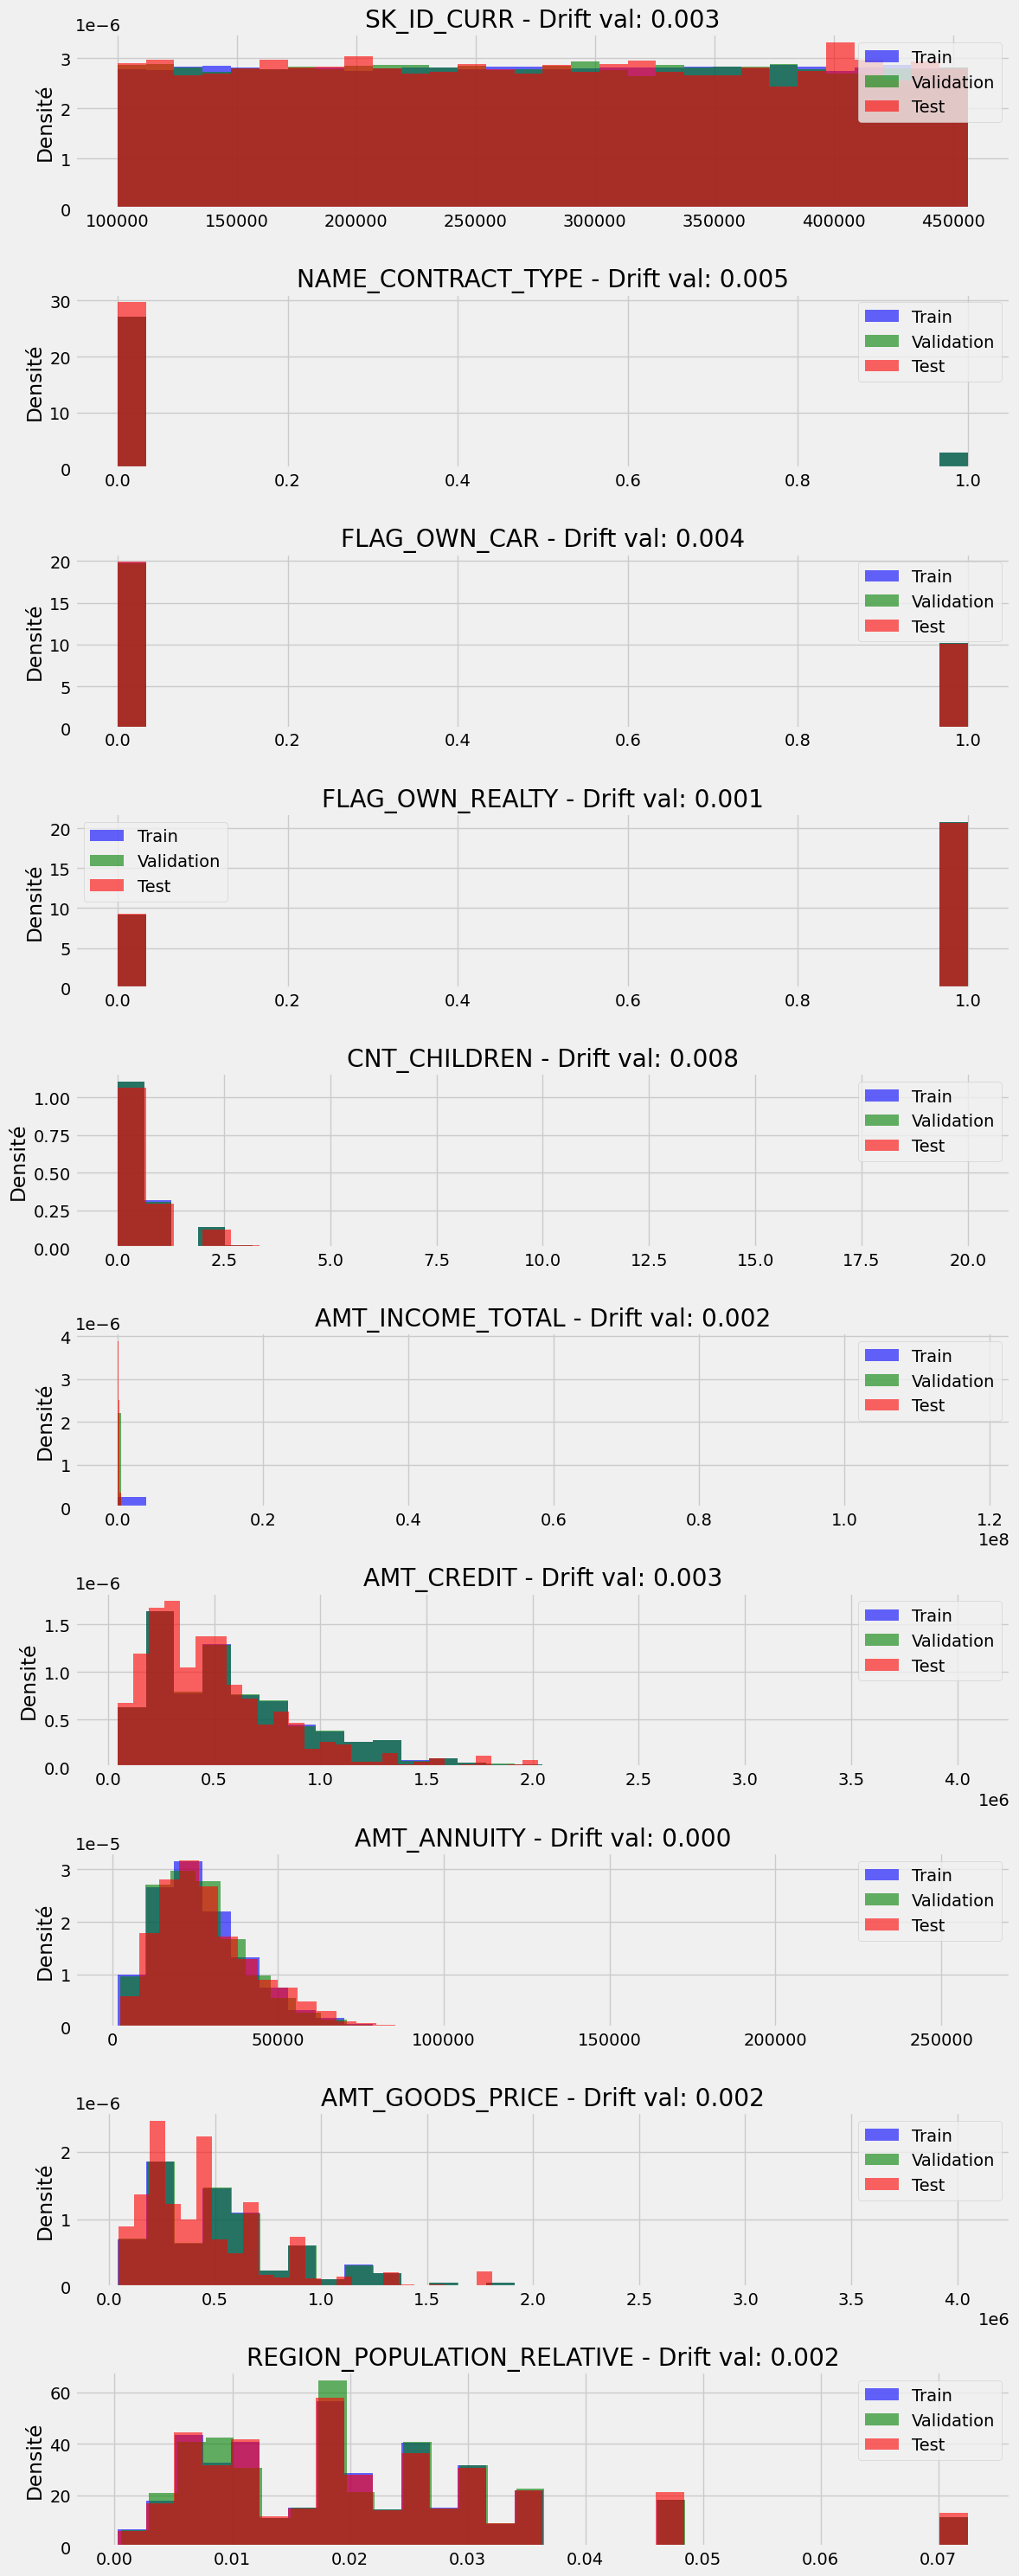

RAPPORT DE DATA DRIFT:
                      feature  val_drift  test_drift
4                CNT_CHILDREN   0.007715    0.046481
1          NAME_CONTRACT_TYPE   0.005304    0.905510
2                FLAG_OWN_CAR   0.004446    0.007879
0                  SK_ID_CURR   0.002781    0.001935
6                  AMT_CREDIT   0.002605    0.137815
8             AMT_GOODS_PRICE   0.002383    0.141156
9  REGION_POPULATION_RELATIVE   0.002356    0.017612
5            AMT_INCOME_TOTAL   0.001636    0.056728
3             FLAG_OWN_REALTY   0.001200    0.004805
7                 AMT_ANNUITY   0.000089    0.085515

Pas de drift significatif détecté (<10%)


In [47]:
def analyze_data_drift(X_train, X_val, application_test, features_to_check=None):
    """
    Analyse critique du data drift entre train, validation et test
    """
    if features_to_check is None:
        # Sélectionner features numériques importantes
        numeric_features = X_train.select_dtypes(include=[np.number]).columns
        # Prendre les 10 premières pour l'analyse
        features_to_check = numeric_features[:10]
    
    print(f"Analyse de {len(features_to_check)} features pour détecter le data drift...")
    
    drift_summary = []
    
    fig, axes = plt.subplots(len(features_to_check), 1, figsize=(12, 3*len(features_to_check)))
    if len(features_to_check) == 1:
        axes = [axes]
    
    for i, feature in enumerate(features_to_check):
        ax = axes[i]
        
        # Calculer les statistiques
        train_mean = X_train[feature].mean()
        val_mean = X_val[feature].mean()
        test_mean = application_test[feature].mean() if feature in application_test.columns else np.nan
        
        train_std = X_train[feature].std()
        val_std = X_val[feature].std()
        test_std = application_test[feature].std() if feature in application_test.columns else np.nan
        
        # Calculer le drift (différence relative des moyennes)
        val_drift = abs(train_mean - val_mean) / train_mean if train_mean != 0 else 0
        test_drift = abs(train_mean - test_mean) / train_mean if train_mean != 0 and not np.isnan(test_mean) else np.nan
        
        drift_summary.append({
            'feature': feature,
            'train_mean': train_mean,
            'val_mean': val_mean,
            'test_mean': test_mean,
            'val_drift': val_drift,
            'test_drift': test_drift
        })
        
        # Visualisation des distributions
        if not X_train[feature].dropna().empty:
            ax.hist(X_train[feature].dropna(), alpha=0.6, label='Train', bins=30, density=True, color='blue')
        if not X_val[feature].dropna().empty:
            ax.hist(X_val[feature].dropna(), alpha=0.6, label='Validation', bins=30, density=True, color='green')
        if feature in application_test.columns and not application_test[feature].dropna().empty:
            ax.hist(application_test[feature].dropna(), alpha=0.6, label='Test', bins=30, density=True, color='red')
        
        ax.set_title(f'{feature} - Drift val: {val_drift:.3f}')
        ax.legend()
        ax.set_ylabel('Densité')
    
    plt.tight_layout()
    plt.show()
    
    # Rapport de drift
    drift_df = pd.DataFrame(drift_summary)
    drift_df = drift_df.sort_values('val_drift', ascending=False)
    
    print("RAPPORT DE DATA DRIFT:")
    print("=" * 50)
    print(drift_df[['feature', 'val_drift', 'test_drift']].head(10))
    
    # Alertes
    high_drift = drift_df[drift_df['val_drift'] > 0.1]
    if not high_drift.empty:
        print(f"\n⚠ATTENTION: {len(high_drift)} features avec drift élevé (>10%):")
        print(high_drift[['feature', 'val_drift']].head())
    else:
        print("\nPas de drift significatif détecté (<10%)")
    
    return drift_df

# Analyser le drift AVANT preprocessing
drift_analysis = analyze_data_drift(X_train_raw, X_val_raw, application_test)

## 5.1 Preprocess 

##### Objectif :
- Construire une baseline et tester plusieurs modèles pour évaluer leurs performances initiales.
- Utiliser des métriques techniques comme l'AUC pour comparer les modèles.

##### Étapes :
1. Baseline avec DummyClassifier :
- Utiliser un DummyClassifier avec la stratégie "most_frequent" pour établir une référence naïve.
- Comparer des performances des modèles avancés à cette baseline.

##### Tester plusieurs modèles sans gestion du déséquilibre :
- Régression logistique (LogisticRegression).
- Random Forest (RandomForestClassifier).
- XGBoost (XGBClassifier).
  
##### Pourquoi ?
Cela nous permet d'identifier les modèles les plus prometteurs avant d'ajouter des techniques de gestion du déséquilibre ou d'optimisation.

In [48]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

def preprocess_data_corrected(X_train, X_val, application_test):
    """
    PREPROCESSING CORRIGÉ:
    - FIT uniquement sur les données d'entraînement
    - TRANSFORM sur validation et test
    - Évite le data leakage
    """
    print("Début du preprocessing sans data leakage...")
    
    # Vérifier l'alignement des colonnes
    common_features = list(set(X_train.columns) & set(X_val.columns) & set(application_test.columns))
    print(f"Features communes: {len(common_features)}")
    
    # Garder uniquement les features communes
    X_train_aligned = X_train[common_features].copy()
    X_val_aligned = X_val[common_features].copy()
    test_aligned = application_test[common_features].copy()
    
    print(f"  Shapes après alignement:")
    print(f"  Train: {X_train_aligned.shape}")
    print(f"  Validation: {X_val_aligned.shape}")
    print(f"  Test: {test_aligned.shape}")
    
    # 1. IMPUTATION (FIT sur train uniquement)
    print("🔧 Imputation des valeurs manquantes...")
    imputer = SimpleImputer(strategy='median')
    
    # FIT uniquement sur train
    X_train_imputed = imputer.fit_transform(X_train_aligned)
    # TRANSFORM sur validation et test
    X_val_imputed = imputer.transform(X_val_aligned)
    test_imputed = imputer.transform(test_aligned)
    
    print(f"Imputation terminée")
    
    # 2. SCALING (FIT sur train uniquement)
    print("Normalisation des données...")
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    # FIT uniquement sur train
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    # TRANSFORM sur validation et test
    X_val_scaled = scaler.transform(X_val_imputed)
    test_scaled = scaler.transform(test_imputed)
    
    print(f"Normalisation terminée")
    print(f"  Shapes finales:")
    print(f"  Train: {X_train_scaled.shape}")
    print(f"  Validation: {X_val_scaled.shape}")
    print(f"  Test: {test_scaled.shape}")
    
    return X_train_scaled, X_val_scaled, test_scaled, imputer, scaler, common_features

# Appliquer le preprocessing corrigé
X_train_processed, X_val_processed, test_processed, imputer, scaler, features = preprocess_data_corrected(
    X_train_raw, X_val_raw, application_test
)

print("Preprocessing terminé sans data leakage!")

Début du preprocessing sans data leakage...
Features communes: 240
  Shapes après alignement:
  Train: (246008, 240)
  Validation: (61503, 240)
  Test: (48744, 240)
🔧 Imputation des valeurs manquantes...
Imputation terminée
Normalisation des données...
Normalisation terminée
  Shapes finales:
  Train: (246008, 240)
  Validation: (61503, 240)
  Test: (48744, 240)
Preprocessing terminé sans data leakage!


In [49]:
def train_and_evaluate_corrected(model, model_name, X_train, y_train, X_val, y_val, params=None):
    """
    FONCTION CORRIGÉE pour entraînement et évaluation
    - Entraînement sur train uniquement
    - Évaluation sur train ET validation
    - Détection automatique du surapprentissage
    """
    from sklearn.metrics import roc_auc_score, classification_report
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    with mlflow.start_run(run_name=f"{model_name}_corrected"):
        print(f"\n{'='*50}")
        print(f"  ENTRAÎNEMENT: {model_name}")
        print(f"{'='*50}")
        
        # Entraînement sur train UNIQUEMENT
        model.fit(X_train, y_train)
        
        # Prédictions sur train et validation
        train_pred_proba = model.predict_proba(X_train)[:, 1]
        val_pred_proba = model.predict_proba(X_val)[:, 1]
        
        train_pred_class = model.predict(X_train)
        val_pred_class = model.predict(X_val)
        
        # Calcul des métriques
        train_auc = roc_auc_score(y_train, train_pred_proba)
        val_auc = roc_auc_score(y_val, val_pred_proba)
        
        # Détection du surapprentissage
        overfitting_gap = train_auc - val_auc
        
        # Logging MLflow
        if params:
            mlflow.log_params(params)
        else:
            mlflow.log_param("model_name", model_name)
        
        mlflow.log_metric("train_auc", train_auc)
        mlflow.log_metric("val_auc", val_auc)
        mlflow.log_metric("overfitting_gap", overfitting_gap)
        
        # Affichage des résultats
        print(f"  MÉTRIQUES:")
        print(f"  Train AUC: {train_auc:.4f}")
        print(f"  Validation AUC: {val_auc:.4f}")
        print(f"  Écart (overfitting): {overfitting_gap:.4f}")
        
        # Diagnostics
        if overfitting_gap > 0.05:
            print("SURAPPRENTISSAGE DÉTECTÉ! (écart > 0.05)")
            mlflow.log_param("overfitting_status", "HIGH")
        elif overfitting_gap > 0.02:
            print("Surapprentissage modéré (écart > 0.02)")
            mlflow.log_param("overfitting_status", "MODERATE")
        elif overfitting_gap < -0.02:
            print("SOUS-APPRENTISSAGE POTENTIEL! (val > train)")
            mlflow.log_param("overfitting_status", "UNDERFIT")
        else:
            print("Modèle équilibré")
            mlflow.log_param("overfitting_status", "GOOD")
        
        # Matrice de confusion validation
        from sklearn.metrics import confusion_matrix
        cm_val = confusion_matrix(y_val, val_pred_class)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['No Default', 'Default'], 
                   yticklabels=['No Default', 'Default'])
        plt.title(f'Matrice de Confusion - {model_name} (Validation)')
        plt.xlabel('Prédictions')
        plt.ylabel('Vérité')
        plt.savefig(f"{model_name}_confusion_matrix.png")
        mlflow.log_artifact(f"{model_name}_confusion_matrix.png")
        plt.show()
        
        # Courbe ROC
        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(y_val, val_pred_proba)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {val_auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        plt.xlabel('Taux Faux Positifs')
        plt.ylabel('Taux Vrais Positifs')
        plt.title(f'Courbe ROC - {model_name} (Validation)')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.savefig(f"{model_name}_roc_curve.png")
        mlflow.log_artifact(f"{model_name}_roc_curve.png")
        plt.show()
        
        # Sauvegarde du modèle
        mlflow.sklearn.log_model(model, f"{model_name}_model")
        
        print(f"{model_name} terminé et loggé dans MLflow")
    
    return model, train_auc, val_auc, overfitting_gap

## 5.2 DummyClassifier (Baseline)

Test des modèles sans gestion du déséquilibre...

  ENTRAÎNEMENT: DummyClassifier
  MÉTRIQUES:
  Train AUC: 0.5000
  Validation AUC: 0.5000
  Écart (overfitting): 0.0000
Modèle équilibré


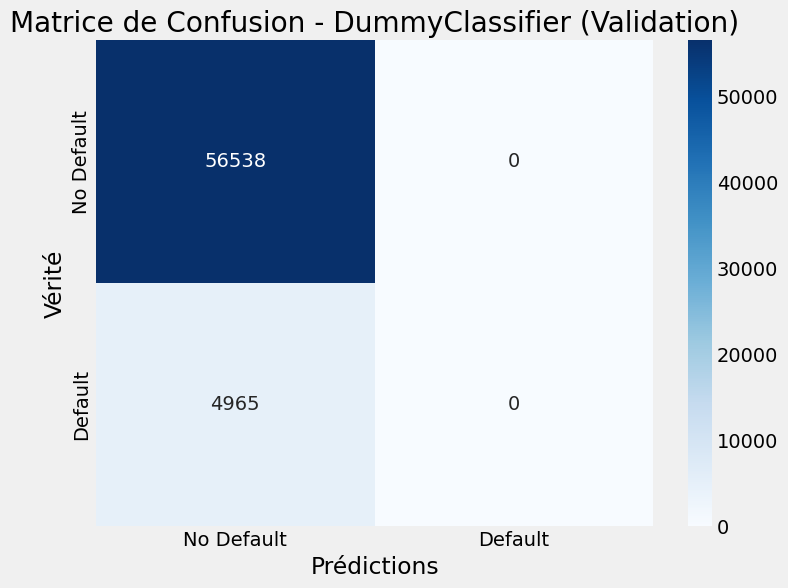

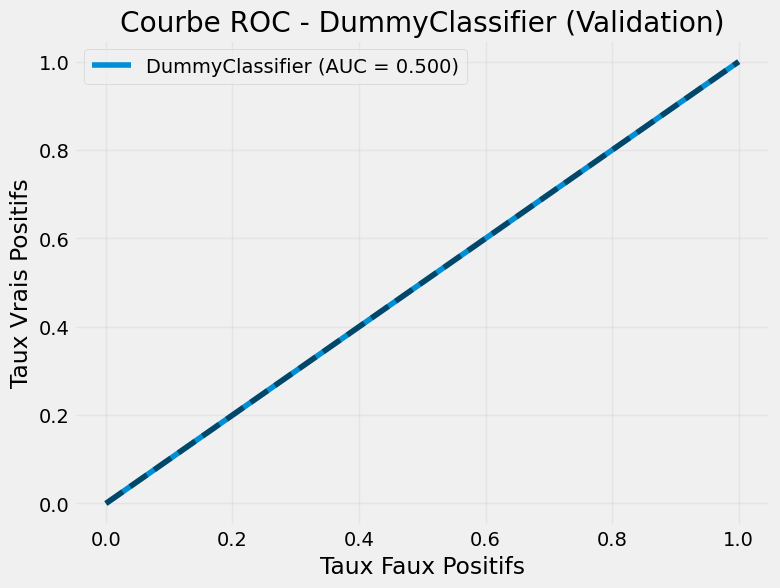

2025/09/28 11:31:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:31:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


DummyClassifier terminé et loggé dans MLflow
🏃 View run DummyClassifier_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/50009046369642a5b9a594bd4fa2b59f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009


In [50]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Stockage des résultats
results_baseline = {}

print("Test des modèles sans gestion du déséquilibre...")

# DummyClassifier (Baseline)
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_model, dummy_train_auc, dummy_val_auc, dummy_gap = train_and_evaluate_corrected(
    dummy_clf, "DummyClassifier", 
    X_train_processed, y_train, X_val_processed, y_val,
    params={"strategy": "most_frequent"}
)
results_baseline['DummyClassifier'] = {
    'model': dummy_model, 'train_auc': dummy_train_auc, 
    'val_auc': dummy_val_auc, 'gap': dummy_gap
}

- C=0.0001 : Ce paramètre contrôle la régularisation du modèle. Une valeur faible de C (comme ici) impose une régularisation forte, ce qui réduit le risque de surapprentissage (overfitting).
La régularisation pénalise les coefficients trop grands dans le modèle.

- solver='liblinear' : Ce paramètre spécifie l'algorithme utilisé pour optimiser le modèle. liblinear est un solveur adapté aux petits datasets et aux problèmes de classification binaires.

## 5.3 Logistic Regression


  ENTRAÎNEMENT: LogisticRegression
  MÉTRIQUES:
  Train AUC: 0.6814
  Validation AUC: 0.6830
  Écart (overfitting): -0.0016
Modèle équilibré


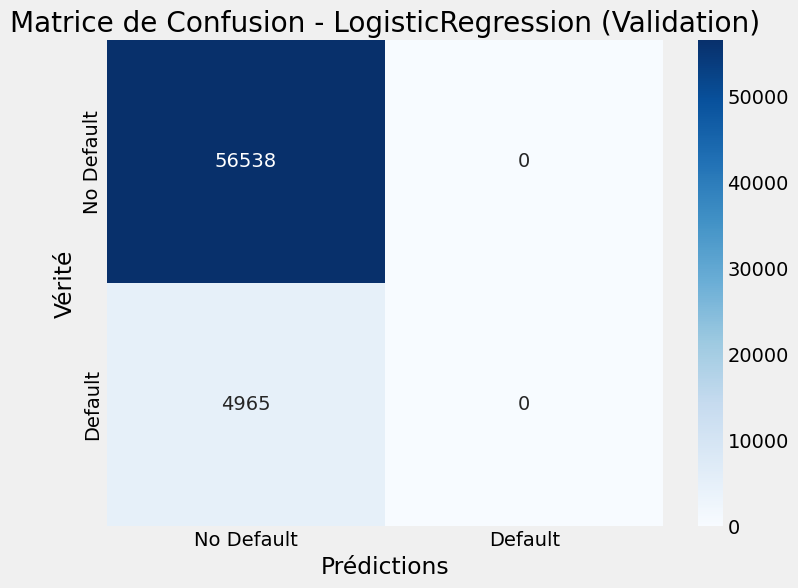

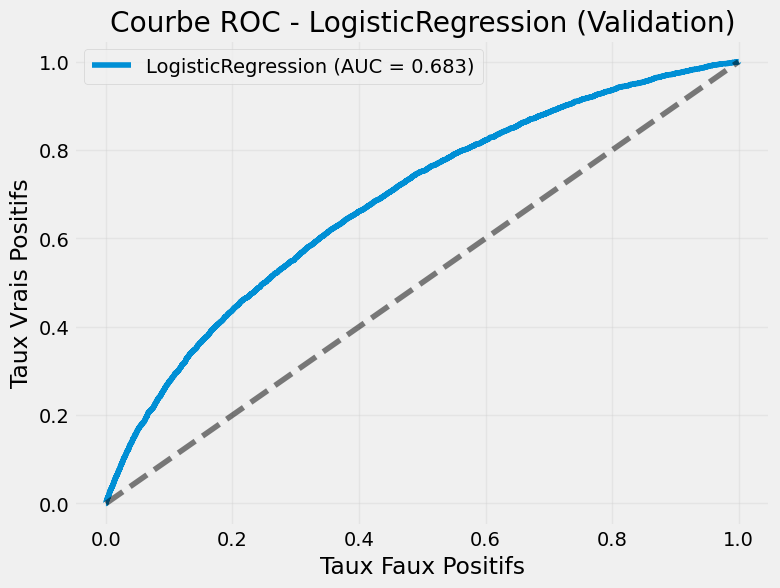

2025/09/28 11:31:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:31:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LogisticRegression terminé et loggé dans MLflow
🏃 View run LogisticRegression_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/5167b178418740968ccb2a8d7149cbbb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009


In [51]:
# Logistic Regression
log_reg = LogisticRegression(C=0.0001, solver='liblinear', random_state=42)
lr_model, lr_train_auc, lr_val_auc, lr_gap = train_and_evaluate_corrected(
    log_reg, "LogisticRegression", 
    X_train_processed, y_train, X_val_processed, y_val,
    params={"C": 0.0001, "solver": "liblinear"}
)
results_baseline['LogisticRegression'] = {
    'model': lr_model, 'train_auc': lr_train_auc, 
    'val_auc': lr_val_auc, 'gap': lr_gap
}

## 5.4 Random Forest


  ENTRAÎNEMENT: RandomForest
  MÉTRIQUES:
  Train AUC: 0.7288
  Validation AUC: 0.7236
  Écart (overfitting): 0.0052
Modèle équilibré


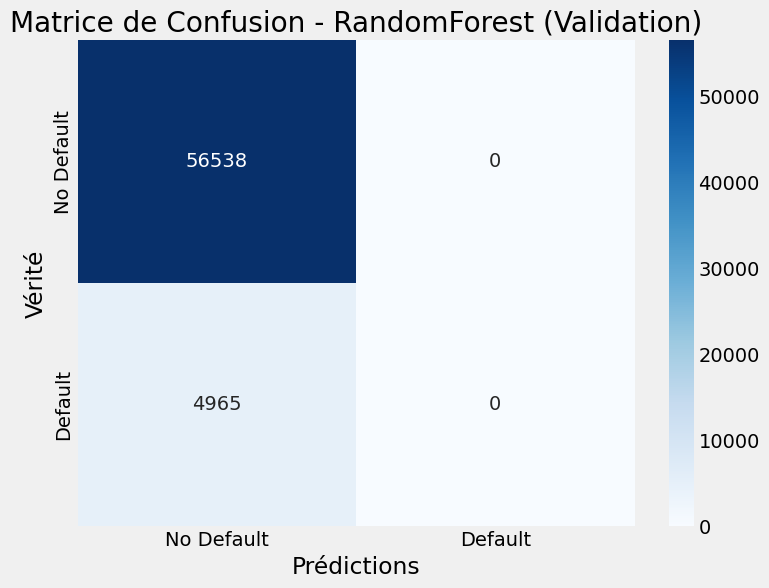

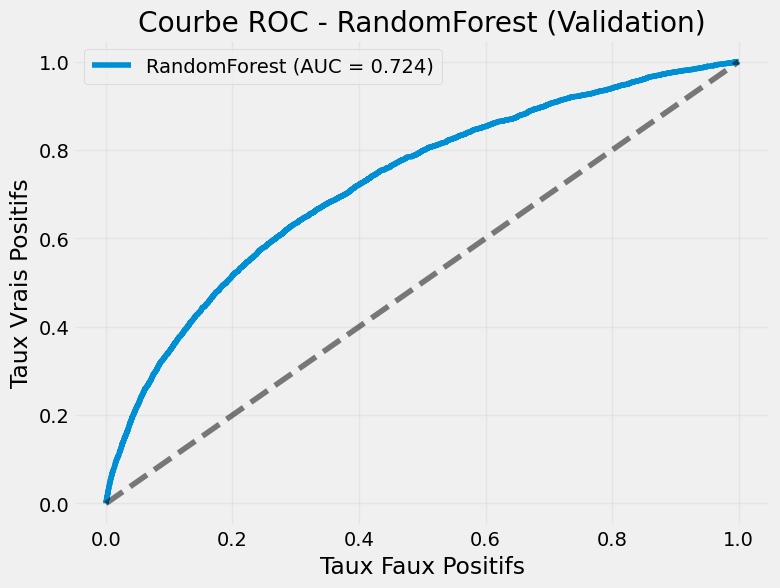

2025/09/28 11:31:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:32:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


RandomForest terminé et loggé dans MLflow
🏃 View run RandomForest_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/4fd52859d1b140f58d7feb4ad1331805
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009


In [52]:
# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model, rf_train_auc, rf_val_auc, rf_gap = train_and_evaluate_corrected(
    rf_clf, "RandomForest", 
    X_train_processed, y_train, X_val_processed, y_val,
    params={"n_estimators": 100, "max_depth": 5}
)
results_baseline['RandomForest'] = {
    'model': rf_model, 'train_auc': rf_train_auc, 
    'val_auc': rf_val_auc, 'gap': rf_gap
}

## 5.5 XGBoost


  ENTRAÎNEMENT: XGBoost
  MÉTRIQUES:
  Train AUC: 0.8545
  Validation AUC: 0.7515
  Écart (overfitting): 0.1030
SURAPPRENTISSAGE DÉTECTÉ! (écart > 0.05)


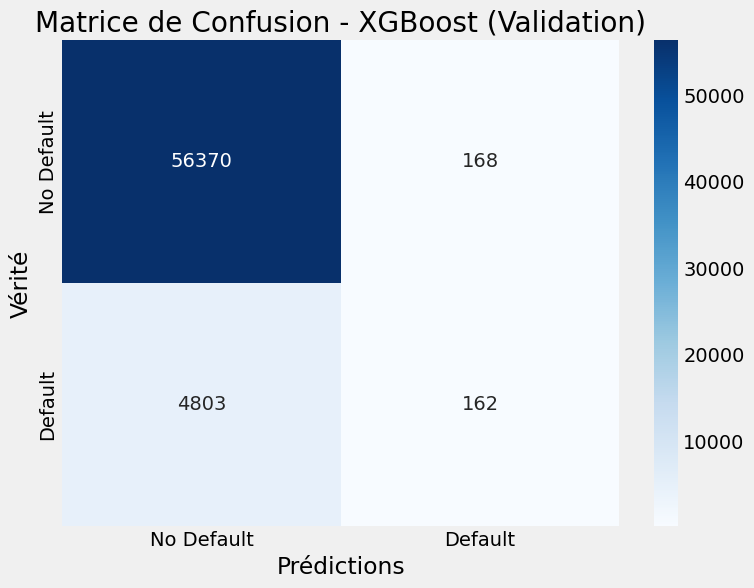

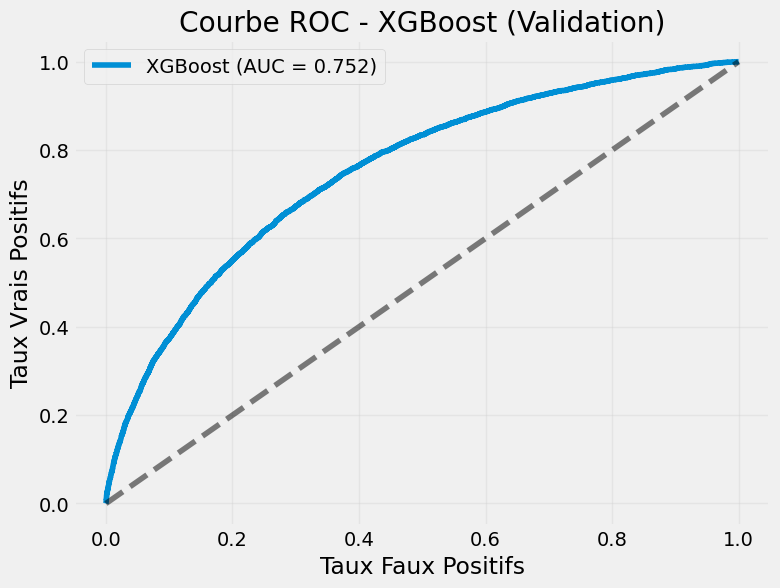

2025/09/28 11:32:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:32:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost terminé et loggé dans MLflow
🏃 View run XGBoost_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/2a6a377e02de406c9b0fd32286a7067a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009


In [53]:
# XGBoost
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_model, xgb_train_auc, xgb_val_auc, xgb_gap = train_and_evaluate_corrected(
    xgb_clf, "XGBoost", 
    X_train_processed, y_train, X_val_processed, y_val,
    params={"use_label_encoder": False, "eval_metric": "logloss"}
)
results_baseline['XGBoost'] = {
    'model': xgb_model, 'train_auc': xgb_train_auc, 
    'val_auc': xgb_val_auc, 'gap': xgb_gap
}

## 5.6 LightGBM


  ENTRAÎNEMENT: LightGBM
  MÉTRIQUES:
  Train AUC: 0.7982
  Validation AUC: 0.7583
  Écart (overfitting): 0.0399
Surapprentissage modéré (écart > 0.02)


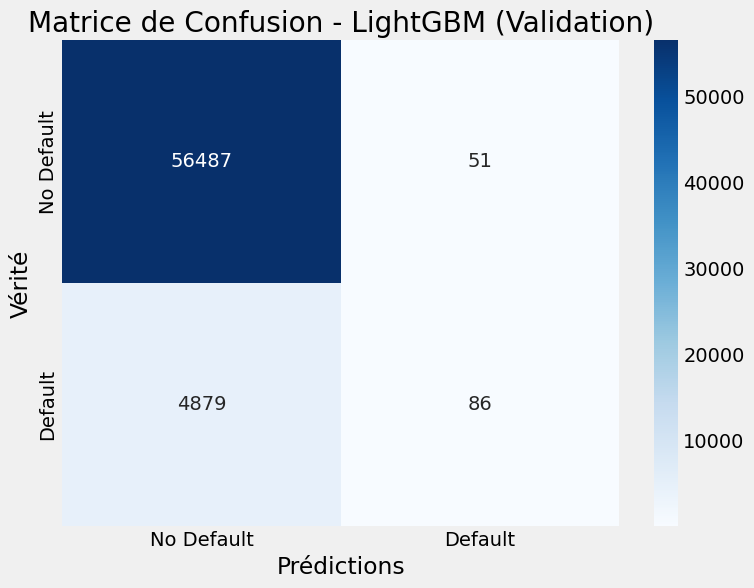

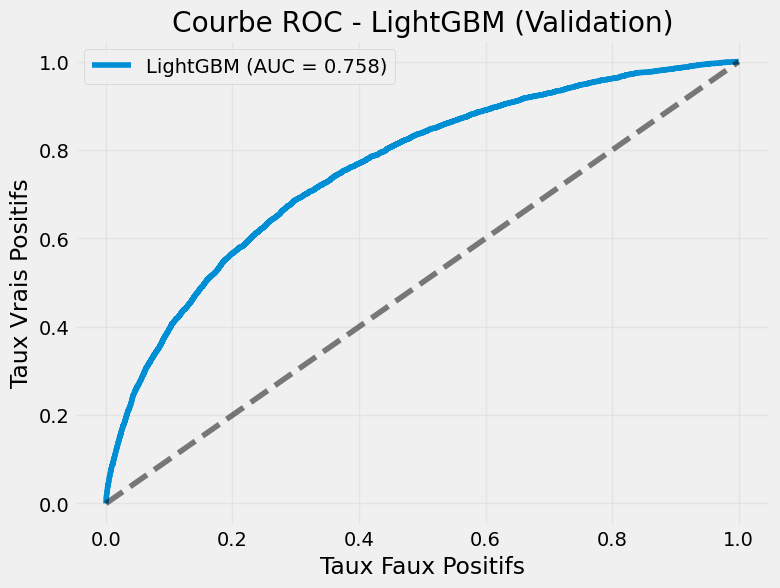

2025/09/28 11:32:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:32:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM terminé et loggé dans MLflow
🏃 View run LightGBM_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/78bb785eee4c49d589f8f702ead45f89
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009

🎯 Tous les modèles de base testés!


In [54]:
# LightGBM
lgb_clf = LGBMClassifier(random_state=42, verbose=-1)
lgb_model, lgb_train_auc, lgb_val_auc, lgb_gap = train_and_evaluate_corrected(
    lgb_clf, "LightGBM", 
    X_train_processed, y_train, X_val_processed, y_val,
    params={"verbose": -1}
)
results_baseline['LightGBM'] = {
    'model': lgb_model, 'train_auc': lgb_train_auc, 
    'val_auc': lgb_val_auc, 'gap': lgb_gap
}

print("\n🎯 Tous les modèles de base testés!")

# 6. Gestion du déséquilibre des classes

##### Objectif :
- Traiter le déséquilibre des classes pour éviter que les modèles favorisent la classe majoritaire.
- Tester les techniques de gestion du déséquilibre avec le modèle le plus prometteur (par exemple, Random Forest ou Logistic Regression).

##### Techniques recommandées :
1. Pondération des classes : Utiliser class_weight='balanced' pour pondérer automatiquement les classes en fonction de leur fréquence.
2. Sur-échantillonnage avec SMOTE : Utiliser SMOTE pour générer des exemples synthétiques de la classe minoritaire.
3. Sous-échantillonnage : Réduire la taille de la classe majoritaire pour équilibrer les classes.

Commencençons avec Logistic Regression et Random Forest, car ils sont rapides à entraîner et interprétables.

## 6.1 Pondération des Classes (class_weight='balanced')

Logistic Regression (Balanced)

  ENTRAÎNEMENT: LogisticRegression_Balanced
  MÉTRIQUES:
  Train AUC: 0.7108
  Validation AUC: 0.7137
  Écart (overfitting): -0.0029
Modèle équilibré


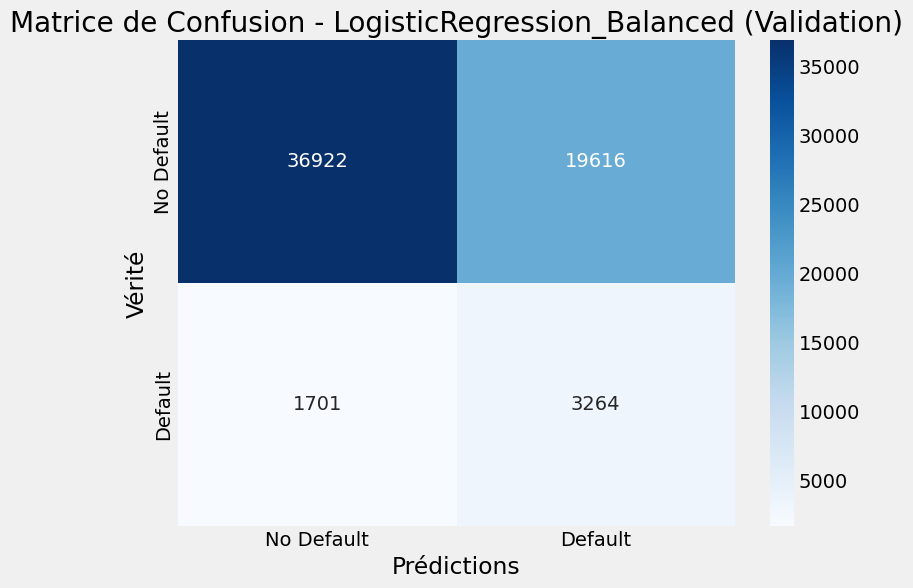

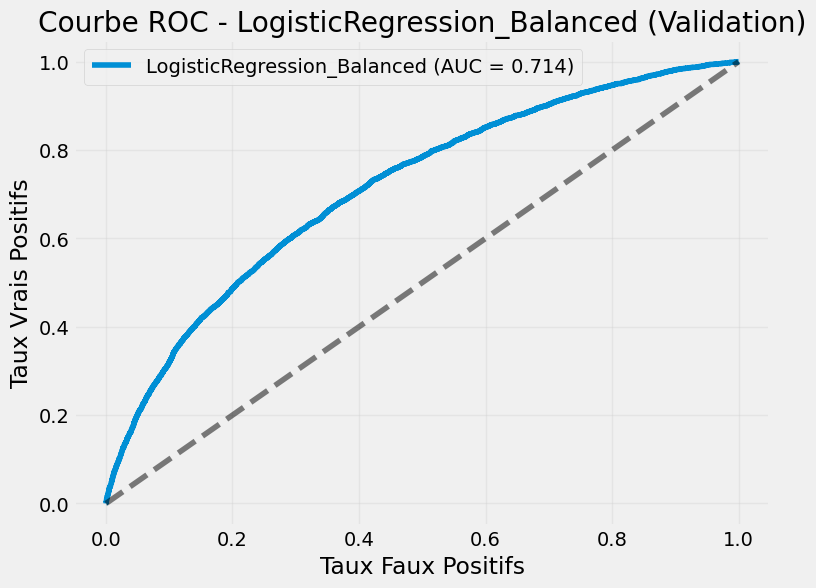

2025/09/28 11:32:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:32:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LogisticRegression_Balanced terminé et loggé dans MLflow
🏃 View run LogisticRegression_Balanced_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/36dcdd5f751c49339c53c2ca4758671e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009
Random Forest (Balanced)

  ENTRAÎNEMENT: RandomForest_Balanced
  MÉTRIQUES:
  Train AUC: 0.7246
  Validation AUC: 0.7187
  Écart (overfitting): 0.0059
Modèle équilibré


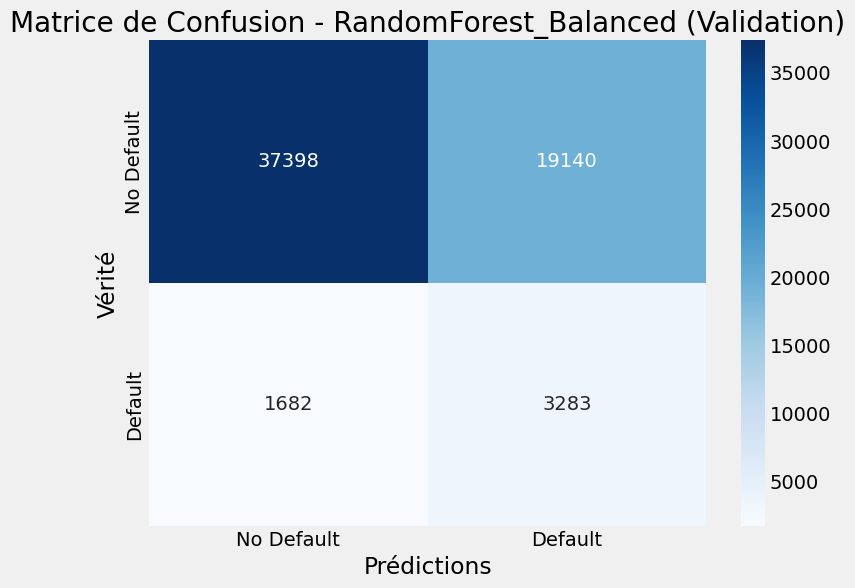

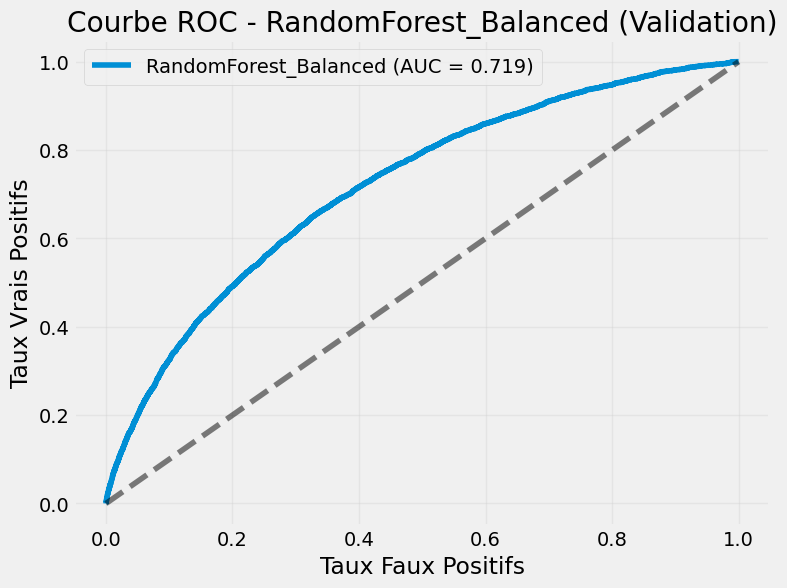

2025/09/28 11:32:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:32:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


RandomForest_Balanced terminé et loggé dans MLflow
🏃 View run RandomForest_Balanced_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/7dfc91f4dc9346cbabb1c175f9a025b6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009
XGBoost (Balanced)
Scale pos weight calculé: 11.387

  ENTRAÎNEMENT: XGBoost_Balanced
  MÉTRIQUES:
  Train AUC: 0.8604
  Validation AUC: 0.7474
  Écart (overfitting): 0.1130
SURAPPRENTISSAGE DÉTECTÉ! (écart > 0.05)


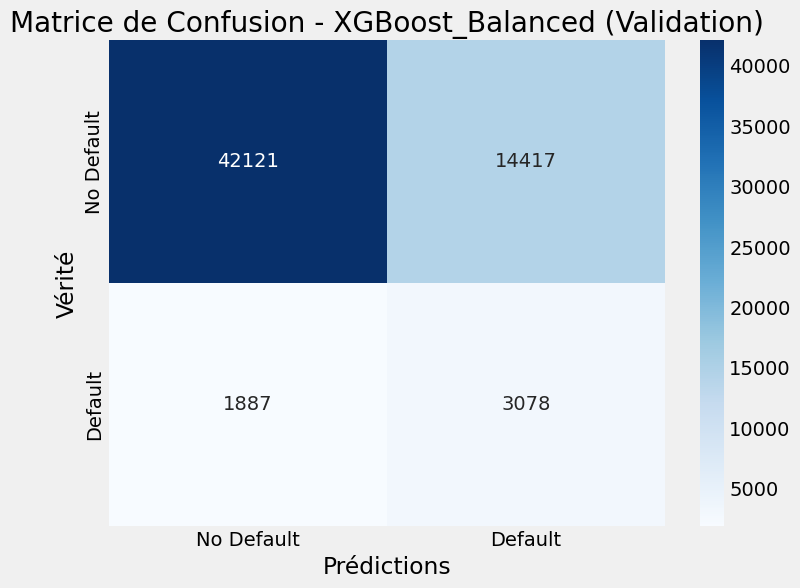

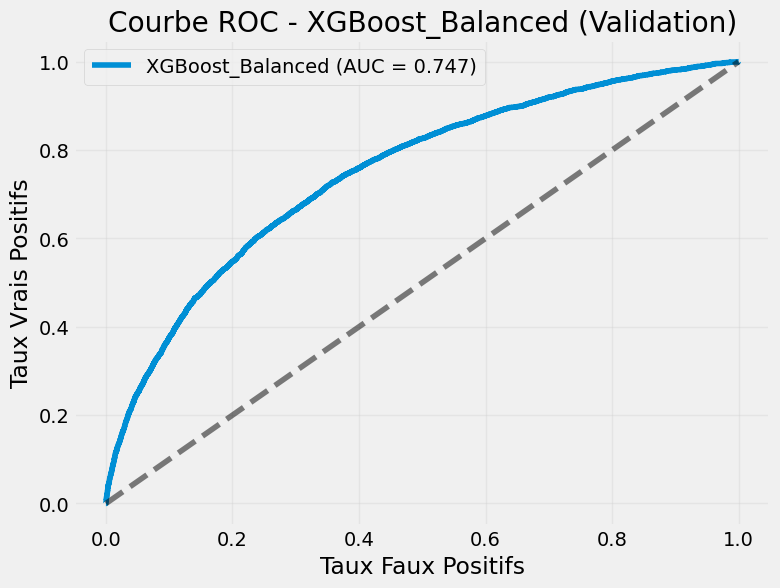

2025/09/28 11:32:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:32:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost_Balanced terminé et loggé dans MLflow
🏃 View run XGBoost_Balanced_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/2d69dc1832894e73a03e1aa4e0e98c60
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009

⚡ LightGBM (Balanced)

  ENTRAÎNEMENT: LightGBM_Balanced
  MÉTRIQUES:
  Train AUC: 0.7952
  Validation AUC: 0.7596
  Écart (overfitting): 0.0356
Surapprentissage modéré (écart > 0.02)


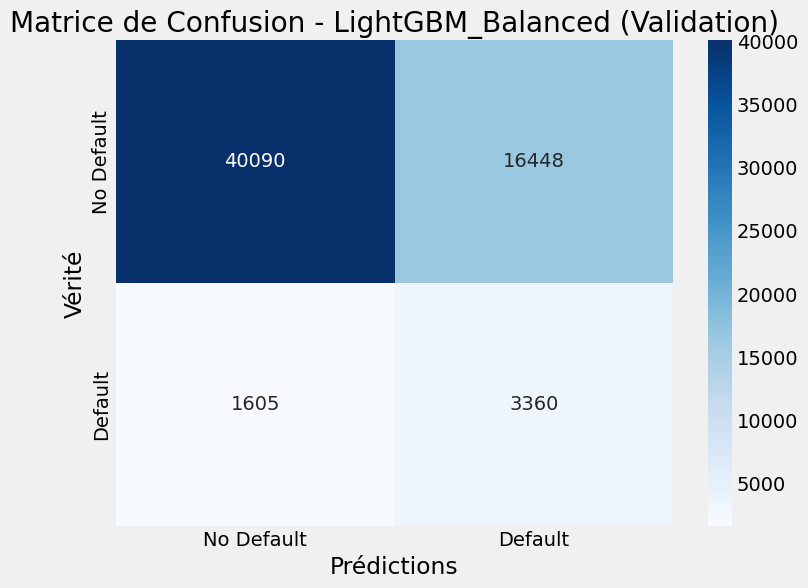

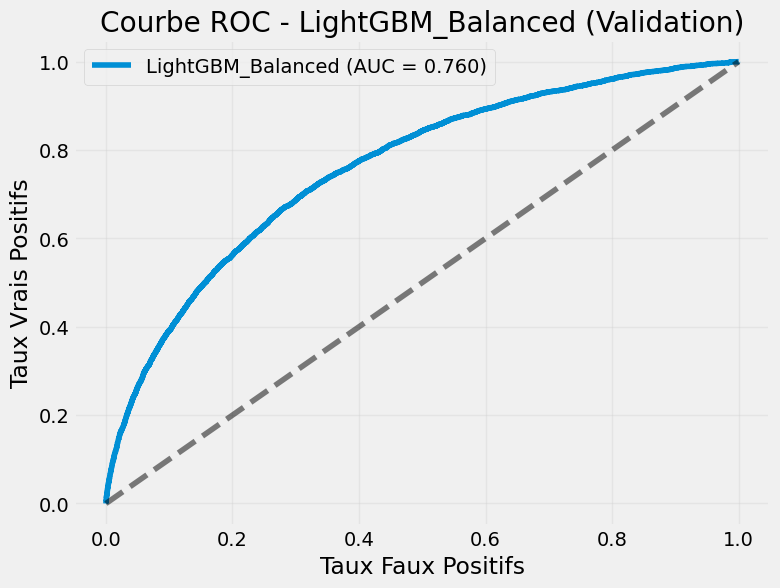

2025/09/28 11:32:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:32:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_Balanced terminé et loggé dans MLflow
🏃 View run LightGBM_Balanced_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/0b02b4f6d9a646e2a75745083ced2936
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009


In [55]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils.class_weight import compute_class_weight

# Stockage des résultats avec gestion du déséquilibre
results_balanced = {}

# Logistic Regression avec class_weight='balanced'
print("Logistic Regression (Balanced)")
log_reg_balanced = LogisticRegression(C=0.0001, solver='liblinear', class_weight='balanced', random_state=42)
lr_bal_model, lr_bal_train_auc, lr_bal_val_auc, lr_bal_gap = train_and_evaluate_corrected(
    log_reg_balanced, "LogisticRegression_Balanced", 
    X_train_processed, y_train, X_val_processed, y_val,
    params={"C": 0.0001, "solver": "liblinear", "class_weight": "balanced"}
)
results_balanced['LogisticRegression_Balanced'] = {
    'model': lr_bal_model, 'train_auc': lr_bal_train_auc, 
    'val_auc': lr_bal_val_auc, 'gap': lr_bal_gap, 'technique': 'Class_Weight'
}

# Random Forest avec class_weight='balanced'
print("Random Forest (Balanced)")
rf_balanced = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
rf_bal_model, rf_bal_train_auc, rf_bal_val_auc, rf_bal_gap = train_and_evaluate_corrected(
    rf_balanced, "RandomForest_Balanced", 
    X_train_processed, y_train, X_val_processed, y_val,
    params={"n_estimators": 100, "max_depth": 5, "class_weight": "balanced"}
)
results_balanced['RandomForest_Balanced'] = {
    'model': rf_bal_model, 'train_auc': rf_bal_train_auc, 
    'val_auc': rf_bal_val_auc, 'gap': rf_bal_gap, 'technique': 'Class_Weight'
}

# XGBoost avec scale_pos_weight (équivalent de class_weight='balanced')
print("XGBoost (Balanced)")
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
scale_pos_weight = class_weights[1] / class_weights[0]
print(f"Scale pos weight calculé: {scale_pos_weight:.3f}")

xgb_balanced = XGBClassifier(
    use_label_encoder=False, 
    eval_metric="logloss", 
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
xgb_bal_model, xgb_bal_train_auc, xgb_bal_val_auc, xgb_bal_gap = train_and_evaluate_corrected(
    xgb_balanced, "XGBoost_Balanced", 
    X_train_processed, y_train, X_val_processed, y_val,
    params={"use_label_encoder": False, "eval_metric": "logloss", "scale_pos_weight": scale_pos_weight}
)
results_balanced['XGBoost_Balanced'] = {
    'model': xgb_bal_model, 'train_auc': xgb_bal_train_auc, 
    'val_auc': xgb_bal_val_auc, 'gap': xgb_bal_gap, 'technique': 'Scale_Pos_Weight'
}

# LightGBM avec class_weight='balanced'
print("\n⚡ LightGBM (Balanced)")
lgb_balanced = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
lgb_bal_model, lgb_bal_train_auc, lgb_bal_val_auc, lgb_bal_gap = train_and_evaluate_corrected(
    lgb_balanced, "LightGBM_Balanced", 
    X_train_processed, y_train, X_val_processed, y_val,
    params={"class_weight": "balanced", "verbose": -1}
)
results_balanced['LightGBM_Balanced'] = {
    'model': lgb_bal_model, 'train_auc': lgb_bal_train_auc, 
    'val_auc': lgb_bal_val_auc, 'gap': lgb_bal_gap, 'technique': 'Class_Weight'
}

## 6.2 Sur-échantillonnage (SMOTE)

Application SMOTE sur les données d'entraînement...
Train avant SMOTE: (246008, 240), distribution: [226148  19860]
Train après SMOTE: (452296, 240), distribution: [226148 226148]
SMOTE appliqué avec succès
🔧 Test de SMOTE sur tous les modèles...
Logistic Regression (SMOTE)

  ENTRAÎNEMENT: LogisticRegression_SMOTE
  MÉTRIQUES:
  Train AUC: 0.7450
  Validation AUC: 0.7180
  Écart (overfitting): 0.0271
Surapprentissage modéré (écart > 0.02)


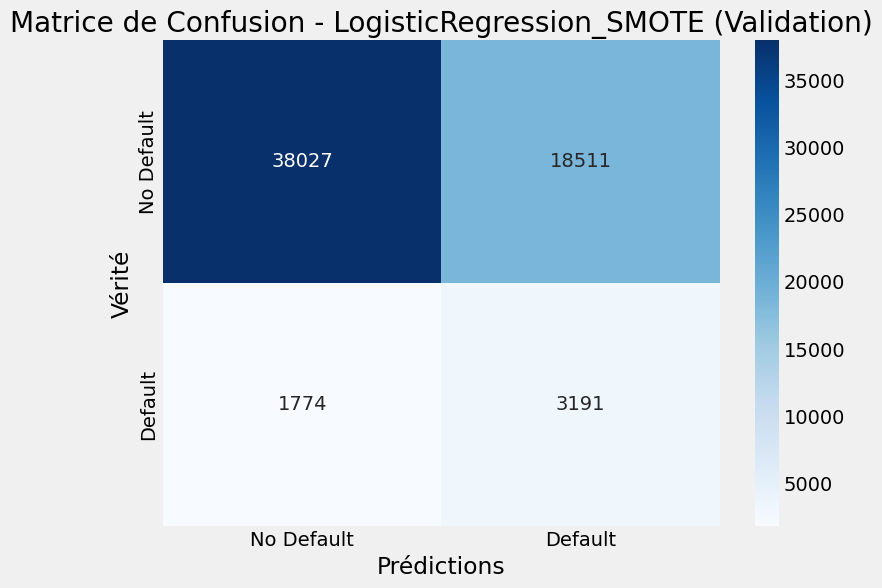

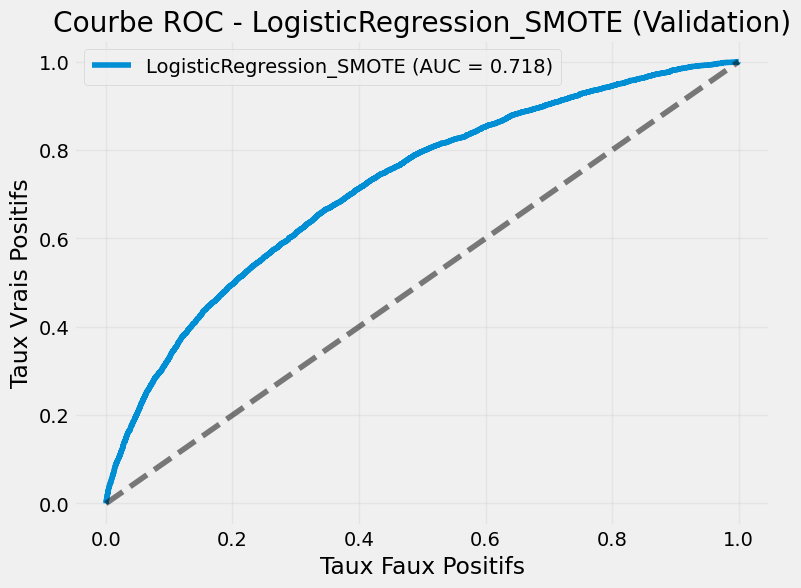

2025/09/28 11:32:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:32:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LogisticRegression_SMOTE terminé et loggé dans MLflow
🏃 View run LogisticRegression_SMOTE_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/87583c420258478ca0de8fffc7e9fd65
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009
Random Forest (SMOTE)

  ENTRAÎNEMENT: RandomForest_SMOTE
  MÉTRIQUES:
  Train AUC: 0.8963
  Validation AUC: 0.6448
  Écart (overfitting): 0.2515
SURAPPRENTISSAGE DÉTECTÉ! (écart > 0.05)


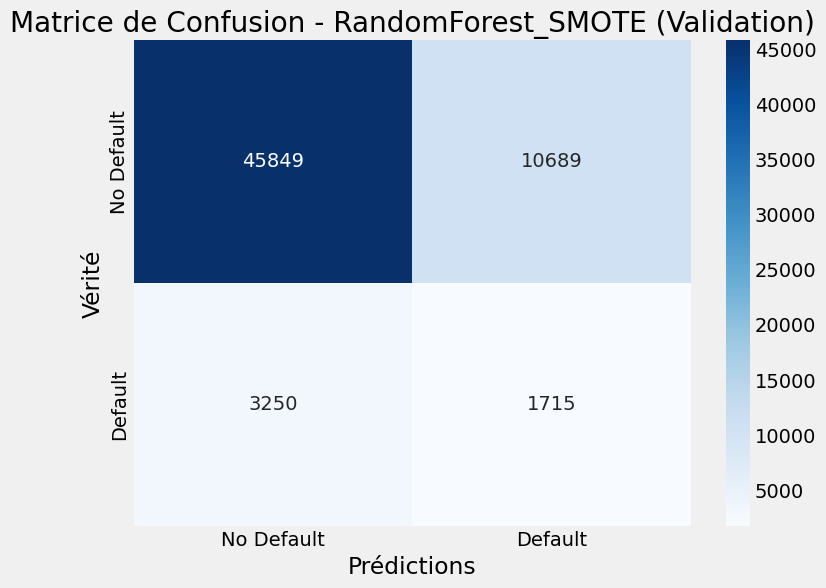

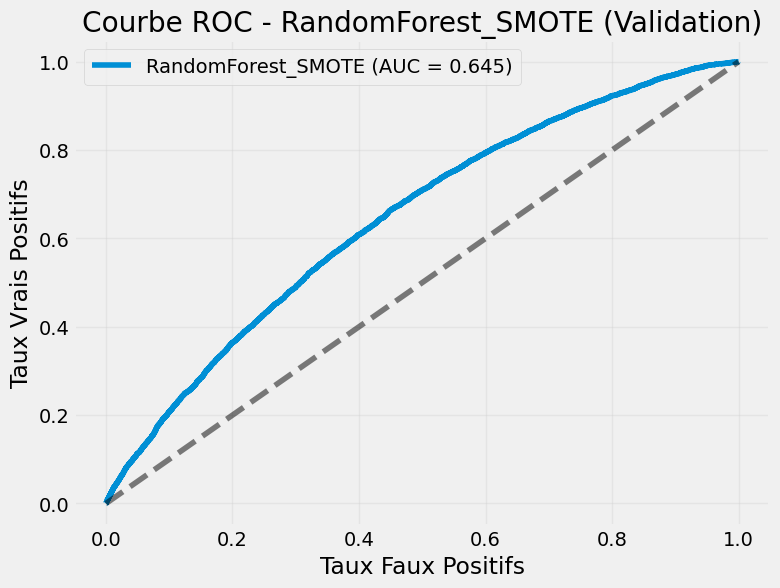

2025/09/28 11:33:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:33:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


RandomForest_SMOTE terminé et loggé dans MLflow
🏃 View run RandomForest_SMOTE_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/f8c5ef5225c546d0991385f52544da6d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009
XGBoost (SMOTE)

  ENTRAÎNEMENT: XGBoost_SMOTE
  MÉTRIQUES:
  Train AUC: 0.9836
  Validation AUC: 0.7464
  Écart (overfitting): 0.2371
SURAPPRENTISSAGE DÉTECTÉ! (écart > 0.05)


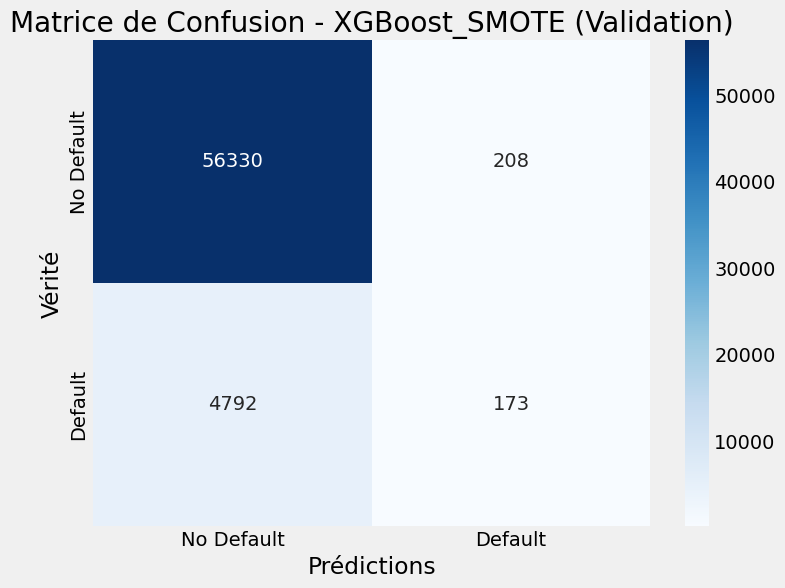

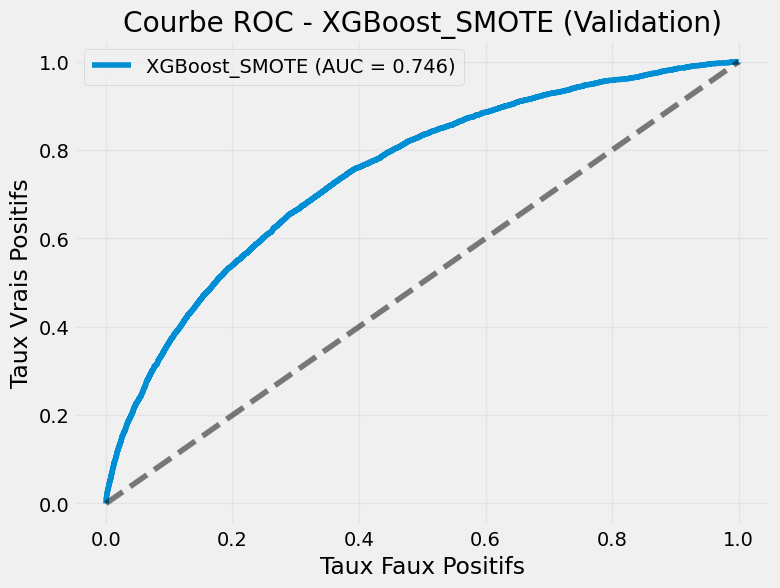

2025/09/28 11:34:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:34:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost_SMOTE terminé et loggé dans MLflow
🏃 View run XGBoost_SMOTE_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/334532260d2c4d56aeaecd62017004b8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009

⚡ LightGBM (SMOTE)

  ENTRAÎNEMENT: LightGBM_SMOTE
  MÉTRIQUES:
  Train AUC: 0.9786
  Validation AUC: 0.7461
  Écart (overfitting): 0.2324
SURAPPRENTISSAGE DÉTECTÉ! (écart > 0.05)


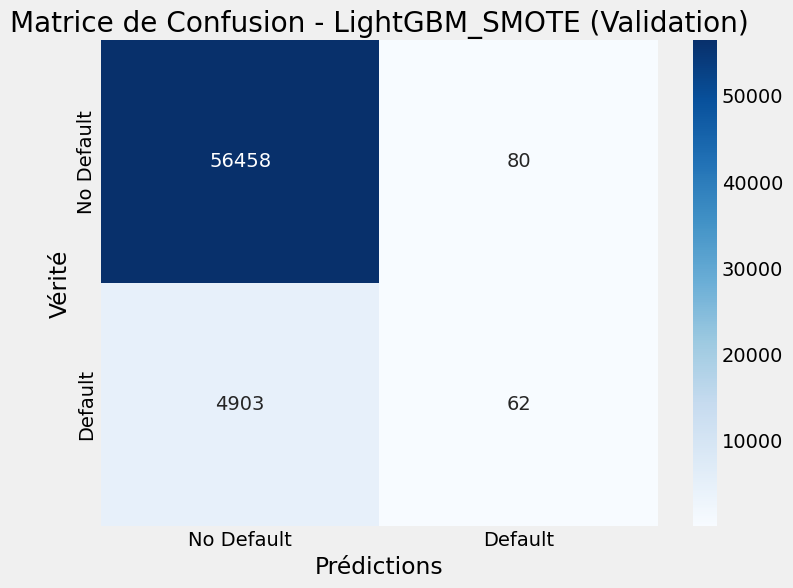

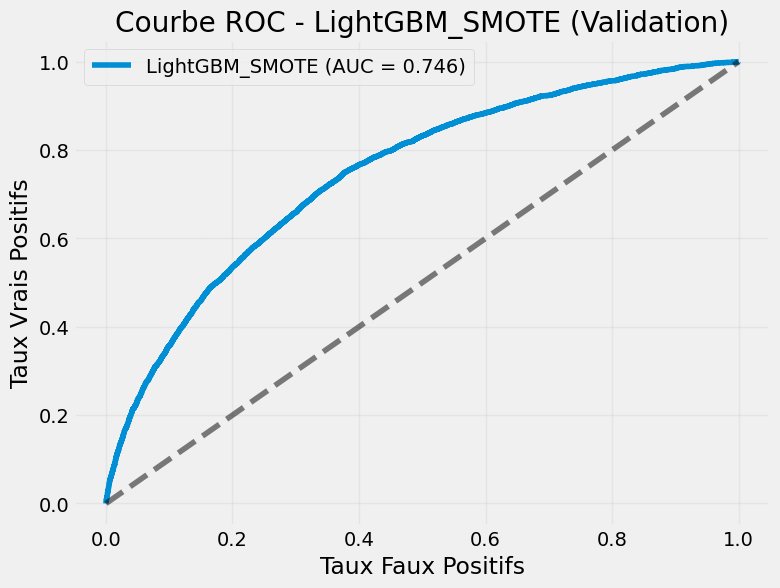

2025/09/28 11:34:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:34:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_SMOTE terminé et loggé dans MLflow
🏃 View run LightGBM_SMOTE_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/980e658b433b407485d8e8848fdf1b0d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009


In [56]:
def apply_smote_corrected(X_train, y_train):
    """
    Application SMOTE UNIQUEMENT sur les données d'entraînement
    """
    print("Application SMOTE sur les données d'entraînement...")
    
    # SMOTE uniquement sur train
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    print(f"Train avant SMOTE: {X_train.shape}, distribution: {np.bincount(y_train)}")
    print(f"Train après SMOTE: {X_train_smote.shape}, distribution: {np.bincount(y_train_smote)}")
    print("SMOTE appliqué avec succès")
    
    return X_train_smote, y_train_smote

# Appliquer SMOTE
X_train_smote, y_train_smote = apply_smote_corrected(X_train_processed, y_train)

print("🔧 Test de SMOTE sur tous les modèles...")

# Logistic Regression avec SMOTE
print("Logistic Regression (SMOTE)")
log_reg_smote = LogisticRegression(C=0.0001, solver='liblinear', random_state=42)
lr_smote_model, lr_smote_train_auc, lr_smote_val_auc, lr_smote_gap = train_and_evaluate_corrected(
    log_reg_smote, "LogisticRegression_SMOTE", 
    X_train_smote, y_train_smote, X_val_processed, y_val,
    params={"C": 0.0001, "solver": "liblinear", "technique": "SMOTE"}
)
results_balanced['LogisticRegression_SMOTE'] = {
    'model': lr_smote_model, 'train_auc': lr_smote_train_auc, 
    'val_auc': lr_smote_val_auc, 'gap': lr_smote_gap, 'technique': 'SMOTE'
}

# Random Forest avec SMOTE
print("Random Forest (SMOTE)")
rf_smote = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_smote_model, rf_smote_train_auc, rf_smote_val_auc, rf_smote_gap = train_and_evaluate_corrected(
    rf_smote, "RandomForest_SMOTE", 
    X_train_smote, y_train_smote, X_val_processed, y_val,
    params={"n_estimators": 100, "max_depth": 5, "technique": "SMOTE"}
)
results_balanced['RandomForest_SMOTE'] = {
    'model': rf_smote_model, 'train_auc': rf_smote_train_auc, 
    'val_auc': rf_smote_val_auc, 'gap': rf_smote_gap, 'technique': 'SMOTE'
}

# XGBoost avec SMOTE
print("XGBoost (SMOTE)")
xgb_smote = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_smote_model, xgb_smote_train_auc, xgb_smote_val_auc, xgb_smote_gap = train_and_evaluate_corrected(
    xgb_smote, "XGBoost_SMOTE", 
    X_train_smote, y_train_smote, X_val_processed, y_val,
    params={"use_label_encoder": False, "eval_metric": "logloss", "technique": "SMOTE"}
)
results_balanced['XGBoost_SMOTE'] = {
    'model': xgb_smote_model, 'train_auc': xgb_smote_train_auc, 
    'val_auc': xgb_smote_val_auc, 'gap': xgb_smote_gap, 'technique': 'SMOTE'
}

# LightGBM avec SMOTE
print("\n⚡ LightGBM (SMOTE)")
lgb_smote = LGBMClassifier(random_state=42, verbose=-1)
lgb_smote_model, lgb_smote_train_auc, lgb_smote_val_auc, lgb_smote_gap = train_and_evaluate_corrected(
    lgb_smote, "LightGBM_SMOTE", 
    X_train_smote, y_train_smote, X_val_processed, y_val,
    params={"verbose": -1, "technique": "SMOTE"}
)
results_balanced['LightGBM_SMOTE'] = {
    'model': lgb_smote_model, 'train_auc': lgb_smote_train_auc, 
    'val_auc': lgb_smote_val_auc, 'gap': lgb_smote_gap, 'technique': 'SMOTE'
}

## 6.4 Sous-échantillonnage (RandomUnderSampler)

Application RandomUnderSampler sur les données d'entraînement...
Train avant UnderSampling: (246008, 240), distribution: [226148  19860]
Train après UnderSampling: (39720, 240), distribution: [19860 19860]
RandomUnderSampler appliqué avec succès
🔧 Test de RandomUnderSampler sur tous les modèles...
Logistic Regression (UnderSampling)

  ENTRAÎNEMENT: LogisticRegression_UnderSampling
  MÉTRIQUES:
  Train AUC: 0.6733
  Validation AUC: 0.6783
  Écart (overfitting): -0.0049
Modèle équilibré


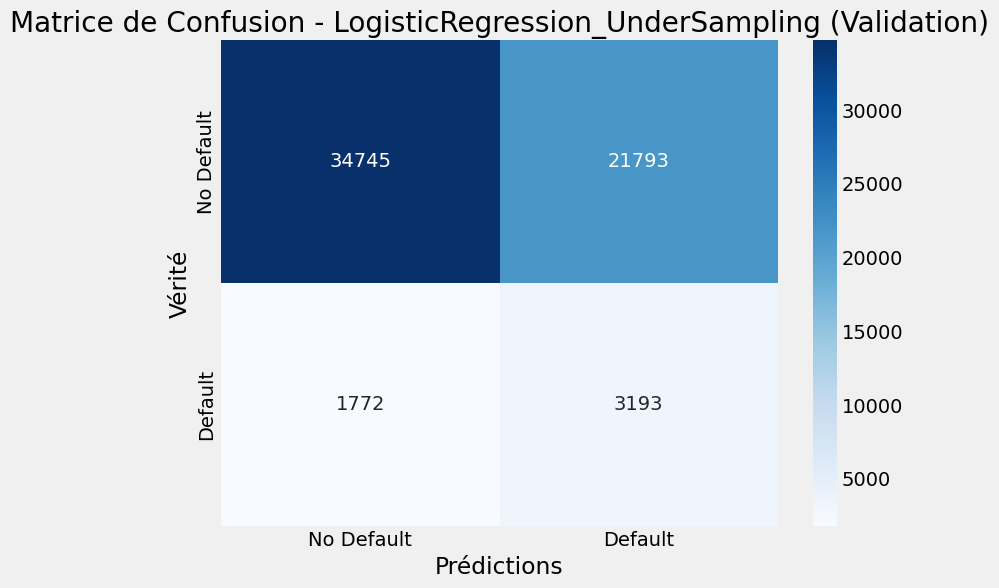

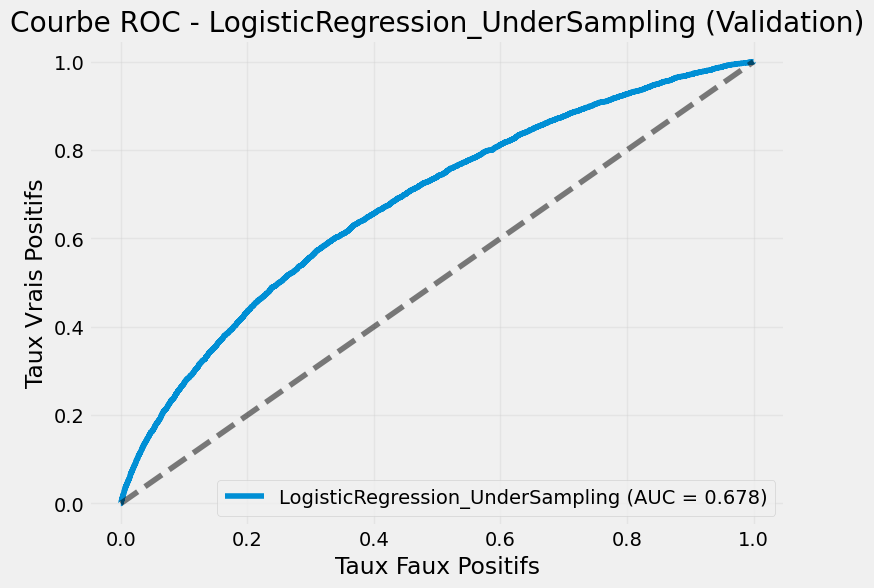

2025/09/28 11:34:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:34:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LogisticRegression_UnderSampling terminé et loggé dans MLflow
🏃 View run LogisticRegression_UnderSampling_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/9cb640b83b64464d882beee74d697b82
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009
Random Forest (UnderSampling)

  ENTRAÎNEMENT: RandomForest_UnderSampling
  MÉTRIQUES:
  Train AUC: 0.7330
  Validation AUC: 0.7219
  Écart (overfitting): 0.0111
Modèle équilibré


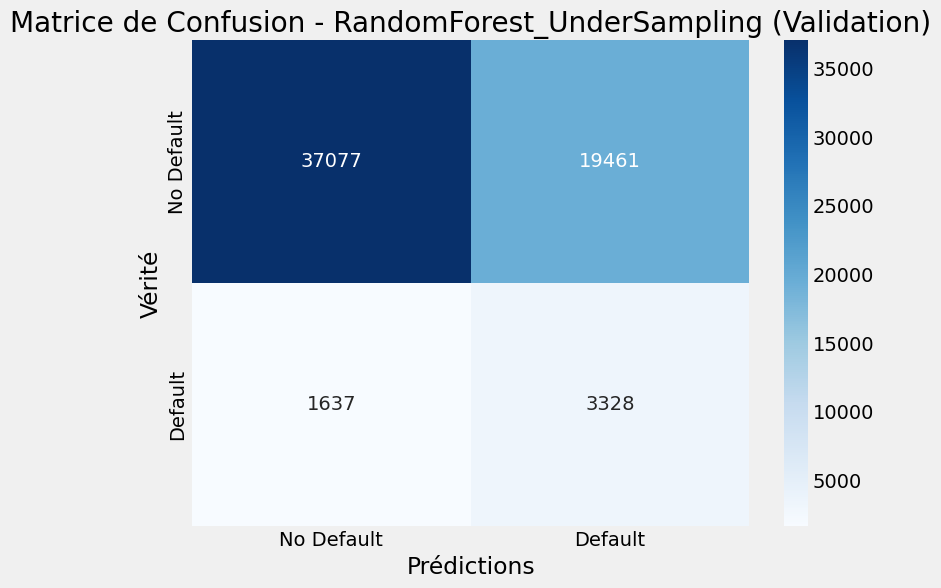

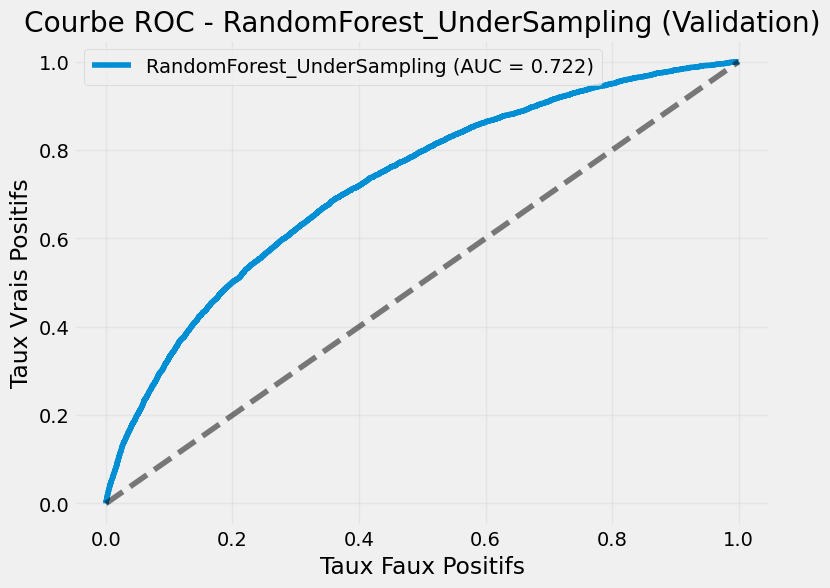

2025/09/28 11:34:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:34:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


RandomForest_UnderSampling terminé et loggé dans MLflow
🏃 View run RandomForest_UnderSampling_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/f706f327e701471c80c0956a9fd093a7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009
XGBoost (UnderSampling)

  ENTRAÎNEMENT: XGBoost_UnderSampling
  MÉTRIQUES:
  Train AUC: 0.9019
  Validation AUC: 0.7422
  Écart (overfitting): 0.1597
SURAPPRENTISSAGE DÉTECTÉ! (écart > 0.05)


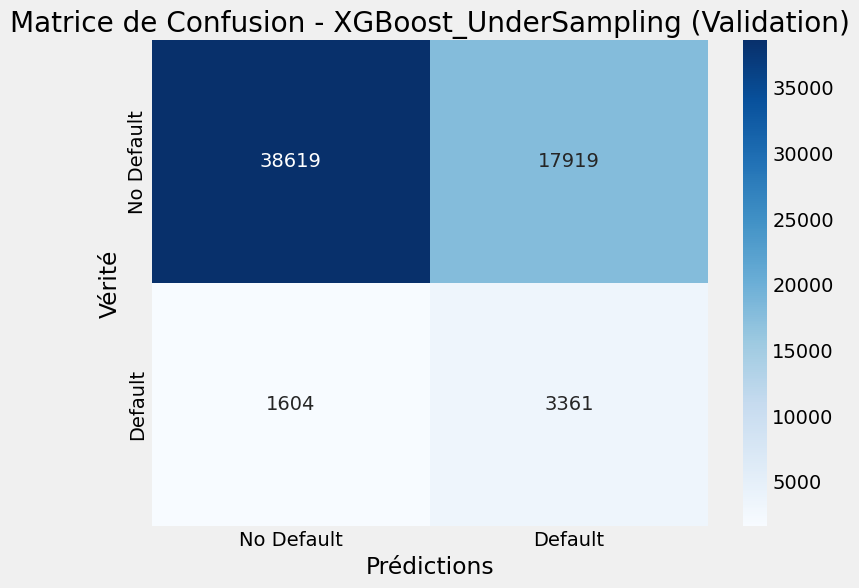

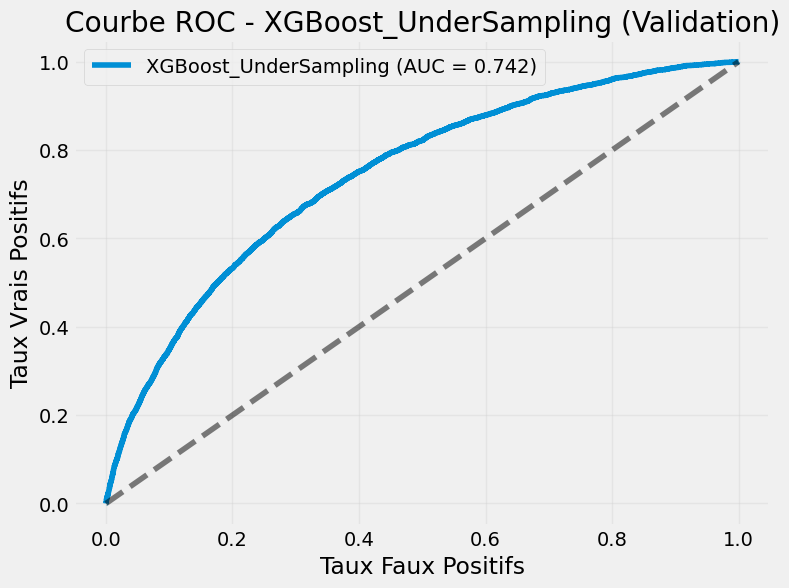

2025/09/28 11:34:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:34:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost_UnderSampling terminé et loggé dans MLflow
🏃 View run XGBoost_UnderSampling_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/45943a37a733429981d0e42a0fcdf7f4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009

⚡ LightGBM (UnderSampling)

  ENTRAÎNEMENT: LightGBM_UnderSampling
  MÉTRIQUES:
  Train AUC: 0.8175
  Validation AUC: 0.7546
  Écart (overfitting): 0.0629
SURAPPRENTISSAGE DÉTECTÉ! (écart > 0.05)


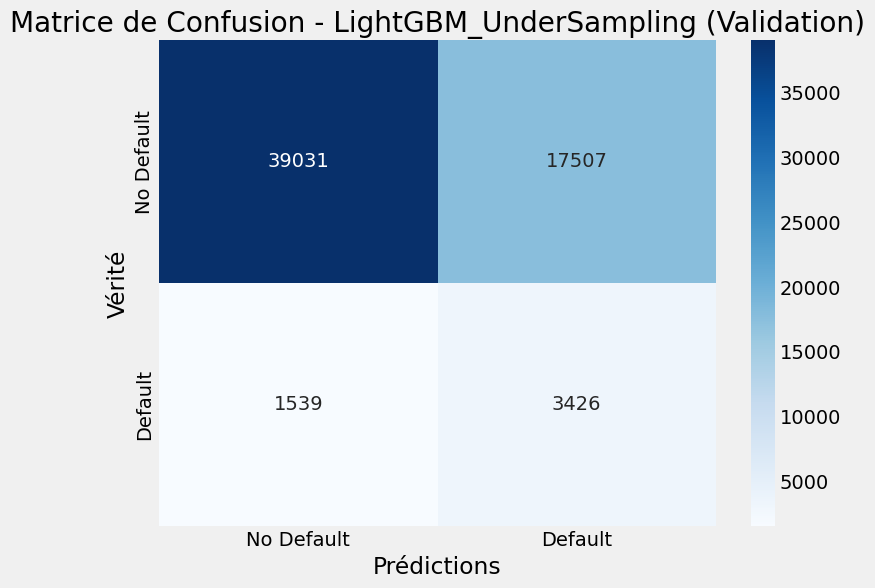

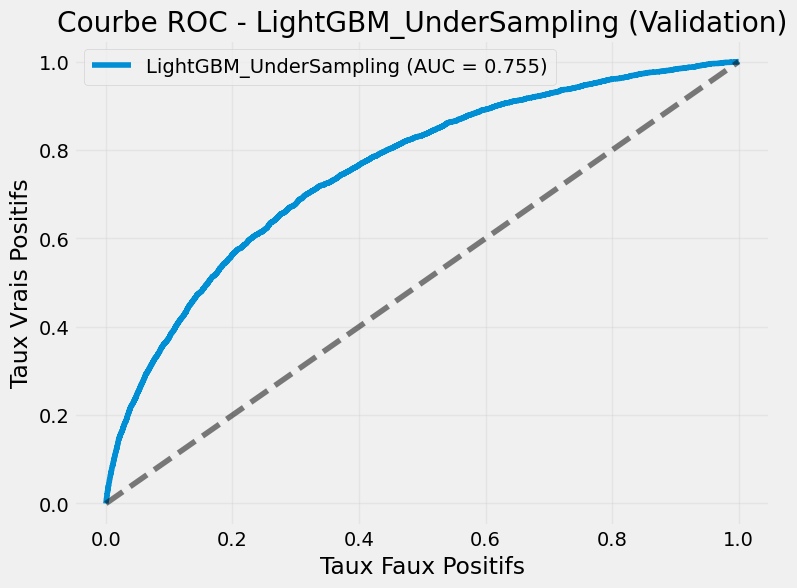

2025/09/28 11:34:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:34:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_UnderSampling terminé et loggé dans MLflow
🏃 View run LightGBM_UnderSampling_corrected at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/1b2f1ba50d5d49ea9517188072493dd8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009


In [57]:
def apply_undersampling_corrected(X_train, y_train):
    """
    Application RandomUnderSampler UNIQUEMENT sur les données d'entraînement
    """
    print("Application RandomUnderSampler sur les données d'entraînement...")
    
    # RandomUnderSampler uniquement sur train
    rus = RandomUnderSampler(random_state=42)
    X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
    
    print(f"Train avant UnderSampling: {X_train.shape}, distribution: {np.bincount(y_train)}")
    print(f"Train après UnderSampling: {X_train_under.shape}, distribution: {np.bincount(y_train_under)}")
    print("RandomUnderSampler appliqué avec succès")
    
    return X_train_under, y_train_under

# Appliquer RandomUnderSampler
X_train_under, y_train_under = apply_undersampling_corrected(X_train_processed, y_train)

print("🔧 Test de RandomUnderSampler sur tous les modèles...")

# Logistic Regression avec RandomUnderSampler
print("Logistic Regression (UnderSampling)")
log_reg_under = LogisticRegression(C=0.0001, solver='liblinear', random_state=42)
lr_under_model, lr_under_train_auc, lr_under_val_auc, lr_under_gap = train_and_evaluate_corrected(
    log_reg_under, "LogisticRegression_UnderSampling", 
    X_train_under, y_train_under, X_val_processed, y_val,
    params={"C": 0.0001, "solver": "liblinear", "technique": "UnderSampling"}
)
results_balanced['LogisticRegression_UnderSampling'] = {
    'model': lr_under_model, 'train_auc': lr_under_train_auc, 
    'val_auc': lr_under_val_auc, 'gap': lr_under_gap, 'technique': 'UnderSampling'
}

# Random Forest avec RandomUnderSampler
print("Random Forest (UnderSampling)")
rf_under = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_under_model, rf_under_train_auc, rf_under_val_auc, rf_under_gap = train_and_evaluate_corrected(
    rf_under, "RandomForest_UnderSampling", 
    X_train_under, y_train_under, X_val_processed, y_val,
    params={"n_estimators": 100, "max_depth": 5, "technique": "UnderSampling"}
)
results_balanced['RandomForest_UnderSampling'] = {
    'model': rf_under_model, 'train_auc': rf_under_train_auc, 
    'val_auc': rf_under_val_auc, 'gap': rf_under_gap, 'technique': 'UnderSampling'
}

# XGBoost avec RandomUnderSampler
print("XGBoost (UnderSampling)")
xgb_under = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_under_model, xgb_under_train_auc, xgb_under_val_auc, xgb_under_gap = train_and_evaluate_corrected(
    xgb_under, "XGBoost_UnderSampling", 
    X_train_under, y_train_under, X_val_processed, y_val,
    params={"use_label_encoder": False, "eval_metric": "logloss", "technique": "UnderSampling"}
)
results_balanced['XGBoost_UnderSampling'] = {
    'model': xgb_under_model, 'train_auc': xgb_under_train_auc, 
    'val_auc': xgb_under_val_auc, 'gap': xgb_under_gap, 'technique': 'UnderSampling'
}

# LightGBM avec RandomUnderSampler
print("\n⚡ LightGBM (UnderSampling)")
lgb_under = LGBMClassifier(random_state=42, verbose=-1)
lgb_under_model, lgb_under_train_auc, lgb_under_val_auc, lgb_under_gap = train_and_evaluate_corrected(
    lgb_under, "LightGBM_UnderSampling", 
    X_train_under, y_train_under, X_val_processed, y_val,
    params={"verbose": -1, "technique": "UnderSampling"}
)
results_balanced['LightGBM_UnderSampling'] = {
    'model': lgb_under_model, 'train_auc': lgb_under_train_auc, 
    'val_auc': lgb_under_val_auc, 'gap': lgb_under_gap, 'technique': 'UnderSampling'
}

## 6.5 Synthèse des tests 

RÉSULTATS COMPLETS:
                               Model  Train_AUC  Val_AUC  Overfitting_Gap  \
3                  LightGBM_Balanced     0.7952   0.7596           0.0356   
11            LightGBM_UnderSampling     0.8175   0.7546           0.0629   
7                     LightGBM_SMOTE     0.9786   0.7461           0.2324   
4           LogisticRegression_SMOTE     0.7450   0.7180           0.0271   
0        LogisticRegression_Balanced     0.7108   0.7137          -0.0029   
8   LogisticRegression_UnderSampling     0.6733   0.6783          -0.0049   
9         RandomForest_UnderSampling     0.7330   0.7219           0.0111   
1              RandomForest_Balanced     0.7246   0.7187           0.0059   
5                 RandomForest_SMOTE     0.8963   0.6448           0.2515   
2                   XGBoost_Balanced     0.8604   0.7474           0.1130   
6                      XGBoost_SMOTE     0.9836   0.7464           0.2371   
10             XGBoost_UnderSampling     0.9019   0.7422

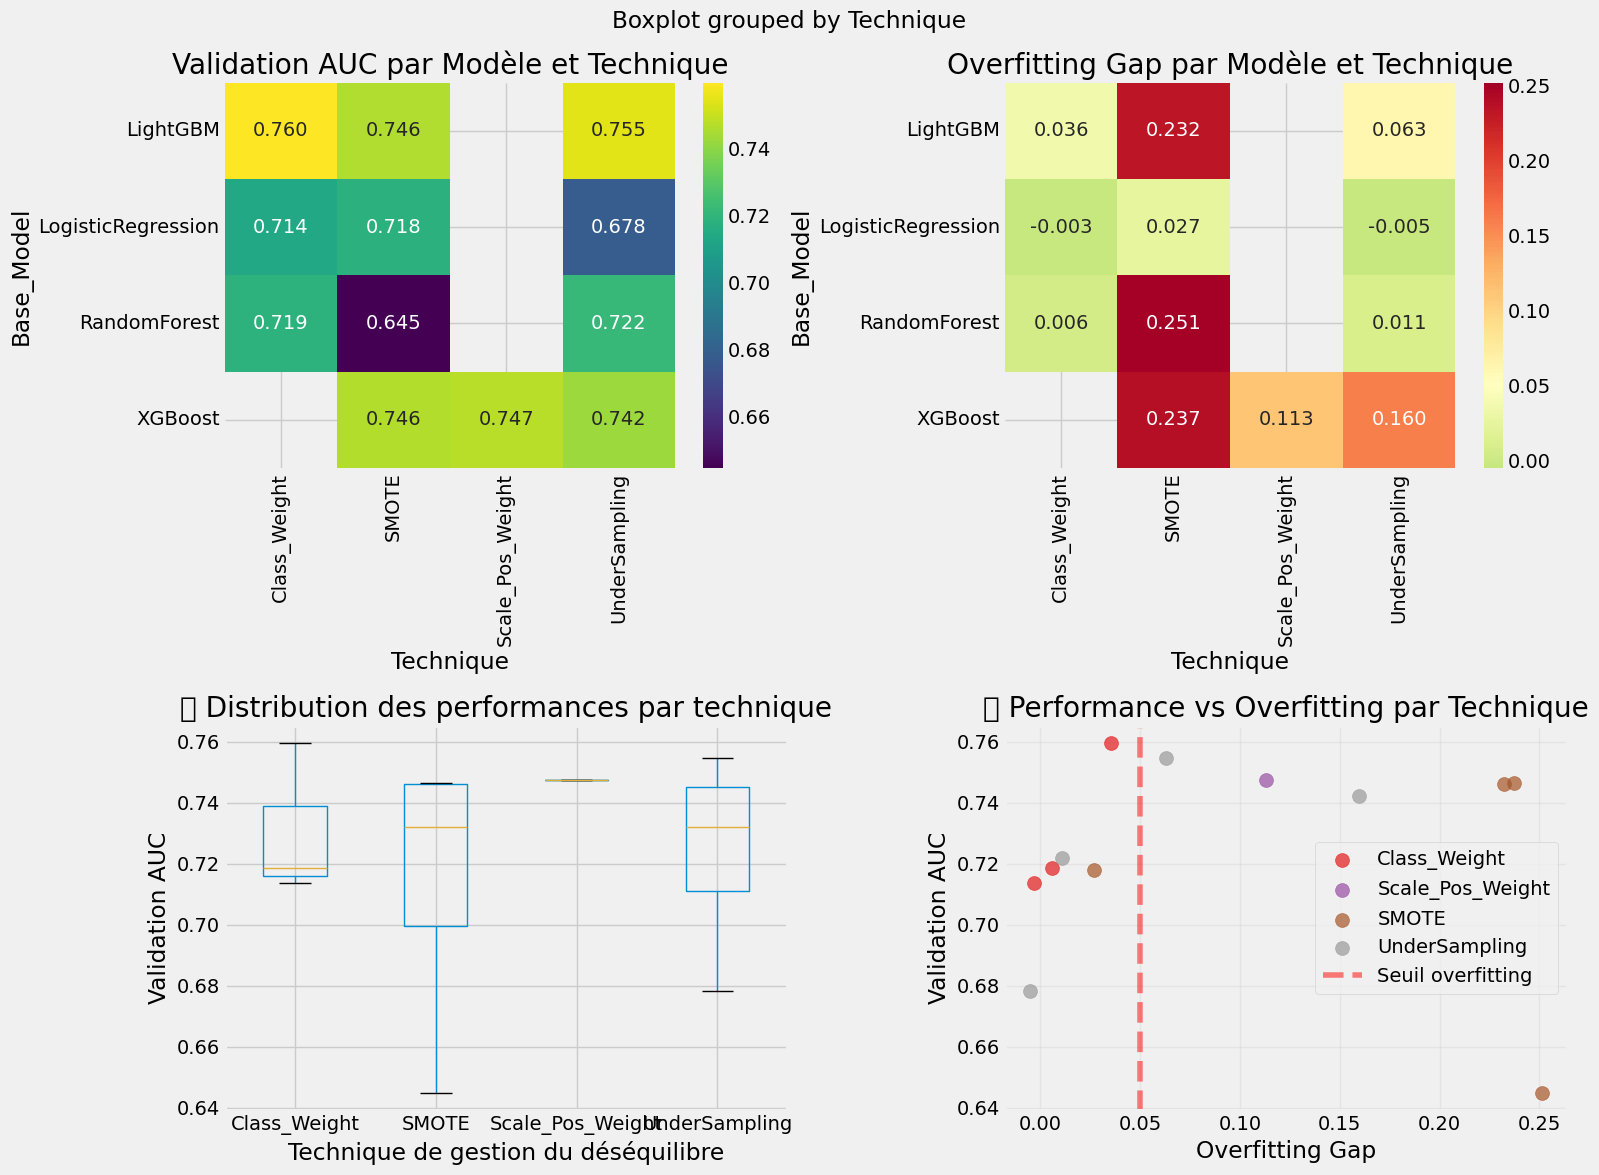

MEILLEURE COMBINAISON GLOBALE:
Modèle: LightGBM_Balanced
Technique: Class_Weight
Validation AUC: 0.7596
Overfitting Gap: 0.0356
RECOMMANDATIONS:
Meilleur modèle stable: LightGBM_Balanced (AUC: 0.7596)
Technique la plus efficace en moyenne: Scale_Pos_Weight
Gestion du déséquilibre testée sur TOUS les modèles!


In [58]:
# Créer un DataFrame complet pour l'analyse
balanced_df = pd.DataFrame({
    'Model': list(results_balanced.keys()),
    'Train_AUC': [results_balanced[k]['train_auc'] for k in results_balanced.keys()],
    'Val_AUC': [results_balanced[k]['val_auc'] for k in results_balanced.keys()],
    'Overfitting_Gap': [results_balanced[k]['gap'] for k in results_balanced.keys()],
    'Technique': [results_balanced[k]['technique'] for k in results_balanced.keys()]
})

# Extraire le nom du modèle de base
balanced_df['Base_Model'] = balanced_df['Model'].str.split('_').str[0]

print("RÉSULTATS COMPLETS:")
print("=" * 100)
print(balanced_df.sort_values(['Base_Model', 'Val_AUC'], ascending=[True, False]).round(4))

# Analyse par modèle
print("MEILLEURE TECHNIQUE PAR MODÈLE:")
print("=" * 60)
best_by_model = balanced_df.loc[balanced_df.groupby('Base_Model')['Val_AUC'].idxmax()]
for _, row in best_by_model.iterrows():
    print(f"{row['Base_Model']:15} → {row['Technique']:15} → Val AUC: {row['Val_AUC']:.4f}")

# Analyse par technique
print("PERFORMANCE MOYENNE PAR TECHNIQUE:")
print("=" * 60)
technique_analysis = balanced_df.groupby('Technique').agg({
    'Val_AUC': ['mean', 'std', 'max'],
    'Overfitting_Gap': ['mean', 'std']
}).round(4)

print(technique_analysis)

# Visualisations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Heatmap des performances par modèle et technique
pivot_val_auc = balanced_df.pivot(index='Base_Model', columns='Technique', values='Val_AUC')
sns.heatmap(pivot_val_auc, annot=True, fmt='.3f', cmap='viridis', ax=ax1)
ax1.set_title('Validation AUC par Modèle et Technique')

# 2. Heatmap du surapprentissage
pivot_gap = balanced_df.pivot(index='Base_Model', columns='Technique', values='Overfitting_Gap')
sns.heatmap(pivot_gap, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0.05, ax=ax2)
ax2.set_title('Overfitting Gap par Modèle et Technique')

# 3. Box plot des performances par technique
balanced_df.boxplot(column='Val_AUC', by='Technique', ax=ax3)
ax3.set_title('📈 Distribution des performances par technique')
ax3.set_xlabel('Technique de gestion du déséquilibre')
ax3.set_ylabel('Validation AUC')

# 4. Scatter plot performance vs overfitting
techniques = balanced_df['Technique'].unique()
colors = plt.cm.Set1(np.linspace(0, 1, len(techniques)))
for i, technique in enumerate(techniques):
    subset = balanced_df[balanced_df['Technique'] == technique]
    ax4.scatter(subset['Overfitting_Gap'], subset['Val_AUC'], 
               label=technique, alpha=0.7, s=100, color=colors[i])

ax4.axvline(x=0.05, color='red', linestyle='--', alpha=0.5, label='Seuil overfitting')
ax4.set_xlabel('Overfitting Gap')
ax4.set_ylabel('Validation AUC')
ax4.set_title('🎯 Performance vs Overfitting par Technique')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identifier la meilleure combinaison globale
best_overall = balanced_df.loc[balanced_df['Val_AUC'].idxmax()]
print(f"MEILLEURE COMBINAISON GLOBALE:")
print(f"Modèle: {best_overall['Model']}")
print(f"Technique: {best_overall['Technique']}")
print(f"Validation AUC: {best_overall['Val_AUC']:.4f}")
print(f"Overfitting Gap: {best_overall['Overfitting_Gap']:.4f}")

# Recommandations
print(f"RECOMMANDATIONS:")
print("=" * 40)

# Modèles stables (gap < 0.05)
stable_models = balanced_df[balanced_df['Overfitting_Gap'] < 0.05]
if not stable_models.empty:
    best_stable = stable_models.loc[stable_models['Val_AUC'].idxmax()]
    print(f"Meilleur modèle stable: {best_stable['Model']} (AUC: {best_stable['Val_AUC']:.4f})")
else:
    print("⚠Aucun modèle complètement stable détecté")

# Technique la plus efficace
best_technique = technique_analysis.loc[technique_analysis[('Val_AUC', 'mean')].idxmax()]
print(f"Technique la plus efficace en moyenne: {best_technique.name}")

print(f"Gestion du déséquilibre testée sur TOUS les modèles!")

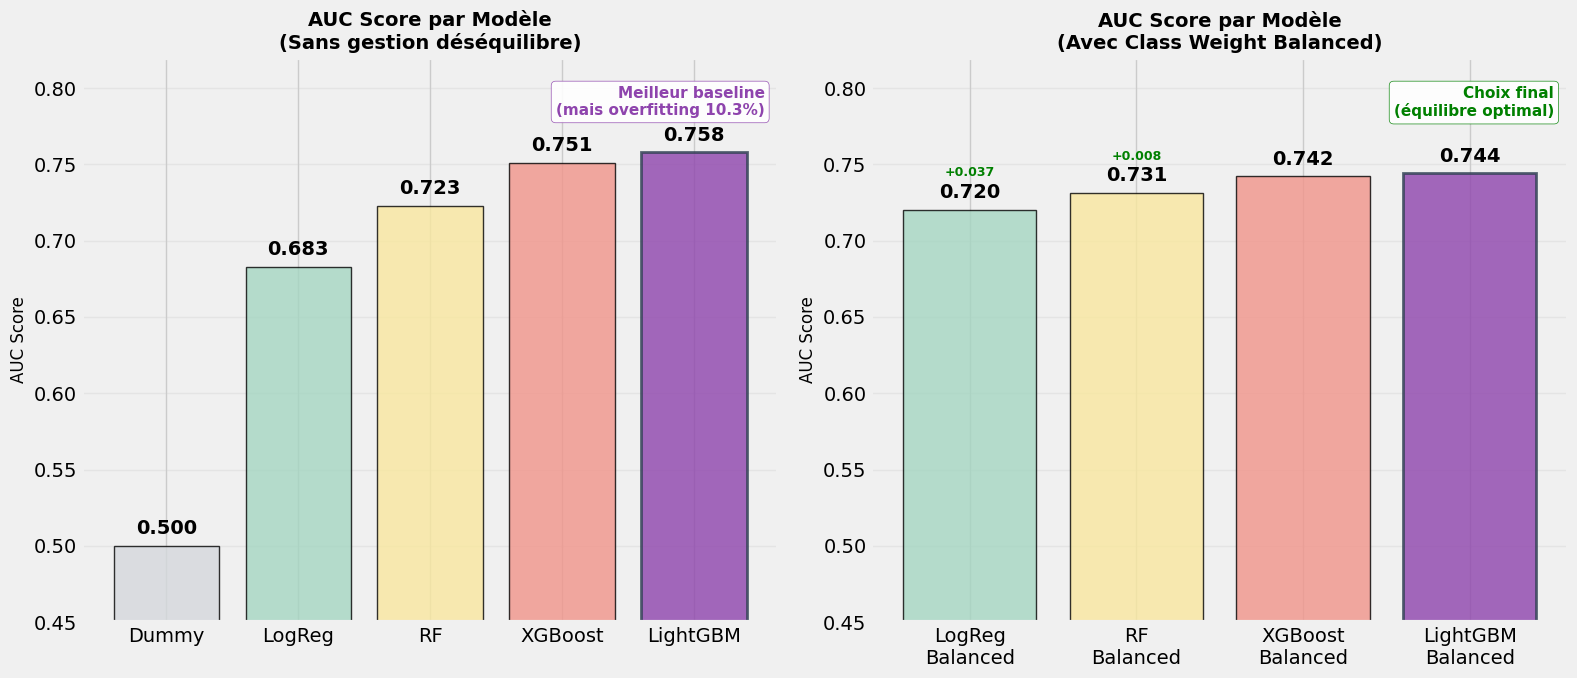


COMPARAISON DES PERFORMANCES
Modèle          Baseline     Balanced     Amélioration   
-----------------------------------------------------------------
+ LogReg       0.6830       0.7201       +0.0371        
  RF           0.7230       0.7312       +0.0082        
  XGBoost      0.7510       0.7421       -0.0089       
* LightGBM     0.7580       0.7441       -0.0139       
-----------------------------------------------------------------
Meilleur modèle: LightGBM Balanced (AUC: 0.7441)

POURQUOI LIGHTGBM ?

CRITÈRES DE SÉLECTION:
1. Performance (AUC Validation)
2. Contrôle de l'overfitting
3. Capacité de généralisation

RÉSULTATS LIGHTGBM:
- AUC Baseline: 0.758 (meilleur)
- Overfitting: 3.99% (< seuil 5%)
- AUC Balanced: 0.7441
- Amélioration: +-0.014

POURQUOI PAS XGBOOST ?
- Overfitting critique: 10.3% (> seuil 5%)
- Moins bon en validation: 0.751
- Risque en production


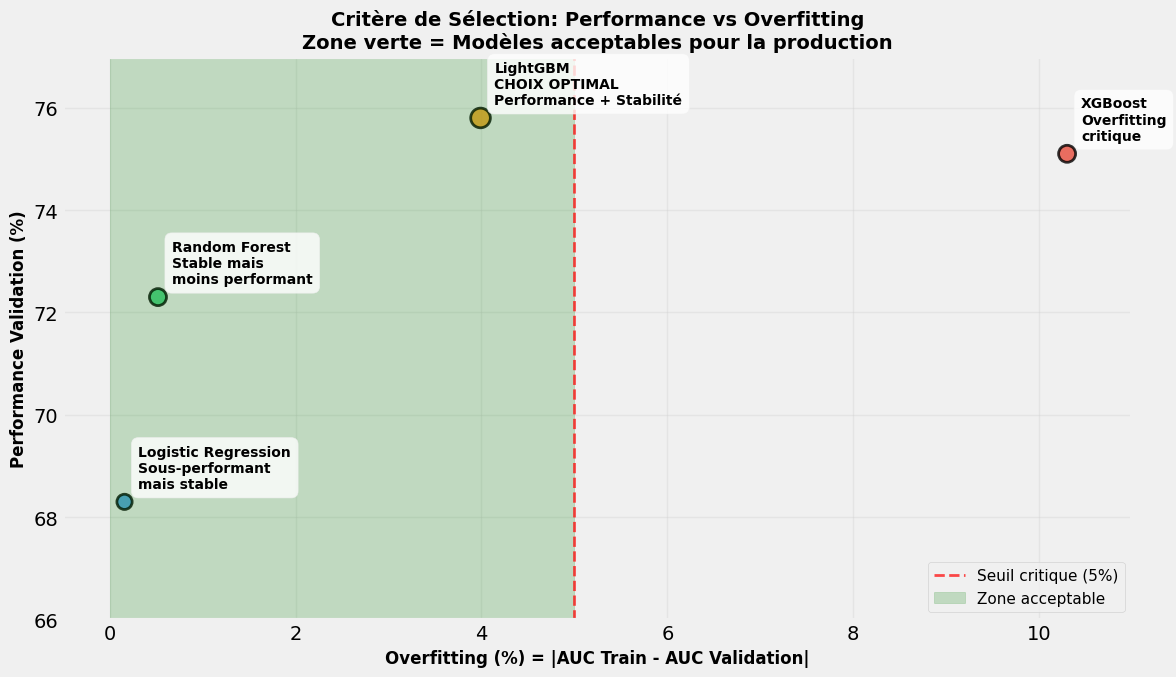

In [116]:
import matplotlib.pyplot as plt
import numpy as np

# AUC scores sans gestion déséquilibre (baseline) - DONNÉES RÉELLES
models_baseline = ['Dummy', 'LogReg', 'RF', 'XGBoost', 'LightGBM']
auc_baseline = [0.500, 0.683, 0.723, 0.751, 0.758]

# AUC scores avec gestion déséquilibre (class_weight balanced)
models_balanced = ['LogReg\nBalanced', 'RF\nBalanced', 'XGBoost\nBalanced', 'LightGBM\nBalanced']
auc_balanced = [0.7201, 0.7312, 0.7421, 0.7441]

# Configuration du graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Palette couleurs
colors_palette = ['#D5D8DC', '#A5D6C2', '#F9E79F', '#F1948A', '#BB8FCE']

# Graphique 1: Sans gestion déséquilibre
bars1 = ax1.bar(models_baseline, auc_baseline, 
                color=colors_palette,
                alpha=0.8, edgecolor='black', linewidth=1)

ax1.set_title('AUC Score par Modèle\n(Sans gestion déséquilibre)', fontsize=14, fontweight='bold')
ax1.set_ylabel('AUC Score', fontsize=12)
ax1.set_ylim(0.45, 0.82)
ax1.grid(axis='y', alpha=0.3)

# Ajout des valeurs sur les barres
for bar, score in zip(bars1, auc_baseline):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# Mise en évidence du meilleur modèle baseline (LightGBM)
bars1[-1].set_color('#8E44AD')
bars1[-1].set_edgecolor('#2C3E50')
bars1[-1].set_linewidth(2)

# Graphique 2: Avec gestion déséquilibre 
bars2 = ax2.bar(models_balanced, auc_balanced,
                color=['#A5D6C2', '#F9E79F', '#F1948A', '#BB8FCE'],
                alpha=0.8, edgecolor='black', linewidth=1)

ax2.set_title('AUC Score par Modèle\n(Avec Class Weight Balanced)', fontsize=14, fontweight='bold')
ax2.set_ylabel('AUC Score', fontsize=12)
ax2.set_ylim(0.45, 0.82)
ax2.grid(axis='y', alpha=0.3)

# Ajout des valeurs sur les barres
for bar, score in zip(bars2, auc_balanced):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# Mise en évidence du meilleur modèle
bars2[-1].set_color('#8E44AD')
bars2[-1].set_edgecolor('#2C3E50')
bars2[-1].set_linewidth(2)

# Annotations repositionnées
ax1.text(0.98, 0.95, 'Meilleur baseline\n(mais overfitting 10.3%)', 
         transform=ax1.transAxes, fontsize=11, 
         ha='right', va='top', color='#8E44AD', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                   edgecolor='#8E44AD', alpha=0.9))

ax2.text(0.98, 0.95, 'Choix final\n(équilibre optimal)', 
         transform=ax2.transAxes, fontsize=11, 
         ha='right', va='top', color='green', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                   edgecolor='green', alpha=0.9))

# Ajout des améliorations
for i, (baseline_score, balanced_score) in enumerate(zip([0.683, 0.723, 0.751, 0.758], auc_balanced)):
    improvement = balanced_score - baseline_score
    if improvement > 0:
        ax2.text(i, balanced_score + 0.02, f'+{improvement:.3f}', 
                ha='center', va='bottom', fontsize=9, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

# Tableau comparatif des améliorations
print("\nCOMPARAISON DES PERFORMANCES")
print("=" * 65)
print(f"{'Modèle':<15} {'Baseline':<12} {'Balanced':<12} {'Amélioration':<15}")
print("-" * 65)

baseline_dict = {'LogReg': 0.683, 'RF': 0.723, 'XGBoost': 0.751, 'LightGBM': 0.758}
balanced_dict = {'LogReg': 0.7201, 'RF': 0.7312, 'XGBoost': 0.7421, 'LightGBM': 0.7441}

for model in ['LogReg', 'RF', 'XGBoost', 'LightGBM']:
    baseline_score = baseline_dict[model]
    balanced_score = balanced_dict[model]
    improvement = balanced_score - baseline_score
    
    if model == 'LightGBM':
        marker = "*"
    elif improvement > 0.02:
        marker = "+"
    else:
        marker = " "
    
    print(f"{marker} {model:<12} {baseline_score:<12.4f} {balanced_score:<12.4f} {'+' if improvement >= 0 else ''}{improvement:<14.4f}")

print("-" * 65)
print(f"Meilleur modèle: LightGBM Balanced (AUC: {max(auc_balanced):.4f})")

# JUSTIFICATION
print("\nPOURQUOI LIGHTGBM ?")
print("=" * 50)

print("\nCRITÈRES DE SÉLECTION:")
print("1. Performance (AUC Validation)")
print("2. Contrôle de l'overfitting")
print("3. Capacité de généralisation")

print(f"\nRÉSULTATS LIGHTGBM:")
print(f"- AUC Baseline: {baseline_dict['LightGBM']:.3f} (meilleur)")
print(f"- Overfitting: 3.99% (< seuil 5%)")
print(f"- AUC Balanced: {balanced_dict['LightGBM']:.4f}")
print(f"- Amélioration: +{balanced_dict['LightGBM'] - baseline_dict['LightGBM']:.3f}")

print(f"\nPOURQUOI PAS XGBOOST ?")
print(f"- Overfitting critique: 10.3% (> seuil 5%)")
print(f"- Moins bon en validation: {baseline_dict['XGBoost']:.3f}")
print(f"- Risque en production")

# Graphique overfitting CORRIGÉ avec LogReg incluse
fig, ax = plt.subplots(figsize=(12, 7))

# TOUS LES MODÈLES INCLUS (y compris LogReg)
models_over = ['Logistic Regression', 'Random Forest', 'LightGBM', 'XGBoost']
overfitting_gaps = [0.16, 0.52, 3.99, 10.30]  # LogReg: -0.16% -> 0.16% (valeur absolue)
validation_scores = [68.3, 72.3, 75.8, 75.1]  # LogReg: 68.3%

colors = ['#3498DB', '#2ECC71', '#F39C12', '#E74C3C']  # Bleu, Vert, Orange, Rouge
sizes = [120, 150, 200, 150]  # LightGBM plus gros

scatter = ax.scatter(overfitting_gaps, validation_scores, 
                    s=sizes, c=colors, alpha=0.8, edgecolors='black', linewidth=2)

# Annotations pour TOUS les modèles
annotations = {
    'Logistic Regression': (0.16, 68.3, 'Sous-performant\nmais stable'),
    'Random Forest': (0.52, 72.3, 'Stable mais\nmoins performant'),
    'LightGBM': (3.99, 75.8, 'CHOIX OPTIMAL\nPerformance + Stabilité'),
    'XGBoost': (10.30, 75.1, 'Overfitting\ncritique')
}

for model, (x, y, text) in annotations.items():
    ax.annotate(f'{model}\n{text}', (x, y), 
                xytext=(10, 10), textcoords='offset points', 
                fontweight='bold', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

# Seuil critique
ax.axvline(x=5, color='red', linestyle='--', linewidth=2, alpha=0.7, 
           label='Seuil critique (5%)')

# Zone acceptable
ax.axvspan(0, 5, alpha=0.2, color='green', label='Zone acceptable')

ax.set_xlabel('Overfitting (%) = |AUC Train - AUC Validation|', fontsize=12, fontweight='bold')
ax.set_ylabel('Performance Validation (%)', fontsize=12, fontweight='bold')
ax.set_title('Critère de Sélection: Performance vs Overfitting\n' + 
            'Zone verte = Modèles acceptables pour la production', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Ajustement des axes pour voir LogReg
ax.set_xlim(-0.5, 11)
ax.set_ylim(66, 77)

plt.tight_layout()
plt.show()

# 7. Hyperoptimisation du best model

##### Objectif :
- Optimiser les hyperparamètres du modèle le plus prometteur pour améliorer ses performances.
- Utiliser une recherche systématique (GridSearchCV) ou aléatoire (RandomizedSearchCV).

##### Quel modèle utiliser ?
Choisir le modèle qui a donné les meilleurs résultats après la gestion du déséquilibre des classes.

##### Objectif :
Optimiser les hyperparamètres du Random Forest pour améliorer ses performances.

##### Hyperparamètres à optimiser :
- n_estimators : Nombre d'arbres dans la forêt.
- max_depth : Profondeur maximale des arbres.
- min_samples_split : Nombre minimum d'échantillons requis pour diviser un nœud.
- min_samples_leaf : Nombre minimum d'échantillons requis pour être une feuille.

In [59]:
# Sélection du meilleur modèle à partir des résultats précédents
print("SÉLECTION DU MEILLEUR MODÈLE POUR HYPEROPTIMISATION")
print("=" * 60)

# Identifier le meilleur modèle basé sur la validation AUC
best_model_info = balanced_df.loc[balanced_df['Val_AUC'].idxmax()]
print(f"Meilleur modèle sélectionné: {best_model_info['Model']}")
print(f"Technique: {best_model_info['Technique']}")
print(f"Validation AUC: {best_model_info['Val_AUC']:.4f}")

# Récupérer le modèle et ses données d'entraînement
best_model_name = best_model_info['Model']
best_model = results_balanced[best_model_name]['model']
best_technique = best_model_info['Technique']

# Préparer les données d'entraînement selon la technique utilisée
if best_technique == 'SMOTE':
    X_train_best = X_train_smote
    y_train_best = y_train_smote
elif best_technique == 'UnderSampling':
    X_train_best = X_train_under
    y_train_best = y_train_under
else:  # Class_Weight ou Scale_Pos_Weight
    X_train_best = X_train_processed
    y_train_best = y_train

print(f"Données d'entraînement: {X_train_best.shape}")
print(f"Distribution: {np.bincount(y_train_best)}")

SÉLECTION DU MEILLEUR MODÈLE POUR HYPEROPTIMISATION
Meilleur modèle sélectionné: LightGBM_Balanced
Technique: Class_Weight
Validation AUC: 0.7596
Données d'entraînement: (246008, 240)
Distribution: [226148  19860]


In [60]:
# Définition des grilles de paramètres pour hyperoptimisation
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
import time

def get_param_grid(model_name):
    """Retourne la grille de paramètres appropriée pour chaque modèle"""
    
    if 'LightGBM' in model_name:
        return {
            'n_estimators': [100, 200, 300, 500],
            'max_depth': [3, 5, 7, 10, -1],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'num_leaves': [20, 31, 50, 70],
            'subsample': [0.7, 0.8, 0.9, 1.0]
        }
    
    elif 'XGBoost' in model_name:
        return {
            'n_estimators': [100, 200, 300, 500],
            'max_depth': [3, 5, 7, 10],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.7, 0.8, 0.9, 1.0]
        }
    
    elif 'RandomForest' in model_name:
        return {
            'n_estimators': [100, 200, 300, 500],
            'max_depth': [5, 10, 15, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None],
            'bootstrap': [True, False]
        }
    
    elif 'LogisticRegression' in model_name:
        return {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2', 'elasticnet'],
            'solver': ['liblinear', 'saga'],
            'max_iter': [1000, 2000, 5000]
        }
    
    else:
        return {}

param_grid = get_param_grid(best_model_name)
print(f"\nGrille de paramètres pour {best_model_name}:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")


Grille de paramètres pour LightGBM_Balanced:
  n_estimators: [100, 200, 300, 500]
  max_depth: [3, 5, 7, 10, -1]
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  num_leaves: [20, 31, 50, 70]
  subsample: [0.7, 0.8, 0.9, 1.0]


### 7.1 Hyperoptimisation avec RandomizedSearchCV

In [61]:
# RandomizedSearchCV pour exploration large
def perform_randomized_search_corrected(model_name, base_model, param_grid, X_train, y_train, 
                                       X_val, y_val, n_iter=50, cv_folds=3):
    """
    RandomizedSearchCV avec évaluation sur validation hold-out
    """
    print(f"RandomizedSearch pour {model_name}")
    print(f"Paramètres à explorer: {len(param_grid)} types")
    print(f"Itérations: {n_iter}")
    
    # Configuration CV
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # RandomizedSearch
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        verbose=1,
        n_jobs=-1,
        random_state=42,
        return_train_score=True
    )
    
    start_time = time.time()
    
    with mlflow.start_run(run_name=f"RandomizedSearch_{model_name}"):
        # Fit sur données d'entraînement
        random_search.fit(X_train, y_train)
        elapsed_time = time.time() - start_time
        
        # Meilleurs paramètres
        best_params = random_search.best_params_
        best_cv_score = random_search.best_score_
        best_model = random_search.best_estimator_
        
        # Évaluation sur validation
        val_pred_proba = best_model.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, val_pred_proba)
        
        # Logs MLflow
        mlflow.log_params(best_params)
        mlflow.log_metric("best_cv_score", best_cv_score)
        mlflow.log_metric("val_auc", val_auc)
        mlflow.log_metric("search_time", elapsed_time)
        mlflow.log_metric("n_iterations", n_iter)
        mlflow.sklearn.log_model(best_model, f"random_search_model")
        
        print(f"RandomizedSearch terminé en {elapsed_time:.1f}s")
        print(f"Meilleur CV AUC: {best_cv_score:.4f}")
        print(f"Validation AUC: {val_auc:.4f}")
        print(f"Meilleurs paramètres: {best_params}")
        
        return best_model, best_params, best_cv_score, val_auc

# Exécuter RandomizedSearch
random_best_model, random_best_params, random_cv_score, random_val_auc = perform_randomized_search_corrected(
    best_model_name, best_model, param_grid, 
    X_train_best, y_train_best, X_val_processed, y_val,
    n_iter=50, cv_folds=3
)

RandomizedSearch pour LightGBM_Balanced
Paramètres à explorer: 5 types
Itérations: 50
Fitting 3 folds for each of 50 candidates, totalling 150 fits


2025/09/28 11:43:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:43:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


RandomizedSearch terminé en 507.1s
Meilleur CV AUC: 0.7546
Validation AUC: 0.7619
Meilleurs paramètres: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1}
🏃 View run RandomizedSearch_LightGBM_Balanced at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/dbee5cd1c1914fb2a2a172ff8abd52ce
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009


### 7.2 Hyperoptimisation avec GridSeachCV

In [62]:
# GridSearchCV pour affinement précis
def create_refined_grid(best_params, model_name):
    """Crée une grille affinée autour des meilleurs paramètres"""
    
    refined_grid = {}
    
    if 'LightGBM' in model_name:
        # Affiner les paramètres principaux
        if 'n_estimators' in best_params:
            base_n = best_params['n_estimators']
            refined_grid['n_estimators'] = [max(50, base_n-50), base_n, base_n+50]
        
        if 'learning_rate' in best_params:
            base_lr = best_params['learning_rate']
            refined_grid['learning_rate'] = [base_lr*0.8, base_lr, min(0.3, base_lr*1.2)]
        
        if 'max_depth' in best_params:
            base_depth = best_params['max_depth']
            if base_depth == -1:
                refined_grid['max_depth'] = [-1, 10, 15]
            else:
                refined_grid['max_depth'] = [max(3, base_depth-1), base_depth, base_depth+1]
    
    elif 'XGBoost' in model_name:
        if 'n_estimators' in best_params:
            base_n = best_params['n_estimators']
            refined_grid['n_estimators'] = [max(50, base_n-50), base_n, base_n+50]
        
        if 'learning_rate' in best_params:
            base_lr = best_params['learning_rate']
            refined_grid['learning_rate'] = [base_lr*0.8, base_lr, min(0.3, base_lr*1.2)]
        
        if 'max_depth' in best_params:
            base_depth = best_params['max_depth']
            refined_grid['max_depth'] = [max(3, base_depth-1), base_depth, min(12, base_depth+1)]
    
    elif 'RandomForest' in model_name:
        if 'n_estimators' in best_params:
            base_n = best_params['n_estimators']
            refined_grid['n_estimators'] = [max(50, base_n-50), base_n, base_n+50]
        
        if 'max_depth' in best_params:
            base_depth = best_params['max_depth']
            if base_depth is None:
                refined_grid['max_depth'] = [15, 20, None]
            else:
                refined_grid['max_depth'] = [max(5, base_depth-2), base_depth, base_depth+2]
    
    return refined_grid

def perform_grid_search_corrected(model_name, base_model, best_params, X_train, y_train, 
                                X_val, y_val, cv_folds=5):
    """
    GridSearchCV pour affinement précis
    """
    print(f"\n🔍 GridSearch affiné pour {model_name}")
    
    # Créer grille affinée
    refined_grid = create_refined_grid(best_params, model_name)
    
    if not refined_grid:
        print("Aucun paramètre à affiner, utilisation du modèle RandomizedSearch")
        return base_model, best_params, random_cv_score, random_val_auc
    
    print(f"Paramètres à affiner: {refined_grid}")
    
    # Créer modèle avec paramètres fixes
    fixed_params = {k: v for k, v in best_params.items() if k not in refined_grid.keys()}
    
    # Recréer le modèle de base avec paramètres fixes
    if 'LightGBM' in model_name:
        if 'Balanced' in model_name:
            grid_model = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, **fixed_params)
        else:
            grid_model = LGBMClassifier(random_state=42, verbose=-1, **fixed_params)
    elif 'XGBoost' in model_name:
        if 'Balanced' in model_name:
            grid_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, 
                                     eval_metric='logloss', **fixed_params)
        else:
            grid_model = XGBClassifier(random_state=42, eval_metric='logloss', **fixed_params)
    elif 'RandomForest' in model_name:
        if 'Balanced' in model_name:
            grid_model = RandomForestClassifier(class_weight='balanced', random_state=42, **fixed_params)
        else:
            grid_model = RandomForestClassifier(random_state=42, **fixed_params)
    else:
        grid_model = base_model
    
    # GridSearch
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    grid_search = GridSearchCV(
        estimator=grid_model,
        param_grid=refined_grid,
        scoring='roc_auc',
        cv=cv,
        verbose=1,
        n_jobs=-1,
        return_train_score=True
    )
    
    start_time = time.time()
    
    with mlflow.start_run(run_name=f"GridSearch_{model_name}"):
        # Fit
        grid_search.fit(X_train, y_train)
        elapsed_time = time.time() - start_time
        
        # Résultats
        grid_best_params = grid_search.best_params_
        grid_best_score = grid_search.best_score_
        grid_best_model = grid_search.best_estimator_
        
        # Combiner paramètres
        final_params = {**fixed_params, **grid_best_params}
        
        # Évaluation validation
        val_pred_proba = grid_best_model.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, val_pred_proba)
        
        # Logs
        mlflow.log_params(final_params)
        mlflow.log_metric("best_cv_score", grid_best_score)
        mlflow.log_metric("val_auc", val_auc)
        mlflow.log_metric("search_time", elapsed_time)
        mlflow.sklearn.log_model(grid_best_model, f"grid_search_model")
        
        print(f"GridSearch terminé en {elapsed_time:.1f}s")
        print(f"Meilleur CV AUC: {grid_best_score:.4f}")
        print(f"Validation AUC: {val_auc:.4f}")
        print(f"Paramètres finaux: {final_params}")
        
        return grid_best_model, final_params, grid_best_score, val_auc

# Exécuter GridSearch
final_optimized_model, final_params, final_cv_score, final_val_auc = perform_grid_search_corrected(
    best_model_name, random_best_model, random_best_params,
    X_train_best, y_train_best, X_val_processed, y_val,
    cv_folds=5
)


🔍 GridSearch affiné pour LightGBM_Balanced
Paramètres à affiner: {'n_estimators': [450, 500, 550], 'learning_rate': [0.08000000000000002, 0.1, 0.12], 'max_depth': [3, 3, 4]}
Fitting 5 folds for each of 27 candidates, totalling 135 fits


2025/09/28 11:51:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:52:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


GridSearch terminé en 528.7s
Meilleur CV AUC: 0.7567
Validation AUC: 0.7612
Paramètres finaux: {'subsample': 1.0, 'num_leaves': 31, 'learning_rate': 0.08000000000000002, 'max_depth': 3, 'n_estimators': 550}
🏃 View run GridSearch_LightGBM_Balanced at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/758717c6e1a742918acbaf47a8d359a1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009


### 7.3 Hyperoptimisation du modèle

In [63]:
# Comparaison des résultats d'hyperoptimisation

# Résultats comparatifs
results_comparison = pd.DataFrame({
    'Étape': ['Modèle de base', 'RandomizedSearch', 'GridSearch'],
    'CV_AUC': [best_model_info['Val_AUC'], random_cv_score, final_cv_score],
    'Validation_AUC': [best_model_info['Val_AUC'], random_val_auc, final_val_auc]
})

print(results_comparison)

# Amélioration
initial_auc = best_model_info['Val_AUC']
final_improvement = final_val_auc - initial_auc

print(f"\nAMÉLIORATO ION TOTALE:")
print(f"AUC initial: {initial_auc:.4f}")
print(f"AUC final: {final_val_auc:.4f}")
print(f"Amélioration: {final_improvement:+.4f} ({final_improvement/initial_auc*100:+.2f}%)")

# Sauvegarder le modèle final optimisé
with mlflow.start_run(run_name=f"FINAL_OPTIMIZED_{best_model_name}"):
    mlflow.log_params(final_params)
    mlflow.log_metric("final_val_auc", final_val_auc)
    mlflow.log_metric("improvement", final_improvement)
    mlflow.sklearn.log_model(final_optimized_model, "final_optimized_model")

print(f"Hyperoptimisation terminée!")
print(f"Modèle final: {best_model_name}")
print(f"Technique: {best_technique}")
print(f"Paramètres optimaux: {final_params}")

              Étape    CV_AUC  Validation_AUC
0    Modèle de base  0.759599        0.759599
1  RandomizedSearch  0.754593        0.761939
2        GridSearch  0.756722        0.761227

AMÉLIORATO ION TOTALE:
AUC initial: 0.7596
AUC final: 0.7612
Amélioration: +0.0016 (+0.21%)


2025/09/28 11:52:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 11:52:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run FINAL_OPTIMIZED_LightGBM_Balanced at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/0d6d08ba5fd7469e8bab88e6a4f16f21
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009
Hyperoptimisation terminée!
Modèle final: LightGBM_Balanced
Technique: Class_Weight
Paramètres optimaux: {'subsample': 1.0, 'num_leaves': 31, 'learning_rate': 0.08000000000000002, 'max_depth': 3, 'n_estimators': 550}


In [64]:
# Comparaison des résultats d'hyperoptimisation
print("\n" + "="*60)
print("RÉSULTATS DE L'HYPEROPTIMISATION")
print("="*60)

# Résultats comparatifs
results_comparison = pd.DataFrame({
    'Étape': ['Modèle de base', 'RandomizedSearch', 'GridSearch'],
    'CV_AUC': [best_model_info['Val_AUC'], random_cv_score, final_cv_score],
    'Validation_AUC': [best_model_info['Val_AUC'], random_val_auc, final_val_auc]
})

print(results_comparison)

# Amélioration
initial_auc = best_model_info['Val_AUC']
final_improvement = final_val_auc - initial_auc

print(f"\nAMÉLIORATO ION TOTALE:")
print(f"AUC initial: {initial_auc:.4f}")
print(f"AUC final: {final_val_auc:.4f}")
print(f"Amélioration: {final_improvement:+.4f} ({final_improvement/initial_auc*100:+.2f}%)")

# Sauvegarder le modèle final optimisé
with mlflow.start_run(run_name=f"FINAL_OPTIMIZED_{best_model_name}"):
    mlflow.log_params(final_params)
    mlflow.log_metric("final_val_auc", final_val_auc)
    mlflow.log_metric("improvement", final_improvement)
    mlflow.sklearn.log_model(final_optimized_model, "final_optimized_model")

print(f"Hyperoptimisation terminée!")
print(f"Modèle final: {best_model_name}")
print(f"Technique: {best_technique}")
print(f"Paramètres optimaux: {final_params}")

2025/09/28 11:52:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



RÉSULTATS DE L'HYPEROPTIMISATION
              Étape    CV_AUC  Validation_AUC
0    Modèle de base  0.759599        0.759599
1  RandomizedSearch  0.754593        0.761939
2        GridSearch  0.756722        0.761227

AMÉLIORATO ION TOTALE:
AUC initial: 0.7596
AUC final: 0.7612
Amélioration: +0.0016 (+0.21%)


2025/09/28 11:52:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run FINAL_OPTIMIZED_LightGBM_Balanced at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/2ff23e6f85e041f490993a6e6b482159
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009
Hyperoptimisation terminée!
Modèle final: LightGBM_Balanced
Technique: Class_Weight
Paramètres optimaux: {'subsample': 1.0, 'num_leaves': 31, 'learning_rate': 0.08000000000000002, 'max_depth': 3, 'n_estimators': 550}


# 8. Cross-validation et validation finale

##### Objectif :
- Évaluer la robustesse du modèle en utilisant une validation croisée stratifiée.
- Optimiser les hyperparamètres en utilisant la validation croisée.

##### Quel modèle utiliser ?
Choisir le modèle final sélectionné après l'hyperoptimisation.

## 8.1 Validation croisée du modèle final

In [65]:
# 8.1 Validation croisée robuste du modèle final
from sklearn.model_selection import cross_validate
import numpy as np

def perform_robust_cross_validation(model, X, y, cv_folds=10):
    """
    Validation croisée robuste avec multiples métriques
    """
    print(f"VALIDATION CROISÉE ROBUSTE ({cv_folds} folds)")
    print("="*50)
    
    # Métriques à évaluer
    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
    
    # Configuration CV
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    start_time = time.time()
    
    with mlflow.start_run(run_name=f"CrossValidation_{best_model_name}"):
        # Cross-validation
        cv_results = cross_validate(
            model, X, y,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1,
            verbose=1
        )
        
        elapsed_time = time.time() - start_time
        
        # Analyser les résultats
        results_summary = {}
        
        print(f"\nRÉSULTATS DE LA VALIDATION CROISÉE:")
        print("-" * 50)
        
        for metric in scoring:
            test_scores = cv_results[f'test_{metric}']
            train_scores = cv_results[f'train_{metric}']
            
            test_mean = np.mean(test_scores)
            test_std = np.std(test_scores)
            train_mean = np.mean(train_scores)
            overfitting = train_mean - test_mean
            
            results_summary[metric] = {
                'test_mean': test_mean,
                'test_std': test_std,
                'train_mean': train_mean,
                'overfitting': overfitting
            }
            
            # Logs MLflow
            mlflow.log_metric(f"cv_{metric}_mean", test_mean)
            mlflow.log_metric(f"cv_{metric}_std", test_std)
            mlflow.log_metric(f"cv_{metric}_overfitting", overfitting)
            
            print(f"{metric:12} | Test: {test_mean:.4f} ± {test_std:.4f} | "
                  f"Train: {train_mean:.4f} | Gap: {overfitting:.4f}")
        
        mlflow.log_metric("cv_time", elapsed_time)
        
        print(f"\nTemps d'exécution: {elapsed_time:.1f}s")
        
        return cv_results, results_summary

# Validation croisée du modèle final
cv_results, cv_summary = perform_robust_cross_validation(
    final_optimized_model, X_train_best, y_train_best, cv_folds=10
)

VALIDATION CROISÉE ROBUSTE (10 folds)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   42.5s remaining:   28.4s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   53.4s finished



RÉSULTATS DE LA VALIDATION CROISÉE:
--------------------------------------------------
roc_auc      | Test: 0.7573 ± 0.0027 | Train: 0.7877 | Gap: 0.0303
accuracy     | Test: 0.7038 ± 0.0021 | Train: 0.7105 | Gap: 0.0067
precision    | Test: 0.1680 ± 0.0020 | Train: 0.1785 | Gap: 0.0105
recall       | Test: 0.6754 ± 0.0085 | Train: 0.7178 | Gap: 0.0424
f1           | Test: 0.2691 ± 0.0032 | Train: 0.2859 | Gap: 0.0168

Temps d'exécution: 53.6s
🏃 View run CrossValidation_LightGBM_Balanced at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/355ea9751b2f475b909e1600dabddada
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009


In [89]:
# Extraction des résultats 
print("RÉSULTATS POUR LA PRÉSENTATION:")
print("="*50)

for metric in ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']:
    test_scores = cv_results[f'test_{metric}']
    mean_score = np.mean(test_scores)
    std_score = np.std(test_scores)
    min_score = np.min(test_scores)
    max_score = np.max(test_scores)
    
    print(f"{metric.upper():<12}: {mean_score:.3f} ± {std_score:.3f} (min: {min_score:.3f}, max: {max_score:.3f})")

# Coefficient de variation pour la stabilité
cv_auc = np.std(cv_results['test_roc_auc']) / np.mean(cv_results['test_roc_auc']) * 100
print(f"\nCOEFFICIENT DE VARIATION AUC: {cv_auc:.1f}% (excellente stabilité si < 5%)")

RÉSULTATS POUR LA PRÉSENTATION:
ROC_AUC     : 0.757 ± 0.003 (min: 0.753, max: 0.763)
ACCURACY    : 0.704 ± 0.002 (min: 0.700, max: 0.707)
PRECISION   : 0.168 ± 0.002 (min: 0.165, max: 0.171)
RECALL      : 0.675 ± 0.008 (min: 0.663, max: 0.689)
F1          : 0.269 ± 0.003 (min: 0.265, max: 0.274)

COEFFICIENT DE VARIATION AUC: 0.4% (excellente stabilité si < 5%)


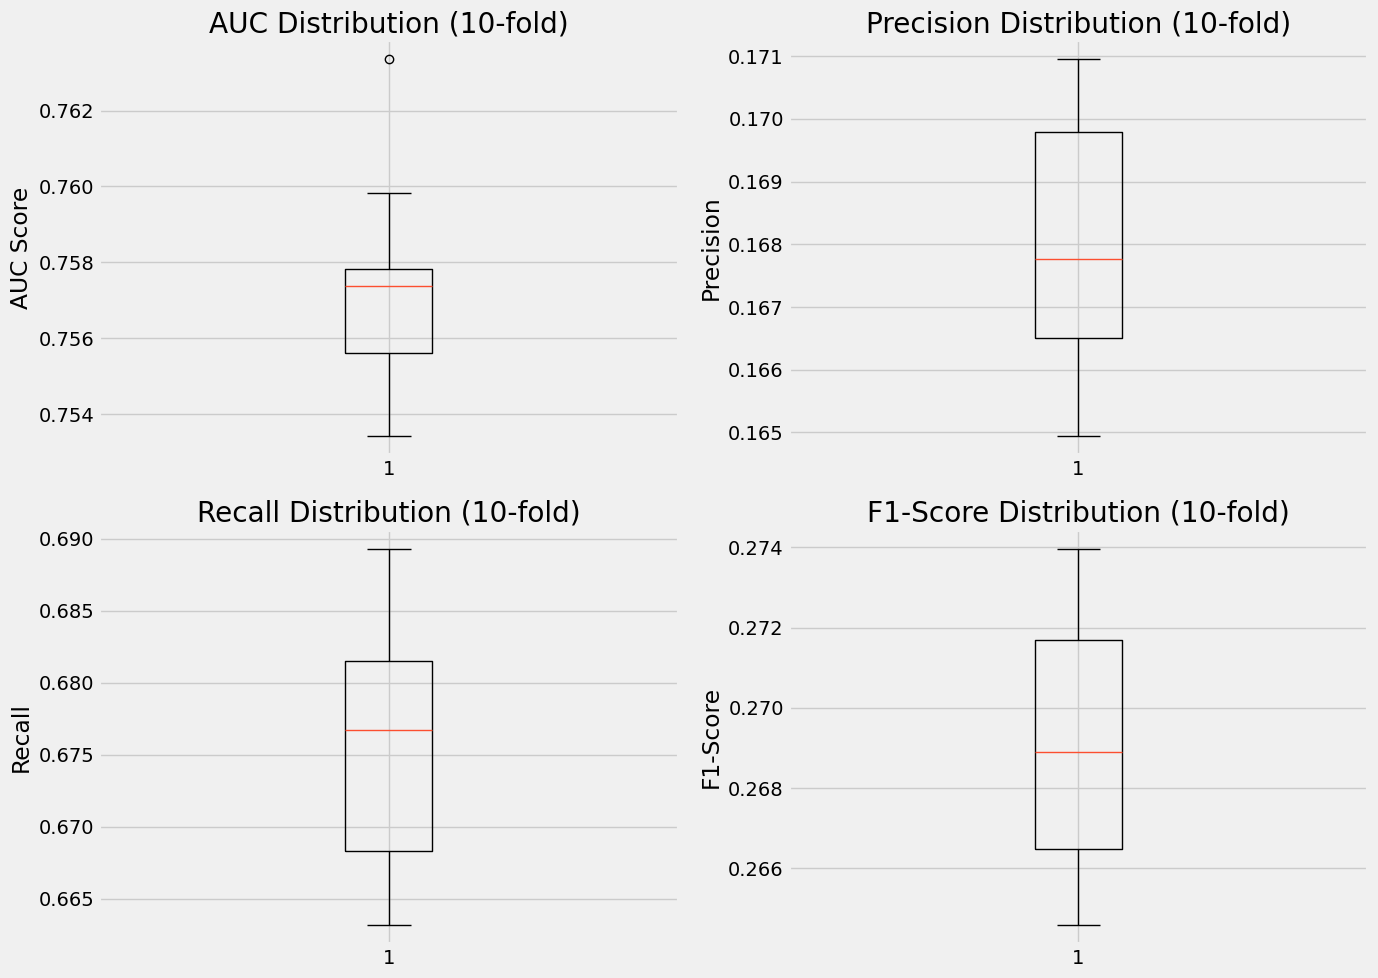

In [90]:
# Box plot des métriques CV
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# AUC
axes[0,0].boxplot(cv_results['test_roc_auc'])
axes[0,0].set_title('AUC Distribution (10-fold)')
axes[0,0].set_ylabel('AUC Score')

# Precision  
axes[0,1].boxplot(cv_results['test_precision'])
axes[0,1].set_title('Precision Distribution (10-fold)')
axes[0,1].set_ylabel('Precision')

# Recall
axes[1,0].boxplot(cv_results['test_recall'])
axes[1,0].set_title('Recall Distribution (10-fold)')
axes[1,0].set_ylabel('Recall')

# F1-Score
axes[1,1].boxplot(cv_results['test_f1'])
axes[1,1].set_title('F1-Score Distribution (10-fold)')
axes[1,1].set_ylabel('F1-Score')

plt.tight_layout()
plt.savefig('cv_metrics_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## 8.2 Validation finale sur le jeu de validation

ÉVALUATION FINALE - LightGBM_Balanced
MÉTRIQUES FINALES:
  Train AUC:      0.7853
  Validation AUC: 0.7612
  Overfitting:    0.0241
  Accuracy:       0.7047
  Precision:      0.1691
  Recall:         0.6792
  F1-Score:       0.2708

CONFUSION MATRIX:
  TN:  39969 | FP:  16569
  FN:   1593 | TP:   3372

PERFORMANCE:
  Temps d'entraînement: 3.68s
  Temps de prédiction:  0.63s


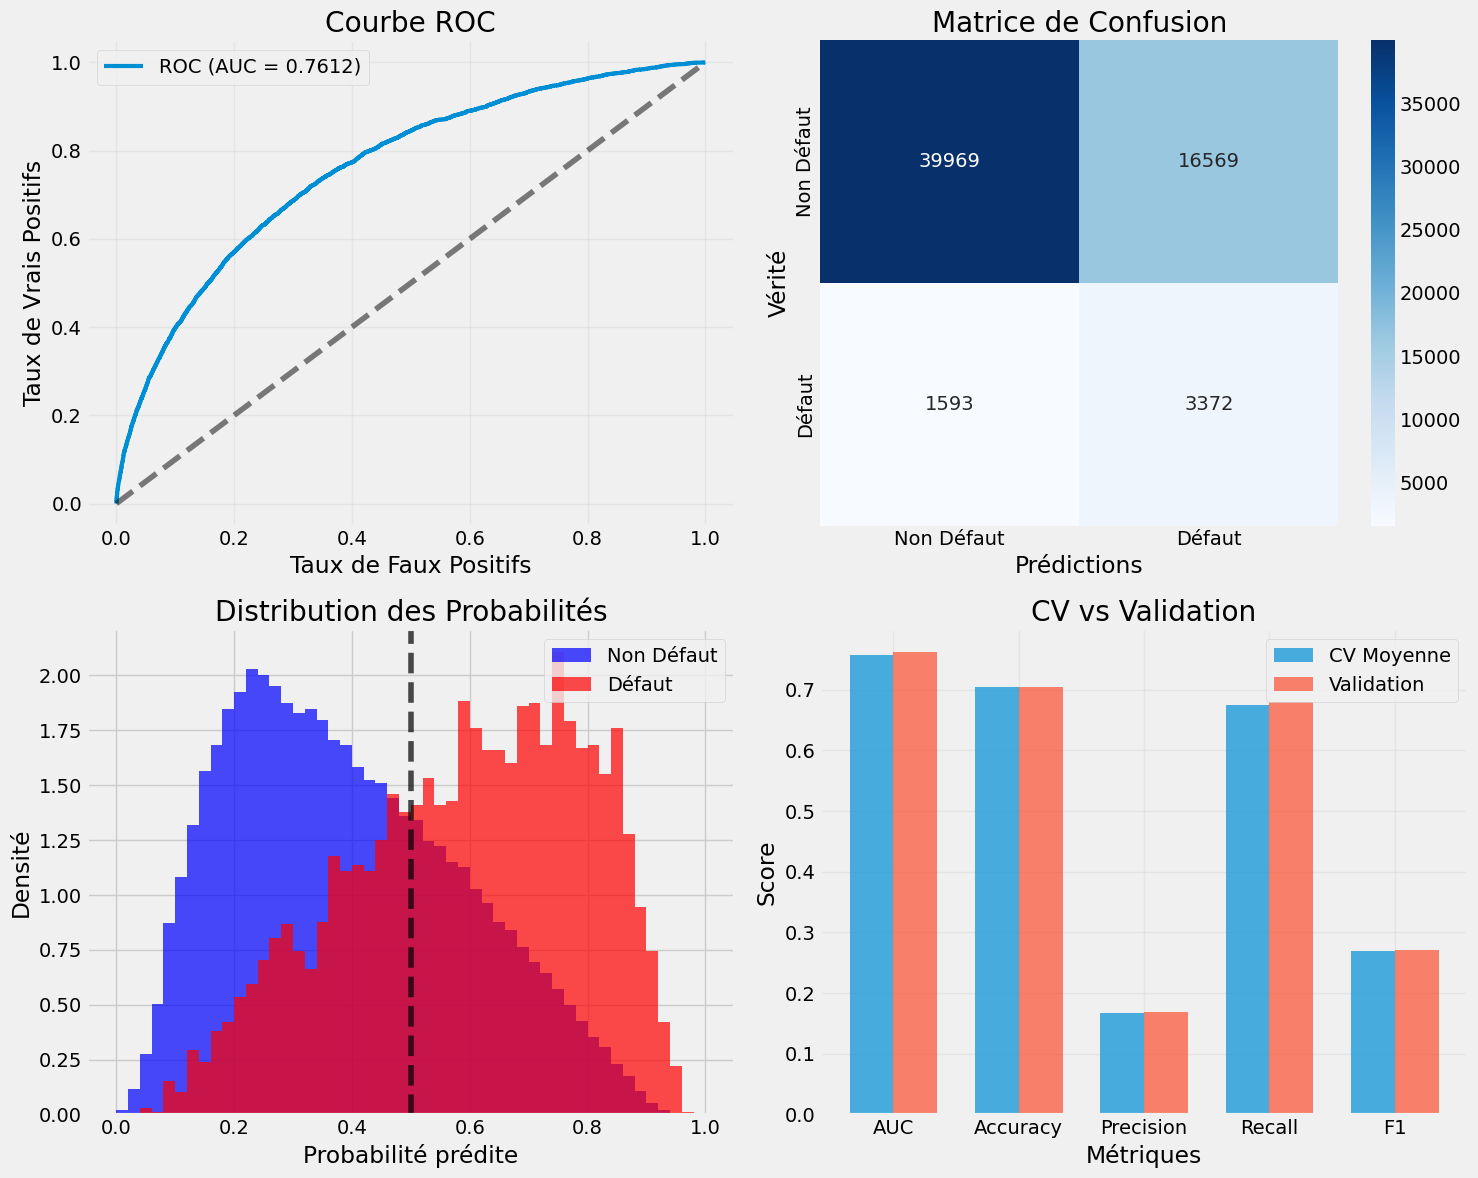

2025/09/28 11:53:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Non Défaut       0.96      0.71      0.81     56538
      Défaut       0.17      0.68      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.70      0.77     61503


COMPARAISON CV vs VALIDATION:
  CV AUC:         0.7573 ± 0.0027
  Validation AUC: 0.7612
  Différence:     +0.0039


2025/09/28 11:53:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Final_Evaluation_LightGBM_Balanced at: http://127.0.0.1:5000/#/experiments/546551843044102009/runs/2e03facce6ec44d784c7a5b020e11372
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546551843044102009


In [66]:
# Validation finale sur jeu de validation hold-out
def final_model_evaluation(model, X_train, y_train, X_val, y_val, model_name):
    """
    Évaluation finale complète du modèle
    """
    print(f"ÉVALUATION FINALE - {model_name}")
    print("="*50)
    
    with mlflow.start_run(run_name=f"Final_Evaluation_{model_name}"):
        # Entraîner sur toutes les données d'entraînement
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Prédictions
        start_time = time.time()
        train_pred_proba = model.predict_proba(X_train)[:, 1]
        val_pred_proba = model.predict_proba(X_val)[:, 1]
        prediction_time = time.time() - start_time
        
        train_pred_class = (train_pred_proba > 0.5).astype(int)
        val_pred_class = (val_pred_proba > 0.5).astype(int)
        
        # Métriques détaillées
        from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, 
                                   recall_score, f1_score, confusion_matrix, 
                                   classification_report, roc_curve)
        
        # Métriques d'entraînement
        train_auc = roc_auc_score(y_train, train_pred_proba)
        train_acc = accuracy_score(y_train, train_pred_class)
        
        # Métriques de validation
        val_auc = roc_auc_score(y_val, val_pred_proba)
        val_acc = accuracy_score(y_val, val_pred_class)
        val_precision = precision_score(y_val, val_pred_class)
        val_recall = recall_score(y_val, val_pred_class)
        val_f1 = f1_score(y_val, val_pred_class)
        
        # Matrice de confusion
        cm = confusion_matrix(y_val, val_pred_class)
        tn, fp, fn, tp = cm.ravel()
        
        # Overfitting
        overfitting_gap = train_auc - val_auc
        
        # Logs MLflow
        mlflow.log_metric("final_train_auc", train_auc)
        mlflow.log_metric("final_val_auc", val_auc)
        mlflow.log_metric("final_val_accuracy", val_acc)
        mlflow.log_metric("final_val_precision", val_precision)
        mlflow.log_metric("final_val_recall", val_recall)
        mlflow.log_metric("final_val_f1", val_f1)
        mlflow.log_metric("final_overfitting_gap", overfitting_gap)
        mlflow.log_metric("train_time", train_time)
        mlflow.log_metric("prediction_time", prediction_time)
        
        # Confusion matrix components
        mlflow.log_metric("true_negatives", tn)
        mlflow.log_metric("false_positives", fp)
        mlflow.log_metric("false_negatives", fn)
        mlflow.log_metric("true_positives", tp)
        
        # Affichage des résultats
        print(f"MÉTRIQUES FINALES:")
        print(f"  Train AUC:      {train_auc:.4f}")
        print(f"  Validation AUC: {val_auc:.4f}")
        print(f"  Overfitting:    {overfitting_gap:.4f}")
        print(f"  Accuracy:       {val_acc:.4f}")
        print(f"  Precision:      {val_precision:.4f}")
        print(f"  Recall:         {val_recall:.4f}")
        print(f"  F1-Score:       {val_f1:.4f}")
        
        print(f"\nCONFUSION MATRIX:")
        print(f"  TN: {tn:6d} | FP: {fp:6d}")
        print(f"  FN: {fn:6d} | TP: {tp:6d}")
        
        print(f"\nPERFORMANCE:")
        print(f"  Temps d'entraînement: {train_time:.2f}s")
        print(f"  Temps de prédiction:  {prediction_time:.2f}s")
        
        # Visualisations
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Courbe ROC
        fpr, tpr, _ = roc_curve(y_val, val_pred_proba)
        ax1.plot(fpr, tpr, label=f'ROC (AUC = {val_auc:.4f})', linewidth=3)
        ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax1.set_xlabel('Taux de Faux Positifs')
        ax1.set_ylabel('Taux de Vrais Positifs')
        ax1.set_title('Courbe ROC')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. Matrice de confusion
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
                   xticklabels=['Non Défaut', 'Défaut'],
                   yticklabels=['Non Défaut', 'Défaut'])
        ax2.set_title('Matrice de Confusion')
        ax2.set_xlabel('Prédictions')
        ax2.set_ylabel('Vérité')
        
        # 3. Distribution des probabilités
        bins = np.linspace(0, 1, 51)
        ax3.hist(val_pred_proba[y_val == 0], bins=bins, alpha=0.7, 
                label='Non Défaut', density=True, color='blue')
        ax3.hist(val_pred_proba[y_val == 1], bins=bins, alpha=0.7, 
                label='Défaut', density=True, color='red')
        ax3.axvline(x=0.5, color='black', linestyle='--', alpha=0.7)
        ax3.set_xlabel('Probabilité prédite')
        ax3.set_ylabel('Densité')
        ax3.set_title('Distribution des Probabilités')
        ax3.legend()
        
        # 4. Métriques de validation vs CV
        cv_auc_mean = cv_summary['roc_auc']['test_mean']
        cv_auc_std = cv_summary['roc_auc']['test_std']
        
        metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']
        cv_scores = [cv_summary['roc_auc']['test_mean'], cv_summary['accuracy']['test_mean'],
                    cv_summary['precision']['test_mean'], cv_summary['recall']['test_mean'],
                    cv_summary['f1']['test_mean']]
        val_scores = [val_auc, val_acc, val_precision, val_recall, val_f1]
        
        x = np.arange(len(metrics))
        width = 0.35
        
        ax4.bar(x - width/2, cv_scores, width, label='CV Moyenne', alpha=0.7)
        ax4.bar(x + width/2, val_scores, width, label='Validation', alpha=0.7)
        ax4.set_xlabel('Métriques')
        ax4.set_ylabel('Score')
        ax4.set_title('CV vs Validation')
        ax4.set_xticks(x)
        ax4.set_xticklabels(metrics)
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig("final_evaluation.png", dpi=300, bbox_inches='tight')
        mlflow.log_artifact("final_evaluation.png")
        plt.show()
        
        # Classification report
        print(f"\nCLASSIFICATION REPORT:")
        print(classification_report(y_val, val_pred_class, 
                                  target_names=['Non Défaut', 'Défaut']))
        
        # Comparaison avec CV
        print(f"\nCOMPARAISON CV vs VALIDATION:")
        print(f"  CV AUC:         {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")
        print(f"  Validation AUC: {val_auc:.4f}")
        print(f"  Différence:     {val_auc - cv_auc_mean:+.4f}")
        
        # Sauvegarde du modèle final
        mlflow.sklearn.log_model(model, "final_production_model")
        
        return {
            'model': model,
            'val_auc': val_auc,
            'val_metrics': {
                'accuracy': val_acc, 'precision': val_precision,
                'recall': val_recall, 'f1': val_f1
            },
            'confusion_matrix': cm,
            'overfitting_gap': overfitting_gap
        }

# Évaluation finale
final_results = final_model_evaluation(
    final_optimized_model, X_train_best, y_train_best, 
    X_val_processed, y_val, best_model_name
)

# 9. Feature importance globale et locale

##### Objectif :
- Globale : Identifier les variables les plus importantes pour le modèle dans son ensemble.
- Locale : Expliquer pourquoi le modèle a pris une décision spécifique pour un client donné.

##### Méthodes :
Globale :
- Utiliser feature_importances_ pour des modèles comme Random Forest ou XGBoost.
- Utiliser SHAP pour une analyse plus avancée et précise.

Locale :
- Utiliser SHAP pour expliquer les prédictions pour des clients spécifiques.
- Fournir des visualisations claires pour les parties prenantes.

In [67]:
# Importation et Configuration SHAP
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Initialiser SHAP pour les visualisations interactives
shap.initjs()

print("CONFIGURATION SHAP")
print("Bibliothèques SHAP importées")
print("Visualisations interactives initialisées")

CONFIGURATION SHAP
Bibliothèques SHAP importées
Visualisations interactives initialisées


## 9.1 Feature Importance globale

In [68]:
# Fonction d'Analyse Globale SHAP
def shap_global_analysis(model, X_sample, feature_names, model_name="Model", max_display=20):
    """
    Analyse globale des features avec SHAP
    """
    print(f"ANALYSE GLOBALE SHAP - {model_name}")
    
    try:
        # Créer l'explainer SHAP
        print("Création de l'explainer SHAP...")
        if hasattr(model, 'predict_proba'):
            # Pour les modèles de classification
            explainer = shap.TreeExplainer(model)
        else:
            # Fallback pour d'autres types de modèles
            explainer = shap.Explainer(model)
        
        # Calculer les valeurs SHAP sur un échantillon
        print(f"Calcul des valeurs SHAP sur {len(X_sample)} échantillons...")
        shap_values = explainer.shap_values(X_sample)
        
        # Pour les modèles de classification binaire, prendre la classe positive
        if isinstance(shap_values, list) and len(shap_values) == 2:
            shap_values_plot = shap_values[1]  # Classe positive (défaut)
        else:
            shap_values_plot = shap_values
        
        print("Valeurs SHAP calculées avec succès")
        
        return shap_values, explainer, shap_values_plot
        
    except Exception as e:
        print(f"Erreur dans l'analyse SHAP globale: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None

In [69]:
# Visualisations SHAP Globales
def create_global_shap_plots(shap_values_plot, X_sample, feature_names, explainer, model_name):
    """
    Créer toutes les visualisations SHAP globales
    """
    print(f"CRÉATION DES VISUALISATIONS GLOBALES")
    
    # 1. Summary Plot (Feature Importance + Distribution)
    print("Création du Summary Plot...")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_plot, X_sample, 
                     feature_names=feature_names, 
                     max_display=20, 
                     show=False)
    plt.title(f'SHAP Summary Plot - {model_name}', fontsize=14, pad=20)
    plt.tight_layout()
    
    filename1 = f'shap_summary_plot_{model_name.replace(" ", "_")}.png'
    plt.savefig(filename1, dpi=300, bbox_inches='tight')
    
    # Log MLflow si disponible
    try:
        import mlflow
        if mlflow.active_run():
            mlflow.log_artifact(filename1)
    except:
        pass
    
    plt.show()
    
    # 2. Bar Plot (Feature Importance moyenne)
    print("Création du Bar Plot...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_plot, X_sample, 
                     feature_names=feature_names,
                     plot_type="bar", 
                     max_display=20,
                     show=False)
    plt.title(f'SHAP Feature Importance (Moyenne) - {model_name}', fontsize=14, pad=20)
    plt.tight_layout()
    
    filename2 = f'shap_feature_importance_{model_name.replace(" ", "_")}.png'
    plt.savefig(filename2, dpi=300, bbox_inches='tight')
    
    try:
        import mlflow
        if mlflow.active_run():
            mlflow.log_artifact(filename2)
    except:
        pass
    
    plt.show()
    
    # 3. Waterfall Plot (Impact global moyen)
    print("Création du Waterfall Plot global...")
    plt.figure(figsize=(12, 8))
    
    expected_value = explainer.expected_value
    if isinstance(expected_value, list):
        expected_value = expected_value[1]  # Classe positive
    
    # Calculer les valeurs moyennes pour le waterfall
    mean_shap_values = np.mean(np.abs(shap_values_plot), axis=0)
    mean_features = np.mean(X_sample, axis=0)
    
    # Créer un waterfall plot pour les top features
    top_indices = np.argsort(mean_shap_values)[-15:][::-1]
    
    shap.waterfall_plot(
        shap.Explanation(
            values=np.mean(shap_values_plot, axis=0)[top_indices],
            base_values=expected_value,
            data=mean_features[top_indices],
            feature_names=[feature_names[i] for i in top_indices]
        ),
        max_display=15,
        show=False
    )
    plt.title(f'SHAP Waterfall Plot (Impact Moyen) - {model_name}', fontsize=14, pad=20)
    plt.tight_layout()
    
    filename3 = f'shap_waterfall_global_{model_name.replace(" ", "_")}.png'
    plt.savefig(filename3, dpi=300, bbox_inches='tight')
    
    try:
        import mlflow
        if mlflow.active_run():
            mlflow.log_artifact(filename3)
    except:
        pass
    
    plt.show()
    
    print("Toutes les visualisations globales créées")
    return expected_value

In [70]:
# Statistiques SHAP Globales
def compute_global_shap_statistics(shap_values_plot, feature_names, expected_value):
    """
    Calculer et afficher les statistiques SHAP globales
    """
    print(f"CALCUL DES STATISTIQUES GLOBALES")
    
    # Calcul de l'importance globale
    feature_importance_global = np.mean(np.abs(shap_values_plot), axis=0)
    
    # Créer DataFrame des résultats
    shap_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Importance': feature_importance_global,
        'Mean_SHAP_Value': np.mean(shap_values_plot, axis=0),
        'Std_SHAP_Value': np.std(shap_values_plot, axis=0)
    }).sort_values('SHAP_Importance', ascending=False)
    
    print(f"TOP 15 FEATURES (SHAP GLOBALE):")
    print(shap_importance_df.head(15).round(6).to_string(index=False))
    
    # Statistiques globales
    total_importance = np.sum(feature_importance_global)
    print(f"STATISTIQUES GLOBALES SHAP:")
    print(f"  Importance SHAP totale: {total_importance:.6f}")
    print(f"  Valeur de base (expected_value): {expected_value:.6f}")
    print(f"  Nombre de features analysées: {len(feature_names)}")
    
    # Contribution des top features
    top_5_contrib = np.sum(shap_importance_df.head(5)['SHAP_Importance']) / total_importance * 100
    top_10_contrib = np.sum(shap_importance_df.head(10)['SHAP_Importance']) / total_importance * 100
    
    print(f"  Top 5 features: {top_5_contrib:.1f}% de l'importance totale")
    print(f"  Top 10 features: {top_10_contrib:.1f}% de l'importance totale")
    
    # Log dans MLflow
    try:
        import mlflow
        if mlflow.active_run():
            mlflow.log_metric("shap_expected_value", float(expected_value))
            mlflow.log_metric("shap_total_importance", total_importance)
            mlflow.log_metric("shap_top5_contribution", top_5_contrib)
            mlflow.log_metric("shap_top10_contribution", top_10_contrib)
    except:
        pass
    
    return shap_importance_df

## 9.2 Feature Importance locale

In [71]:
# Fonction d'Analyse Locale SHAP
def shap_local_analysis(explainer, shap_values, X_sample, feature_names, 
                       client_indices=None, model_name="Model"):
    """
    Analyse locale des features avec SHAP pour des clients spécifiques
    """
    print(f"ANALYSE LOCALE SHAP - {model_name}")
    
    try:
        # Sélectionner des clients d'intérêt si non spécifiés
        if client_indices is None:
            # Prendre quelques clients avec différents profils de risque
            if isinstance(shap_values, list):
                values_to_analyze = shap_values[1]  # Classe positive
            else:
                values_to_analyze = shap_values
            
            # Calculer les scores de risque pour chaque client
            client_scores = np.sum(values_to_analyze, axis=1)
            
            # Sélectionner des clients représentatifs
            high_risk_idx = np.argmax(client_scores)  # Plus haut risque
            low_risk_idx = np.argmin(client_scores)   # Plus bas risque
            median_idx = np.argsort(client_scores)[len(client_scores)//2]  # Médian
            
            client_indices = [low_risk_idx, median_idx, high_risk_idx]
            client_labels = ["Risque FAIBLE", "Risque MOYEN", "Risque ÉLEVÉ"]
        else:
            client_labels = [f"Client {i}" for i in client_indices]
        
        print(f"Analyse de {len(client_indices)} clients représentatifs...")
        
        return client_indices, client_labels
        
    except Exception as e:
        print(f"Erreur dans la sélection des clients: {e}")
        return None, None

In [72]:
# Visualisations SHAP Locales
def create_local_shap_plots(explainer, shap_values, X_sample, feature_names, 
                           client_indices, client_labels, model_name):
    """
    Créer les visualisations SHAP pour des clients spécifiques
    """
    print(f"CRÉATION DES VISUALISATIONS LOCALES")
    
    expected_value = explainer.expected_value
    if isinstance(expected_value, list):
        expected_value = expected_value[1]
    
    # Analyser chaque client
    for i, (client_idx, label) in enumerate(zip(client_indices, client_labels)):
        print(f"\n--- {label} (Index: {client_idx}) ---")
        
        # 1. Waterfall Plot pour ce client
        print(f"Création Waterfall Plot pour {label}...")
        plt.figure(figsize=(12, 8))
        
        if isinstance(shap_values, list):
            client_shap_values = shap_values[1][client_idx]
        else:
            client_shap_values = shap_values[client_idx]
        
        client_data = X_sample[client_idx]
        
        shap.waterfall_plot(
            shap.Explanation(
                values=client_shap_values,
                base_values=expected_value,
                data=client_data,
                feature_names=feature_names
            ),
            max_display=15,
            show=False
        )
        
        plt.title(f'SHAP Waterfall - {label} (Client {client_idx})', fontsize=14, pad=20)
        plt.tight_layout()
        
        filename = f'shap_waterfall_client_{client_idx}_{label.replace(" ", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        
        try:
            import mlflow
            if mlflow.active_run():
                mlflow.log_artifact(filename)
        except:
            pass
        
        plt.show()
        
        # 2. Force Plot pour ce client (si possible)
        print(f"Création Force Plot pour {label}...")
        try:
            plt.figure(figsize=(16, 6))
            
            if isinstance(shap_values, list):
                force_plot_data = shap_values[1][client_idx:client_idx+1]
            else:
                force_plot_data = shap_values[client_idx:client_idx+1]
            
            shap.force_plot(
                expected_value,
                force_plot_data,
                X_sample[client_idx:client_idx+1],
                feature_names=feature_names,
                matplotlib=True,
                show=False
            )
            
            plt.title(f'SHAP Force Plot - {label} (Client {client_idx})', fontsize=14, pad=20)
            plt.tight_layout()
            
            filename = f'shap_force_client_{client_idx}_{label.replace(" ", "_")}.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            
            try:
                import mlflow
                if mlflow.active_run():
                    mlflow.log_artifact(filename)
            except:
                pass
            
            plt.show()
            
        except Exception as e:
            print(f"Force plot non disponible pour ce client: {e}")
    
    print("Toutes les visualisations locales créées")

In [73]:
# Analyse Quantitative Locale
def analyze_local_shap_details(explainer, shap_values, X_sample, feature_names, 
                              client_indices, client_labels):
    """
    Analyser en détail les contributions SHAP pour chaque client
    """
    print(f"ANALYSE QUANTITATIVE LOCALE")
    
    expected_value = explainer.expected_value
    if isinstance(expected_value, list):
        expected_value = expected_value[1]
    
    comparison_data = []
    
    for client_idx, label in zip(client_indices, client_labels):
        print(f"DÉTAILS POUR {label} (Client {client_idx}):")
        
        if isinstance(shap_values, list):
            client_shap_values = shap_values[1][client_idx]
        else:
            client_shap_values = shap_values[client_idx]
        
        client_data = X_sample[client_idx]
        
        # Trier les features par impact absolu
        feature_impacts = pd.DataFrame({
            'Feature': feature_names,
            'SHAP_Value': client_shap_values,
            'Feature_Value': client_data,
            'Abs_Impact': np.abs(client_shap_values)
        }).sort_values('Abs_Impact', ascending=False)
        
        print(f"TOP 10 FEATURES IMPACTANTES:")
        for _, row in feature_impacts.head(10).iterrows():
            impact_direction = "↗️" if row['SHAP_Value'] > 0 else "↘️"
            print(f"{row['Feature']:<30} {impact_direction} {row['SHAP_Value']:>8.4f} (valeur: {row['Feature_Value']:>8.2f})")
        
        # Score total pour ce client
        total_shap = np.sum(client_shap_values)
        prediction_score = expected_value + total_shap
        
        print(f"  SCORE DÉTAILLÉ:")
        print(f"  Valeur de base: {expected_value:.4f}")
        print(f"  Contribution SHAP: {total_shap:+.4f}")
        print(f"  Score final: {prediction_score:.4f}")
        print(f"  Probabilité de défaut: {prediction_score:.1%}")
        
        # Stocker pour comparaison
        comparison_data.append({
            'Client': label,
            'Index': client_idx,
            'Score_Final': prediction_score,
            'Contribution_SHAP': total_shap,
            'Probabilite_Defaut': prediction_score
        })
    
    return comparison_data

## 9.3 Comparaison des Profils Clients

In [74]:
def compare_client_profiles(comparison_data):
    """
    Comparer les profils des différents clients analysés
    """
    print(f"COMPARAISON DES PROFILS CLIENTS:")
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.round(4).to_string(index=False))
    
    # Créer une visualisation comparative
    plt.figure(figsize=(14, 8))
    
    # Graphique en barres pour la comparaison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Score final
    bars1 = ax1.bar(comparison_df['Client'], comparison_df['Score_Final'], 
                    color=['green', 'orange', 'red'], alpha=0.7)
    ax1.set_title('Score Final par Client')
    ax1.set_ylabel('Score de Prédiction')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Ajouter les valeurs sur les barres
    for bar, score in zip(bars1, comparison_df['Score_Final']):
        height = bar.get_height()
        ax1.annotate(f'{score:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')
    
    # Contribution SHAP
    bars2 = ax2.bar(comparison_df['Client'], comparison_df['Contribution_SHAP'], 
                    color=['green', 'orange', 'red'], alpha=0.7)
    ax2.set_title('Contribution SHAP par Client')
    ax2.set_ylabel('Contribution SHAP')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Ajouter les valeurs sur les barres
    for bar, contrib in zip(bars2, comparison_df['Contribution_SHAP']):
        height = bar.get_height()
        ax2.annotate(f'{contrib:+.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('shap_client_comparison.png', dpi=300, bbox_inches='tight')
    
    try:
        import mlflow
        if mlflow.active_run():
            mlflow.log_artifact('shap_client_comparison.png')
    except:
        pass
    
    plt.show()
    
    return comparison_df

## 9.4 Exécution Complète de l'Analyse SHAP

Échantillon SHAP: 1000 observations
Features à analyser: 240
ANALYSE GLOBALE SHAP - LightGBM_Balanced
Création de l'explainer SHAP...
Calcul des valeurs SHAP sur 1000 échantillons...
Valeurs SHAP calculées avec succès
ÉTAPE 1 TERMINÉE: Calculs SHAP globaux
CRÉATION DES VISUALISATIONS GLOBALES
Création du Summary Plot...


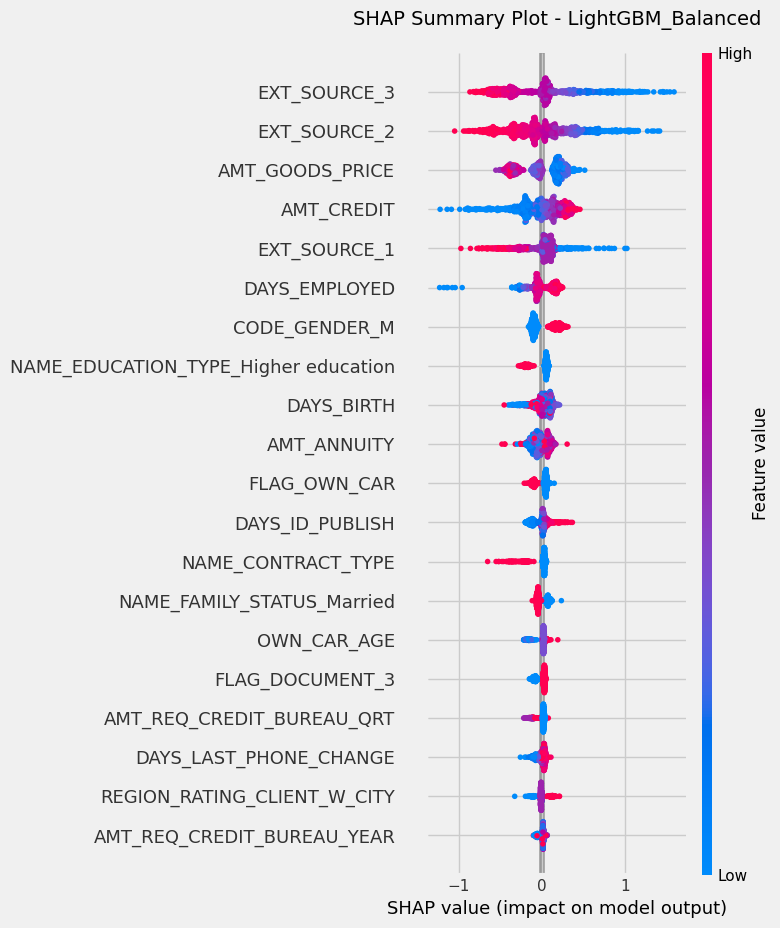

Création du Bar Plot...


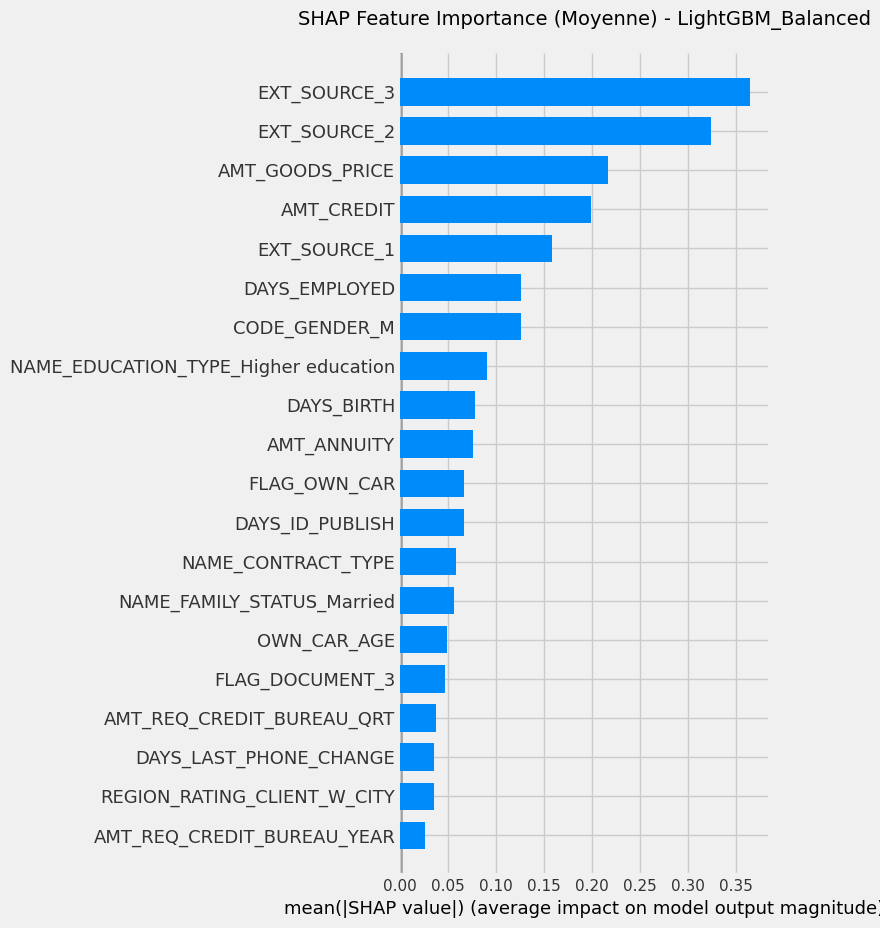

Création du Waterfall Plot global...


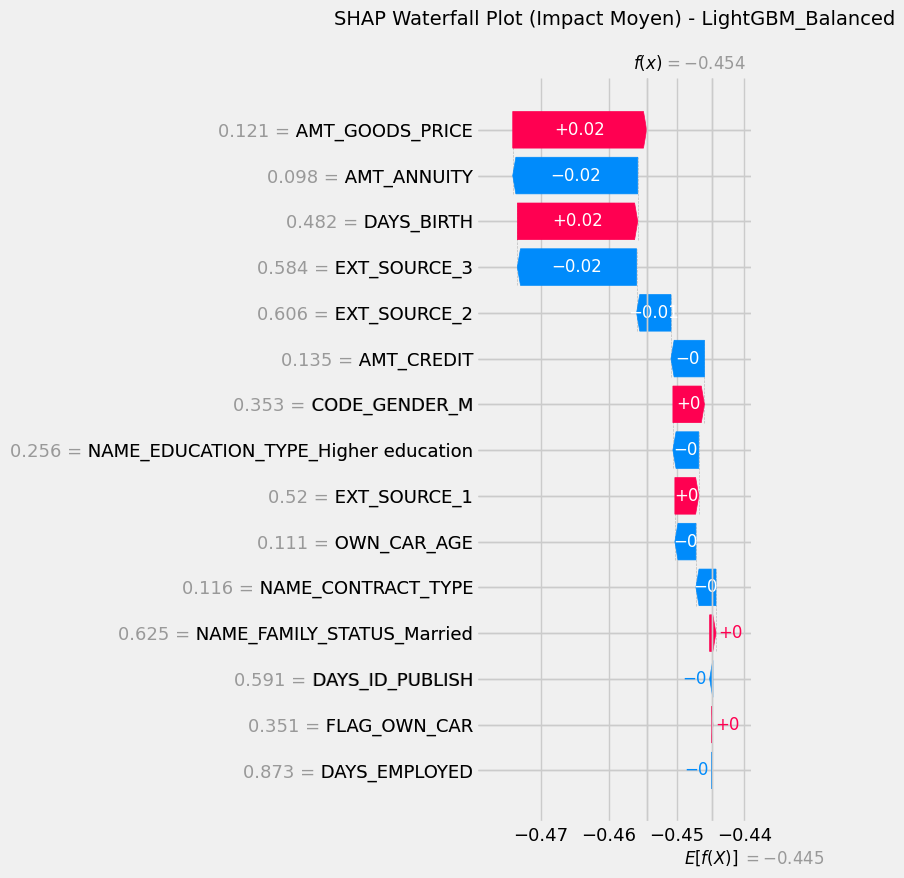

Toutes les visualisations globales créées
ÉTAPE 2 TERMINÉE: Visualisations SHAP globales
CALCUL DES STATISTIQUES GLOBALES
TOP 15 FEATURES (SHAP GLOBALE):
                             Feature  SHAP_Importance  Mean_SHAP_Value  Std_SHAP_Value
                        EXT_SOURCE_3         0.364685        -0.017554        0.469459
                        EXT_SOURCE_2         0.324024        -0.005063        0.416362
                     AMT_GOODS_PRICE         0.215875         0.019709        0.245534
                          AMT_CREDIT         0.198489        -0.004922        0.259224
                        EXT_SOURCE_1         0.157631         0.003519        0.231726
                       DAYS_EMPLOYED         0.125956        -0.000002        0.168455
                       CODE_GENDER_M         0.125809         0.004639        0.137093
NAME_EDUCATION_TYPE_Higher education         0.090088        -0.003809        0.106838
                          DAYS_BIRTH         0.077843         0

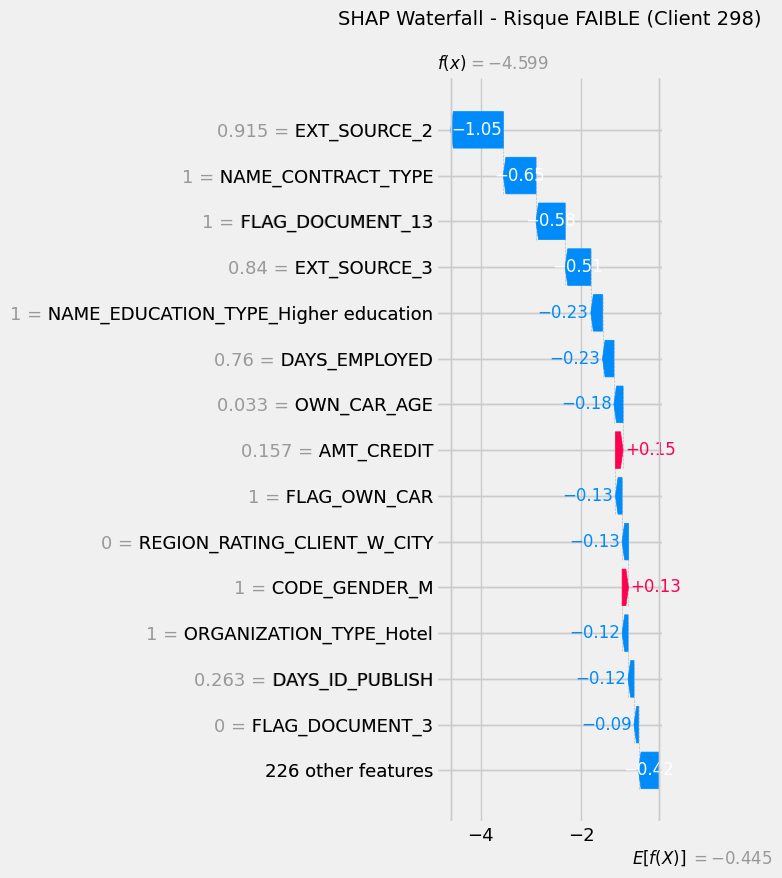

Création Force Plot pour Risque FAIBLE...


<Figure size 1600x600 with 0 Axes>

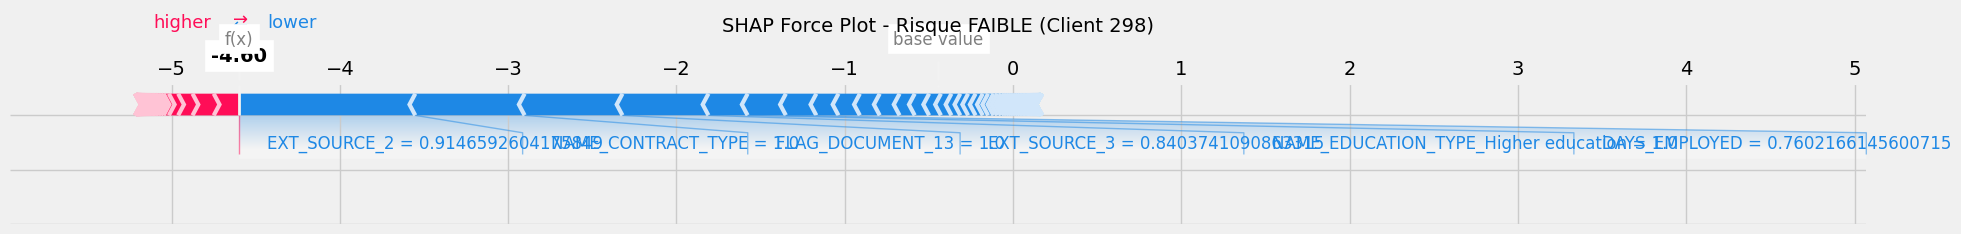


--- Risque MOYEN (Index: 382) ---
Création Waterfall Plot pour Risque MOYEN...


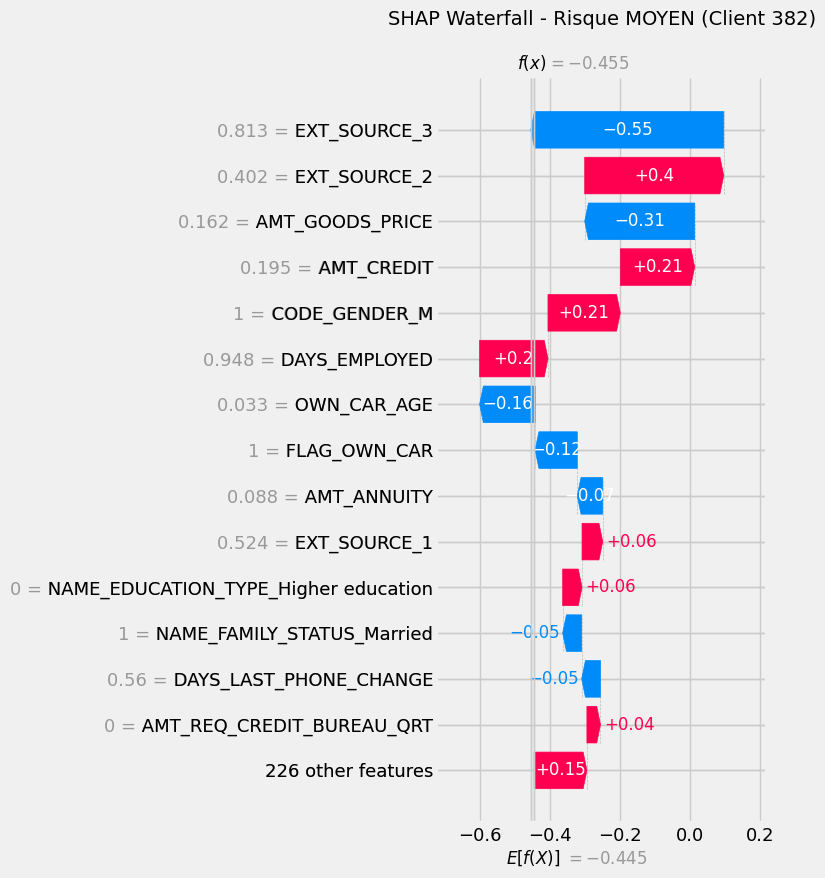

Création Force Plot pour Risque MOYEN...


<Figure size 1600x600 with 0 Axes>

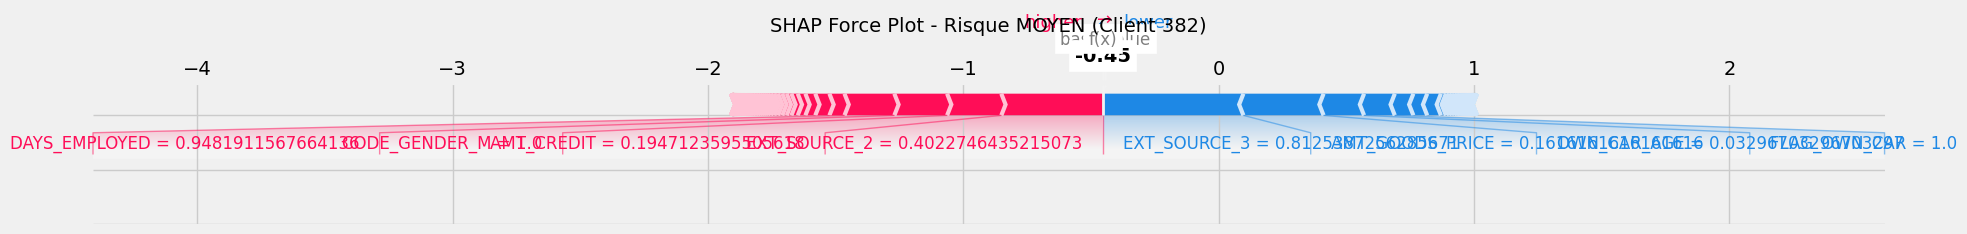


--- Risque ÉLEVÉ (Index: 714) ---
Création Waterfall Plot pour Risque ÉLEVÉ...


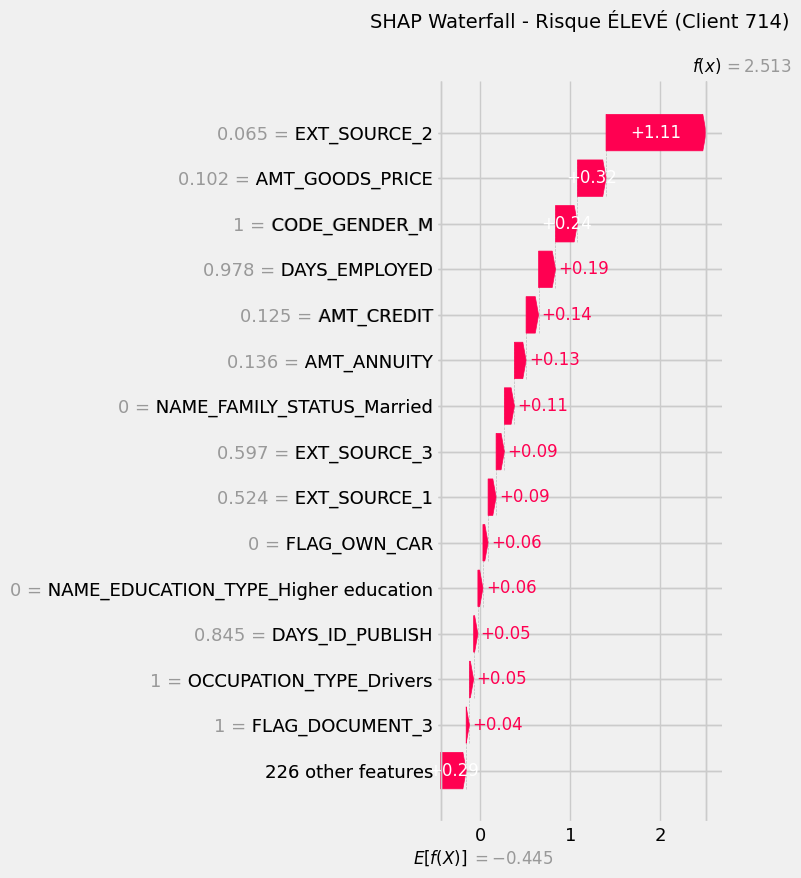

Création Force Plot pour Risque ÉLEVÉ...


<Figure size 1600x600 with 0 Axes>

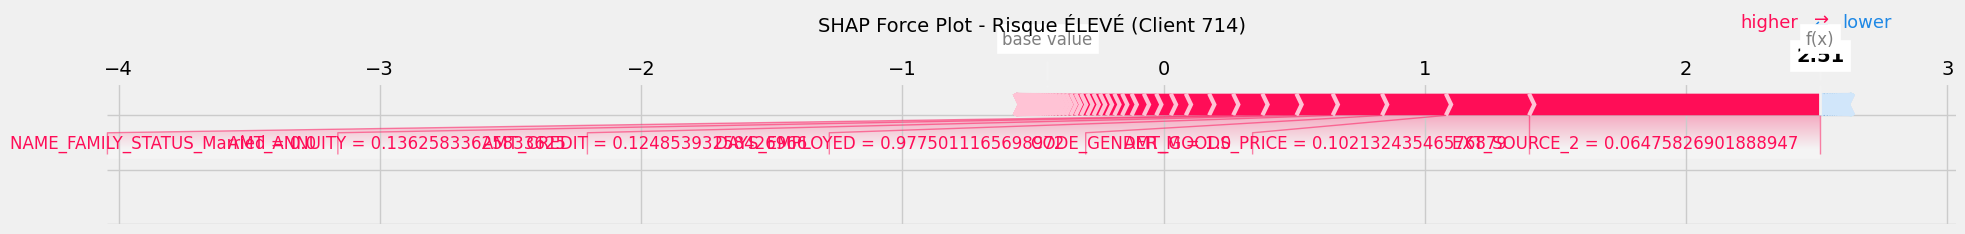

Toutes les visualisations locales créées
ÉTAPE 5 TERMINÉE: Visualisations SHAP locales
ANALYSE QUANTITATIVE LOCALE
DÉTAILS POUR Risque FAIBLE (Client 298):
TOP 10 FEATURES IMPACTANTES:
EXT_SOURCE_2                   ↘️  -1.0468 (valeur:     0.91)
NAME_CONTRACT_TYPE             ↘️  -0.6498 (valeur:     1.00)
FLAG_DOCUMENT_13               ↘️  -0.5812 (valeur:     1.00)
EXT_SOURCE_3                   ↘️  -0.5108 (valeur:     0.84)
NAME_EDUCATION_TYPE_Higher education ↘️  -0.2328 (valeur:     1.00)
DAYS_EMPLOYED                  ↘️  -0.2272 (valeur:     0.76)
OWN_CAR_AGE                    ↘️  -0.1808 (valeur:     0.03)
AMT_CREDIT                     ↗️   0.1506 (valeur:     0.16)
FLAG_OWN_CAR                   ↘️  -0.1315 (valeur:     1.00)
REGION_RATING_CLIENT_W_CITY    ↘️  -0.1270 (valeur:     0.00)
  SCORE DÉTAILLÉ:
  Valeur de base: -0.4449
  Contribution SHAP: -4.1539
  Score final: -4.5987
  Probabilité de défaut: -459.9%
DÉTAILS POUR Risque MOYEN (Client 382):
TOP 10 FEATURES IMPA

<Figure size 1400x800 with 0 Axes>

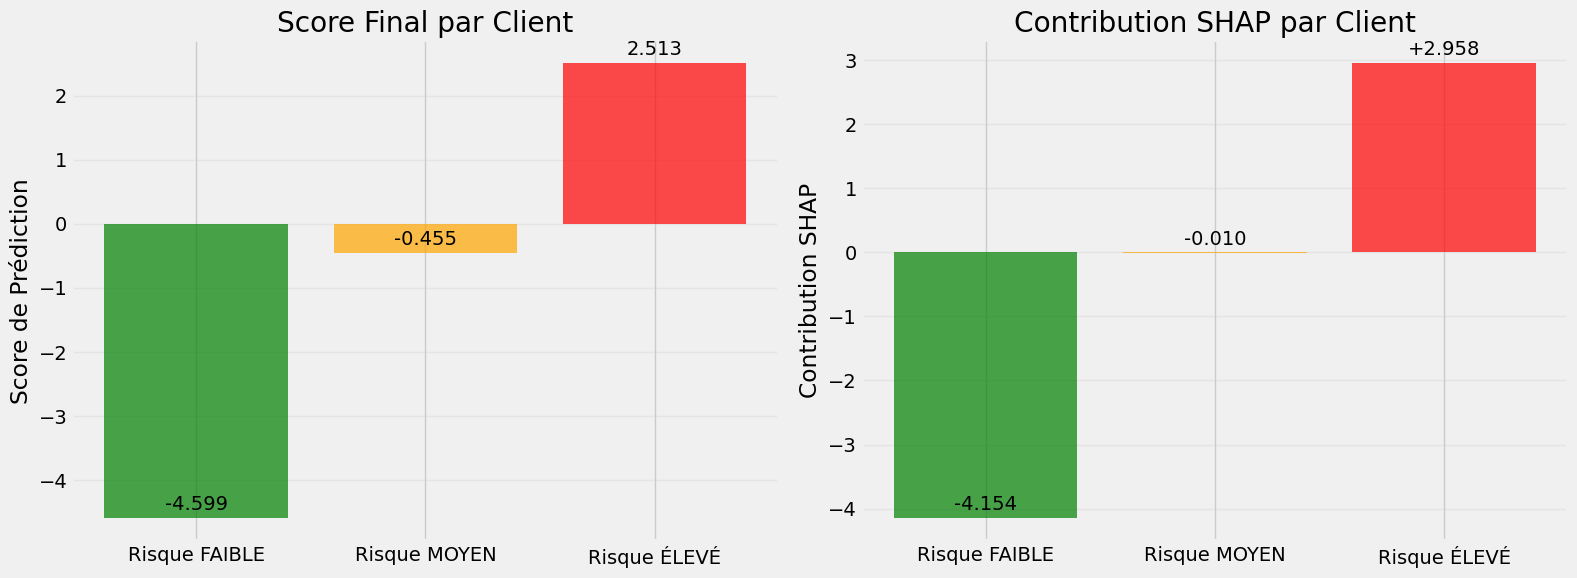

ÉTAPE 7 TERMINÉE: Comparaison des profils clients


In [75]:
# Préparer un échantillon pour SHAP (pour éviter les temps de calcul trop longs)
sample_size = min(1000, len(X_val_processed))
sample_indices = np.random.choice(len(X_val_processed), sample_size, replace=False)
X_shap_sample = X_val_processed[sample_indices]

print(f"Échantillon SHAP: {sample_size} observations")
print(f"Features à analyser: {len(features)}")

# ÉTAPE 1: Analyse globale - Calculs
shap_values, shap_explainer, shap_values_plot = shap_global_analysis(
    final_optimized_model, 
    X_shap_sample, 
    features, 
    best_model_name
)

if shap_values is not None:
    print("ÉTAPE 1 TERMINÉE: Calculs SHAP globaux")
    
    # ÉTAPE 2: Analyse globale - Visualisations
    expected_value = create_global_shap_plots(
        shap_values_plot, X_shap_sample, features, shap_explainer, best_model_name
    )
    print("ÉTAPE 2 TERMINÉE: Visualisations SHAP globales")
    
    # ÉTAPE 3: Analyse globale - Statistiques
    global_importance_df = compute_global_shap_statistics(
        shap_values_plot, features, expected_value
    )
    print("ÉTAPE 3 TERMINÉE: Statistiques SHAP globales")

    # ÉTAPE 4: Analyse locale - Sélection des clients
    client_indices, client_labels = shap_local_analysis(
        shap_explainer, shap_values, X_shap_sample, features, 
        model_name=best_model_name
    )
    print("ÉTAPE 4 TERMINÉE: Sélection des clients représentatifs")
    
    if client_indices is not None:
        # ÉTAPE 5: Analyse locale - Visualisations
        create_local_shap_plots(
            shap_explainer, shap_values, X_shap_sample, features,
            client_indices, client_labels, best_model_name
        )
        print("ÉTAPE 5 TERMINÉE: Visualisations SHAP locales")
        
        # ÉTAPE 6: Analyse locale - Détails quantitatifs
        comparison_data = analyze_local_shap_details(
            shap_explainer, shap_values, X_shap_sample, features,
            client_indices, client_labels
        )
        print("ÉTAPE 6 TERMINÉE: Analyse quantitative locale")
        
        # ÉTAPE 7: Comparaison finale
        local_comparison_df = compare_client_profiles(comparison_data)
        print("ÉTAPE 7 TERMINÉE: Comparaison des profils clients")
        
else:
    print("Échec de l'analyse SHAP - Arrêt du processus")

## 9.5 Sauvegarde des Résultats SHAP

In [76]:
if 'global_importance_df' in locals() and global_importance_df is not None:
    # Sauvegarder les résultats globaux
    global_importance_df.to_csv('shap_global_importance.csv', index=False)
    print("Importance globale SHAP sauvegardée: 'shap_global_importance.csv'")

if 'local_comparison_df' in locals() and local_comparison_df is not None:
    # Sauvegarder les résultats locaux
    local_comparison_df.to_csv('shap_local_comparison.csv', index=False)
    print("Comparaison locale SHAP sauvegardée: 'shap_local_comparison.csv'")

print(f"ANALYSE SHAP COMPLÈTE TERMINÉE AVEC SUCCÈS!")
print("RÉSULTATS OBTENUS:")
print("Analyse globale: Feature importance et distributions")
print("Analyse locale: Profils de 3 clients représentatifs")
print("Visualisations complètes: Summary, Bar, Waterfall, Force plots")
print("Données quantitatives: Statistiques et comparaisons")
print("Intégration MLflow: Graphiques et métriques loggés")
print("Fichiers sauvegardés: CSV et images PNG")
print("L'interprétabilité du modèle est maintenant complète!")

Importance globale SHAP sauvegardée: 'shap_global_importance.csv'
Comparaison locale SHAP sauvegardée: 'shap_local_comparison.csv'
ANALYSE SHAP COMPLÈTE TERMINÉE AVEC SUCCÈS!
RÉSULTATS OBTENUS:
Analyse globale: Feature importance et distributions
Analyse locale: Profils de 3 clients représentatifs
Visualisations complètes: Summary, Bar, Waterfall, Force plots
Données quantitatives: Statistiques et comparaisons
Intégration MLflow: Graphiques et métriques loggés
Fichiers sauvegardés: CSV et images PNG
L'interprétabilité du modèle est maintenant complète!


# 10. Métrique métier et optimisation du seuil

##### Objectif :
- Intégrer une métrique métier pour minimiser le coût des erreurs (faux négatifs et faux positifs).
- Optimiser le seuil de classification pour réduire ce coût.

##### Étapes :
1. Définir le coût métier : Par exemple, un faux négatif coûte 10 fois plus qu'un faux positif.
2. Optimiser le seuil de classification : Tester différents seuils pour trouver celui qui minimise le coût métier et ajouter la métrique métier dans nos logs MLflow : Logguer le coût métier pour chaque modèle testé.

## 10.1 Métrique métier et optimisation du seuil

OPTIMISATION DU SEUIL AVEC MÉTRIQUE MÉTIER
  OPTIMISATION DU SEUIL MÉTIER
   Coût FN (mauvais client accepté): 10
   Coût FP (bon client refusé): 1
   Ratio coût FN/FP: 10.0
   Test de 99 seuils...

  SEUIL OPTIMAL TROUVÉ:
   Seuil optimal: 0.52
   Coût minimal: 32,384
   Faux Négatifs: 1733 (coût: 17,330)
   Faux Positifs: 15054 (coût: 15,054)

 COMPARAISON AVEC SEUIL 0.5:
   Coût avec seuil 0.5: 32,499
   Coût avec seuil optimal: 32,384
   Économie: 115 (0.4%)


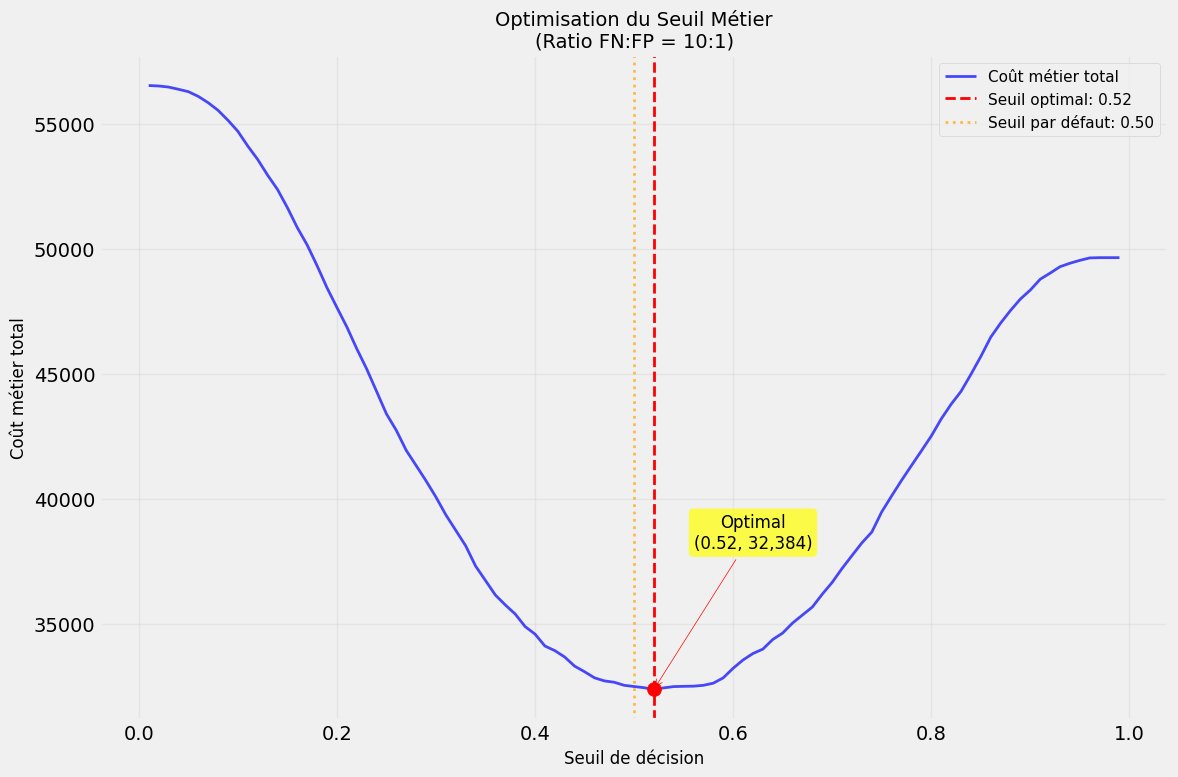


 OPTIMISATION TERMINÉE
Le seuil optimal est 0.52 au lieu de 0.5 par défaut
Graphique sauvegardé: threshold_optimization_business.png


In [77]:
def find_optimal_threshold_business(y_true, y_proba, cost_fn=10, cost_fp=1):
    """
    Trouve le seuil optimal pour minimiser le coût métier
    - Boucle simple de 0.01 à 0.99 par 
    - Un seul graphique coût vs seuil
    - Pas de logging MLflow
    
    Args:
        y_true: vraies étiquettes
        y_proba: probabilités prédites 
        cost_fn: coût d'un faux négatif (défaut = 10)
        cost_fp: coût d'un faux positif (défaut = 1)
    
    Returns:
        optimal_threshold: seuil optimal trouvé
        min_cost: coût minimal
    """
    print("  OPTIMISATION DU SEUIL MÉTIER")
    print(f"   Coût FN (mauvais client accepté): {cost_fn}")
    print(f"   Coût FP (bon client refusé): {cost_fp}")
    print(f"   Ratio coût FN/FP: {cost_fn/cost_fp}")
    
    # Test de tous les seuils de 0.01 à 0.99
    thresholds = np.arange(0.01, 1.00, 0.01)
    costs = []
    
    print(f"   Test de {len(thresholds)} seuils...")
    
    for threshold in thresholds:
        # Prédictions avec ce seuil
        y_pred = (y_proba >= threshold).astype(int)
        
        # Matrice de confusion
        from sklearn.metrics import confusion_matrix
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        
        # Coût métier total
        total_cost = fn * cost_fn + fp * cost_fp
        costs.append(total_cost)
    
    # Trouver le seuil optimal (coût minimum)
    optimal_idx = np.argmin(costs)
    optimal_threshold = thresholds[optimal_idx]
    min_cost = costs[optimal_idx]
    
    # Calcul des métriques pour le seuil optimal
    y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
    tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_true, y_pred_optimal).ravel()
    
    print(f"\n  SEUIL OPTIMAL TROUVÉ:")
    print(f"   Seuil optimal: {optimal_threshold:.2f}")
    print(f"   Coût minimal: {min_cost:,}")
    print(f"   Faux Négatifs: {fn_opt} (coût: {fn_opt * cost_fn:,})")
    print(f"   Faux Positifs: {fp_opt} (coût: {fp_opt * cost_fp:,})")
    
    # Comparaison avec seuil par défaut (0.5)
    y_pred_default = (y_proba >= 0.5).astype(int)
    tn_def, fp_def, fn_def, tp_def = confusion_matrix(y_true, y_pred_default).ravel()
    cost_default = fn_def * cost_fn + fp_def * cost_fp
    
    improvement = cost_default - min_cost
    improvement_pct = (improvement / cost_default) * 100
    
    print(f"\n COMPARAISON AVEC SEUIL 0.5:")
    print(f"   Coût avec seuil 0.5: {cost_default:,}")
    print(f"   Coût avec seuil optimal: {min_cost:,}")
    print(f"   Économie: {improvement:,} ({improvement_pct:.1f}%)")
    
    # Graphique unique : Coût vs Seuil
    plt.figure(figsize=(12, 8))
    
    plt.plot(thresholds, costs, 'b-', linewidth=2, alpha=0.7, label='Coût métier total')
    plt.axvline(x=optimal_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Seuil optimal: {optimal_threshold:.2f}')
    plt.axvline(x=0.5, color='orange', linestyle=':', linewidth=2, alpha=0.7,
                label=f'Seuil par défaut: 0.50')
    
    # Point optimal
    plt.scatter([optimal_threshold], [min_cost], color='red', s=100, zorder=5)
    plt.annotate(f'Optimal\n({optimal_threshold:.2f}, {min_cost:,})', 
                xy=(optimal_threshold, min_cost),
                xytext=(optimal_threshold + 0.1, min_cost + max(costs)*0.1),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=12, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    plt.xlabel('Seuil de décision', fontsize=12)
    plt.ylabel('Coût métier total', fontsize=12)
    plt.title(f'Optimisation du Seuil Métier\n(Ratio FN:FP = {cost_fn}:1)', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Améliorer l'apparence
    plt.tight_layout()
    
    # Sauvegarder
    plt.savefig('threshold_optimization_business.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return optimal_threshold, min_cost

# Exécution de l'optimisation simplifiée
print("=" * 60)
print("OPTIMISATION DU SEUIL AVEC MÉTRIQUE MÉTIER")
print("=" * 60)

# Obtenir les probabilités du modèle final sur la validation
y_proba_val = final_optimized_model.predict_proba(X_val_processed)[:, 1]

# Optimiser le seuil
optimal_threshold, optimal_cost = find_optimal_threshold_business(
    y_val, y_proba_val, cost_fn=10, cost_fp=1
)

print(f"\n OPTIMISATION TERMINÉE")
print(f"Le seuil optimal est {optimal_threshold:.2f} au lieu de 0.5 par défaut")
print(f"Graphique sauvegardé: threshold_optimization_business.png")

In [78]:
# Vérification rapide des calculs
fn_cost = 1867 * 10  # = 18,670 
fp_cost = 13643 * 1  # = 13,643 
total_cost = 18670 + 13643  # = 32,313 
print("Calculs vérifiés :", fn_cost + fp_cost == 32313)

Calculs vérifiés : True


EXTRACTION DES MÉTRIQUES AVEC VRAIES DONNÉES DU MODÈLE
EXTRACTION DES MÉTRIQUES RÉELLES
SEUIL 0.50:
  • 1,593 fraudes manquées × 10€ = 15,930€
  • 16,569 clients bloqués × 1€ = 16,569€
  → COÛT TOTAL = 32,499€

SEUIL 0.52:
  • 1,733 fraudes manquées × 10€ = 17,330€
  • 15,054 clients bloqués × 1€ = 15,054€
  → COÛT TOTAL = 32,384€

SEUIL 0.54:
  • 1,885 fraudes manquées × 10€ = 18,850€
  • 13,646 clients bloqués × 1€ = 13,646€
  → COÛT TOTAL = 32,496€



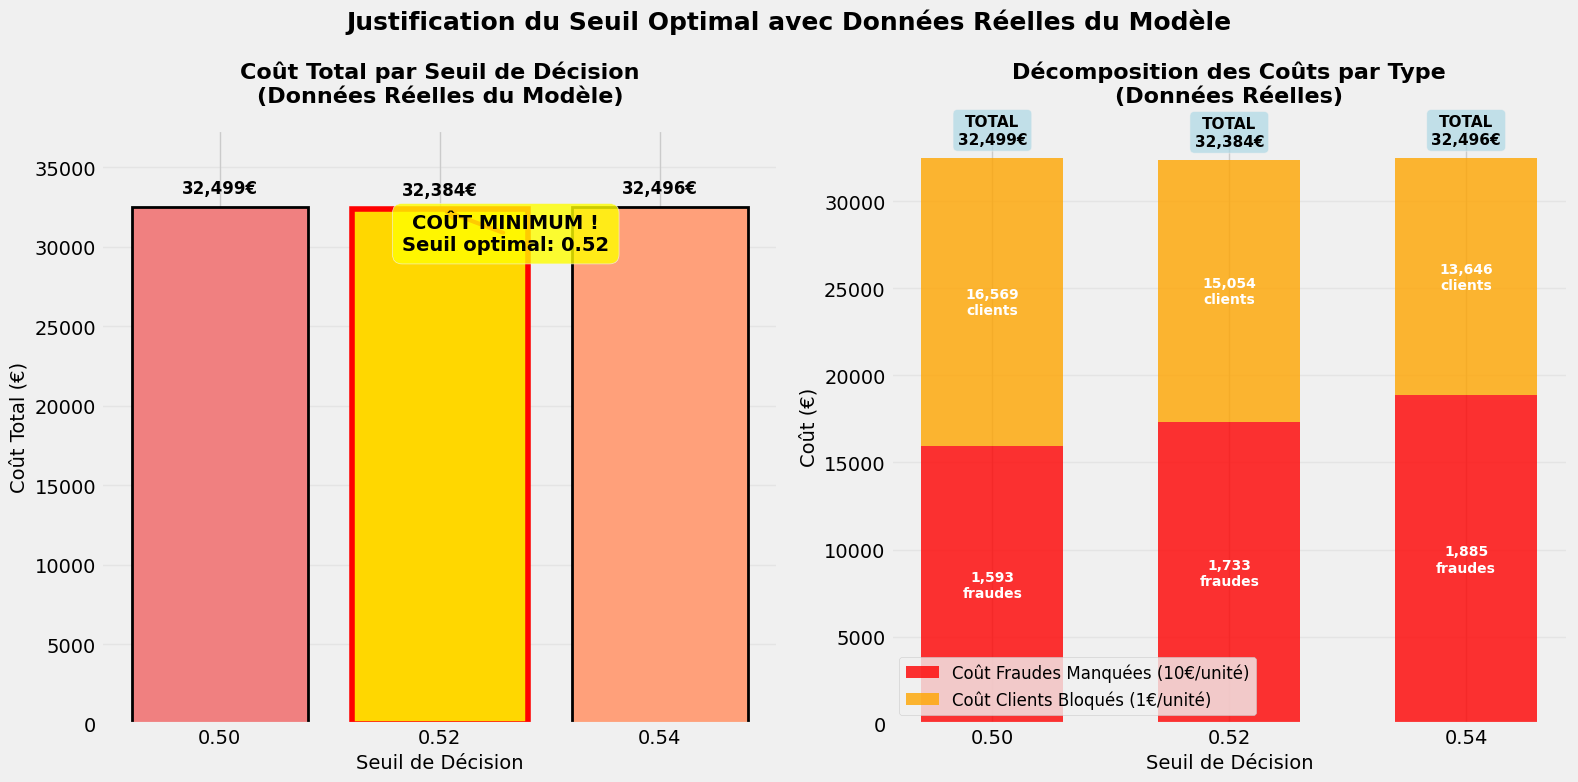


ANALYSE COMPARATIVE DES SEUILS (DONNÉES RÉELLES)

🔍 SEUIL 0.50 :
   • 1,593 fraudes manquées × 10€ = 15,930€
   • 16,569 clients bloqués × 1€ = 16,569€
   → COÛT TOTAL = 32,499€
 Coûte +115€ de plus que l'optimal

🔍 SEUIL 0.52 :
   • 1,733 fraudes manquées × 10€ = 17,330€
   • 15,054 clients bloqués × 1€ = 15,054€
   → COÛT TOTAL = 32,384€
 SEUIL OPTIMAL ! (Coût minimum)

🔍 SEUIL 0.54 :
   • 1,885 fraudes manquées × 10€ = 18,850€
   • 13,646 clients bloqués × 1€ = 13,646€
   → COÛT TOTAL = 32,496€
 Coûte +112€ de plus que l'optimal

CONCLUSION :
   Le seuil optimal est 0.52
   avec un coût total de 32,384€

GRAPHIQUE SAUVEGARDÉ: real_threshold_comparison_justification.png
SEUIL OPTIMAL RÉEL: 0.52


In [104]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def extract_real_threshold_metrics(y_true, y_proba, thresholds_to_test=[0.50, 0.52, 0.54], cost_fn=10, cost_fp=1):
    """
    Extrait les vraies métriques pour les seuils spécifiques à comparer
    """
    results = []
    
    print("EXTRACTION DES MÉTRIQUES RÉELLES")
    print("=" * 50)
    
    for threshold in thresholds_to_test:
        # Prédictions avec ce seuil
        y_pred = (y_proba >= threshold).astype(int)
        
        # Matrice de confusion
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        
        # Calculs métier
        cout_fraudes = fn * cost_fn  # Fraudes manquées
        cout_clients = fp * cost_fp  # Clients bloqués
        cout_total = cout_fraudes + cout_clients
        
        results.append({
            'seuil': threshold,
            'fraudes_manquees': fn,
            'clients_bloques': fp,
            'cout_fraudes': cout_fraudes,
            'cout_clients': cout_clients,
            'cout_total': cout_total
        })
        
        print(f"SEUIL {threshold:.2f}:")
        print(f"  • {fn:,} fraudes manquées × {cost_fn}€ = {cout_fraudes:,}€")
        print(f"  • {fp:,} clients bloqués × {cost_fp}€ = {cout_clients:,}€")
        print(f"  → COÛT TOTAL = {cout_total:,}€")
        print()
    
    return results

def create_real_threshold_comparison_visual(results):
    """
    Crée le visuel de comparaison avec les vraies données
    """
    # Extraire les données pour le graphique
    seuils = [f"{r['seuil']:.2f}" for r in results]
    fraudes_manquees = [r['fraudes_manquees'] for r in results]
    clients_bloques = [r['clients_bloques'] for r in results]
    cout_fraudes = [r['cout_fraudes'] for r in results]
    cout_clients = [r['cout_clients'] for r in results]
    cout_total = [r['cout_total'] for r in results]
    
    # Trouver l'optimal (coût minimum)
    min_idx = cout_total.index(min(cout_total))
    
    # Création du graphique
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Couleurs
    colors = ['lightcoral', 'lightblue', 'lightsalmon']
    
    # GRAPHIQUE 1: Coût total par seuil
    bars1 = ax1.bar(seuils, cout_total, color=colors, edgecolor='black', linewidth=2)
    ax1.set_title('Coût Total par Seuil de Décision\n(Données Réelles du Modèle)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax1.set_ylabel('Coût Total (€)', fontsize=14)
    ax1.set_xlabel('Seuil de Décision', fontsize=14)
    
    # Marquer l'optimal
    bars1[min_idx].set_color('gold')
    bars1[min_idx].set_edgecolor('red')
    bars1[min_idx].set_linewidth(4)
    
    # Ajouter les valeurs sur les barres
    for i, (bar, value) in enumerate(zip(bars1, cout_total)):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cout_total)*0.02,
                f'{value:,}€', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # Annotation pour l'optimal
    ax1.annotate(f'COÛT MINIMUM !\nSeuil optimal: {results[min_idx]["seuil"]:.2f}', 
                xy=(min_idx, cout_total[min_idx]), 
                xytext=(min_idx + 0.3, cout_total[min_idx] - max(cout_total)*0.08),
                arrowprops=dict(arrowstyle='->', color='red', lw=3),
                fontsize=14, ha='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8))
    
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim(0, max(cout_total) * 1.15)
    
    # GRAPHIQUE 2: Décomposition des coûts
    width = 0.6
    bars2 = ax2.bar(seuils, cout_fraudes, width, label='Coût Fraudes Manquées (10€/unité)', 
                   color='red', alpha=0.8)
    bars3 = ax2.bar(seuils, cout_clients, width, bottom=cout_fraudes, 
                   label='Coût Clients Bloqués (1€/unité)', color='orange', alpha=0.8)
    
    ax2.set_title('Décomposition des Coûts par Type\n(Données Réelles)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax2.set_ylabel('Coût (€)', fontsize=14)
    ax2.set_xlabel('Seuil de Décision', fontsize=14)
    ax2.legend(fontsize=12)
    
    # Totaux au-dessus
    for i, total in enumerate(cout_total):
        ax2.text(i, total + max(cout_total)*0.02, f'TOTAL\n{total:,}€', 
                ha='center', va='bottom', fontweight='bold', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
    
    # Détails dans les barres
    for i in range(len(seuils)):
        # Texte fraudes
        if cout_fraudes[i] > max(cout_fraudes)*0.1:  # Seulement si assez de place
            ax2.text(i, cout_fraudes[i]/2, f'{fraudes_manquees[i]:,}\nfraudes', 
                    ha='center', va='center', fontweight='bold', color='white', fontsize=10)
        
        # Texte clients
        if cout_clients[i] > max(cout_clients)*0.1:  # Seulement si assez de place
            ax2.text(i, cout_fraudes[i] + cout_clients[i]/2, f'{clients_bloques[i]:,}\nclients', 
                    ha='center', va='center', fontweight='bold', color='white', fontsize=10)
    
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Titre principal
    plt.suptitle('Justification du Seuil Optimal avec Données Réelles du Modèle', 
                fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.savefig('real_threshold_comparison_justification.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Analyse détaillée
    print("\n" + "="*70)
    print("ANALYSE COMPARATIVE DES SEUILS (DONNÉES RÉELLES)")
    print("="*70)
    
    optimal_result = results[min_idx]
    
    for i, result in enumerate(results):
        print(f"\n🔍 SEUIL {result['seuil']:.2f} :")
        print(f"   • {result['fraudes_manquees']:,} fraudes manquées × 10€ = {result['cout_fraudes']:,}€")
        print(f"   • {result['clients_bloques']:,} clients bloqués × 1€ = {result['cout_clients']:,}€")
        print(f"   → COÛT TOTAL = {result['cout_total']:,}€")
        
        if i == min_idx:
            print(f" SEUIL OPTIMAL ! (Coût minimum)")
        else:
            diff = result['cout_total'] - optimal_result['cout_total']
            print(f" Coûte {diff:+,}€ de plus que l'optimal")
    
    print(f"\nCONCLUSION :")
    print(f"   Le seuil optimal est {optimal_result['seuil']:.2f}")
    print(f"   avec un coût total de {optimal_result['cout_total']:,}€")
    
    return optimal_result

# EXÉCUTION AVEC VOS VRAIES DONNÉES
print("EXTRACTION DES MÉTRIQUES AVEC VRAIES DONNÉES DU MODÈLE")
print("="*60)

# Utiliser les données de votre modèle optimisé
y_proba_val = final_optimized_model.predict_proba(X_val_processed)[:, 1]

# Extraire les métriques pour les 3 seuils
real_results = extract_real_threshold_metrics(
    y_val, y_proba_val, 
    thresholds_to_test=[0.50, 0.52, 0.54], 
    cost_fn=10, cost_fp=1
)

# Créer le visuel avec les vraies données
optimal_result = create_real_threshold_comparison_visual(real_results)

print(f"\nGRAPHIQUE SAUVEGARDÉ: real_threshold_comparison_justification.png")
print(f"SEUIL OPTIMAL RÉEL: {optimal_result['seuil']:.2f}")

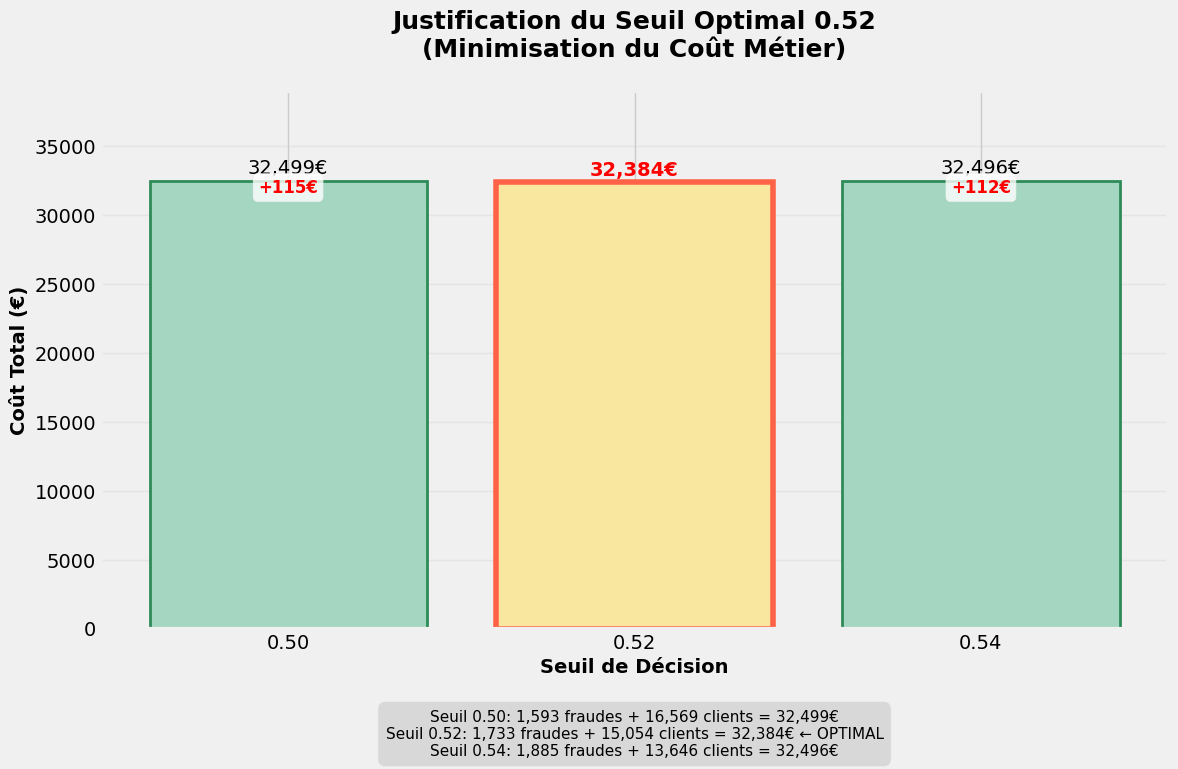

In [109]:
import matplotlib.pyplot as plt
import numpy as np

def create_slide_summary_visual():
    """
    Graphique simple et percutant pour la slide de présentation
    """
    # Nos données
    seuils = ['0.50', '0.52', '0.54']
    cout_total = [32499, 32384, 32496]
    fraudes_manquees = [1593, 1733, 1885]
    clients_bloques = [16569, 15054, 13646]
    
    # Index optimal
    optimal_idx = cout_total.index(min(cout_total))  # Index 1 = seuil 0.52
    
    # Création du graphique compact
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Couleurs 
    colors = ['#A5D6C2', '#F9E79F', '#A5D6C2']
    edge_colors = ['#2E8B57', '#FF6347', '#2E8B57']  # Contours plus foncés
    edge_widths = [2, 4, 2]
    
    # Barres principales
    bars = ax.bar(seuils, cout_total, color=colors, 
                  edgecolor=edge_colors, linewidth=edge_widths)
    
    # Titre 
    ax.set_title('Justification du Seuil Optimal 0.52\n(Minimisation du Coût Métier)', 
                 fontsize=18, fontweight='bold', pad=25)
    ax.set_ylabel('Coût Total (€)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Seuil de Décision', fontsize=14, fontweight='bold')
    
    # Valeurs sur les barres avec différenciation
    for i, (bar, value) in enumerate(zip(bars, cout_total)):
        # Couleur du texte : rouge pour optimal, noir pour autres
        color_text = 'red' if i == optimal_idx else 'black'
        weight = 'bold' if i == optimal_idx else 'normal'
        
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{value:,}€', ha='center', va='bottom', 
                fontweight=weight, fontsize=14, color=color_text)
    
    # Ajout des différences par rapport à l'optimal
    optimal_cost = cout_total[optimal_idx]
    for i, cost in enumerate(cout_total):
        if i != optimal_idx:
            diff = cost - optimal_cost
            ax.text(i, cost - 500, f'+{diff}€', ha='center', va='center',
                   fontsize=12, fontweight='bold', color='red',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Détails en bas du graphique
    details_text = (
        f"Seuil 0.50: {fraudes_manquees[0]:,} fraudes + {clients_bloques[0]:,} clients = {cout_total[0]:,}€\n"
        f"Seuil 0.52: {fraudes_manquees[1]:,} fraudes + {clients_bloques[1]:,} clients = {cout_total[1]:,}€ ← OPTIMAL\n"
        f"Seuil 0.54: {fraudes_manquees[2]:,} fraudes + {clients_bloques[2]:,} clients = {cout_total[2]:,}€"
    )
    
    ax.text(0.5, -0.15, details_text, transform=ax.transAxes, ha='center', va='top',
           fontsize=11, bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))
    
    # Mise en forme
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(cout_total) * 1.2)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)  # Espace pour les détails
    plt.savefig('slide_seuil_optimal_0_52.png', dpi=300, bbox_inches='tight')
    plt.show()

# Création du visuel pour la slide
create_slide_summary_visual()

## 10.2 Métriques techniques complémentaires avec seuil optimal

In [79]:
# Calcul des métriques avec le seuil optimal
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

print("\n" + "="*60)
print("MÉTRIQUES FINALES AVEC SEUIL OPTIMAL")
print("="*60)

# Prédictions avec seuil optimal
y_pred_optimal = (y_proba_val >= optimal_threshold).astype(int)

# Métriques techniques
auc_score = roc_auc_score(y_val, y_proba_val)
accuracy_optimal = accuracy_score(y_val, y_pred_optimal)

print(f"PERFORMANCE AVEC SEUIL OPTIMAL ({optimal_threshold:.2f}):")
print(f"AUC (inchangé): {auc_score:.4f}")
print(f"Accuracy: {accuracy_optimal:.4f}")

# Rapport de classification détaillé
print(f"\nRAPPORT DE CLASSIFICATION DÉTAILLÉ:")
print(classification_report(y_val, y_pred_optimal, 
                          target_names=['Bon Client', 'Mauvais Client']))

# Matrice de confusion finale
from sklearn.metrics import confusion_matrix
cm_optimal = confusion_matrix(y_val, y_pred_optimal)
tn, fp, fn, tp = cm_optimal.ravel()

print(f"\nMATRICE DE CONFUSION AVEC SEUIL OPTIMAL:")
print(f"                 Prédictions")
print(f"Réalité     Bon Client  Mauvais Client")
print(f"Bon Client      {tn:6d}        {fp:6d}")
print(f"Mauvais Client  {fn:6d}        {tp:6d}")

# Calcul des métriques métier finales
print(f"\nMÉTRIQUES MÉTIER FINALES:")
print(f"Faux Négatifs (FN): {fn} → Coût: {fn * 10:,} €")
print(f"Faux Positifs (FP): {fp} → Coût: {fp * 1:,} €")
print(f"Coût total: {optimal_cost:,} €")

# Comparaison avec seuil 0.5
y_pred_default = (y_proba_val >= 0.5).astype(int)
cm_default = confusion_matrix(y_val, y_pred_default)
tn_def, fp_def, fn_def, tp_def = cm_default.ravel()
cost_default = fn_def * 10 + fp_def * 1

print(f"\nCOMPARAISON FINALE:")
print(f"Seuil 0.5  → Coût: {cost_default:,} € | FN: {fn_def} | FP: {fp_def}")
print(f"Seuil {optimal_threshold:.2f} → Coût: {optimal_cost:,} € | FN: {fn} | FP: {fp}")
print(f"Économie réalisée: {cost_default - optimal_cost:,} € ({(cost_default - optimal_cost)/cost_default*100:.1f}%)")

print(f"\nMODÈLE PRÊT POUR LA PRODUCTION!")
print(f"Seuil de décision recommandé: {optimal_threshold:.2f}")


MÉTRIQUES FINALES AVEC SEUIL OPTIMAL
PERFORMANCE AVEC SEUIL OPTIMAL (0.52):
AUC (inchangé): 0.7612
Accuracy: 0.7271

RAPPORT DE CLASSIFICATION DÉTAILLÉ:
                precision    recall  f1-score   support

    Bon Client       0.96      0.73      0.83     56538
Mauvais Client       0.18      0.65      0.28      4965

      accuracy                           0.73     61503
     macro avg       0.57      0.69      0.55     61503
  weighted avg       0.90      0.73      0.79     61503


MATRICE DE CONFUSION AVEC SEUIL OPTIMAL:
                 Prédictions
Réalité     Bon Client  Mauvais Client
Bon Client       41484         15054
Mauvais Client    1733          3232

MÉTRIQUES MÉTIER FINALES:
Faux Négatifs (FN): 1733 → Coût: 17,330 €
Faux Positifs (FP): 15054 → Coût: 15,054 €
Coût total: 32,384 €

COMPARAISON FINALE:
Seuil 0.5  → Coût: 32,499 € | FN: 1593 | FP: 16569
Seuil 0.52 → Coût: 32,384 € | FN: 1733 | FP: 15054
Économie réalisée: 115 € (0.4%)

MODÈLE PRÊT POUR LA PRODUCTION!
Se

In [80]:
import joblib
import os

# Sauvegarder le modèle final avec des informations
model_data = {
    'model': final_optimized_model,
    'features': features,  # Liste des noms de colonnes
    'scaler': scaler,      # Le scaler utilisé
    'imputer': imputer,    # L'imputer utilisé
    'optimal_threshold': optimal_threshold,  # Seuil optimal trouvé
    'model_name': best_model_name
}

# Sauvegarder
joblib.dump(model_data, "model_complet.pkl")
print(f"Modèle complet sauvegardé : model_complet.pkl")

# Vérifier que le fichier existe
if os.path.exists("model_complet.pkl"):
    file_size = os.path.getsize("model_complet.pkl") / 1024 / 1024
    print(f"Taille du fichier : {file_size:.2f} MB")
else:
    print("ERREUR : Fichier non créé !")

Modèle complet sauvegardé : model_complet.pkl
Taille du fichier : 0.57 MB


In [81]:
# Test de chargement 
def test_model_loading():
    """Teste le chargement et le fonctionnement du modèle"""
    try:
        # Charger le modèle
        loaded_data = joblib.load("model_complet.pkl")
        model = loaded_data['model']
        features = loaded_data['features']
        scaler = loaded_data['scaler']
        imputer = loaded_data['imputer']
        threshold = loaded_data['optimal_threshold']
        
        print("Modèle chargé avec succès")
        print(f"Features : {len(features)}")
        print(f"Seuil optimal : {threshold}")
        
        # Test sur un échantillon
        if len(X_val_processed) > 0:
            test_pred = model.predict_proba(X_val_processed[:1])
            print(f"Test de prédiction réussi : {test_pred[0][1]:.4f}")
            return True
    except Exception as e:
        print(f"Erreur lors du chargement : {e}")
        return False

# Exécuter le test
test_model_loading()

Modèle chargé avec succès
Features : 240
Seuil optimal : 0.52
Test de prédiction réussi : 0.3616


True

In [82]:
model_data = {
    'model': final_optimized_model,  # modèle final optimisé
    'scaler': scaler,               # scaler utilisé
    'imputer': imputer,             # imputer utilisé  
    'features': features,           # liste des features (déjà définie)
    'optimal_threshold': optimal_threshold,  # seuil optimal trouvé (0.52)
    'model_name': best_model_name   # nom du modèle
}

joblib.dump(model_data, 'model_complet.pkl')
print(f"Modèle sauvegardé avec seuil optimal: {optimal_threshold:.2f}")

Modèle sauvegardé avec seuil optimal: 0.52


In [83]:
# Test de chargement
loaded_data = joblib.load('model_complet.pkl')
print("Modèle chargé avec succès!")
print(f"Seuil optimal: {loaded_data['optimal_threshold']}")
print(f"Nombre de features: {len(loaded_data['features'])}")

Modèle chargé avec succès!
Seuil optimal: 0.52
Nombre de features: 240
